## ✅ Vérification de l'environnement Python

Cette cellule vérifie que l'environnement virtuel `.venv` est correctement chargé avec tous les packages nécessaires.

In [1]:
import sys
import platform

# Afficher l'interpréteur Python utilisé
print("=" * 70)
print("ENVIRONNEMENT PYTHON")
print("=" * 70)
print(f"Interpréteur : {sys.executable}")
print(f"Version Python : {platform.python_version()}")
print(f"Plateforme : {platform.platform()}")
print()

# Vérifier les packages installés
print("=" * 70)
print("PACKAGES INSTALLÉS")
print("=" * 70)

packages_to_check = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sympy', 'sympy'),
    ('skimage', 'scikit-image'),
    ('ipywidgets', 'ipywidgets')
]

all_ok = True
for module_name, package_name in packages_to_check:
    try:
        mod = __import__(module_name)
        version = getattr(mod, '__version__', 'N/A')
        print(f"✓ {package_name:20s} version {version}")
    except ImportError as e:
        print(f"✗ {package_name:20s} NON INSTALLÉ")
        all_ok = False

print("=" * 70)
if all_ok:
    print("✅ Tous les packages sont correctement installés!")
else:
    print("⚠️  Certains packages sont manquants. Veuillez les installer.")
print("=" * 70)

ENVIRONNEMENT PYTHON
Interpréteur : /home/pascal/imagcloud/IMMUN4CURE/brain-storming/immunomath/.venv/bin/python
Version Python : 3.12.3
Plateforme : Linux-6.8.0-139-generic-x86_64-with-glibc2.39

PACKAGES INSTALLÉS
✓ np                   version 2.3.5
✓ scipy                version 1.16.3
✓ matplotlib           version 3.10.7
✓ sympy                version 1.14.0
✓ scikit-image         version 0.25.2
✓ ipywidgets           version 8.1.8
✅ Tous les packages sont correctement installés!


# Nouveau modèle (réunion du 11/07)

Ce notebook est centré sur le nouveau modèle proposé lors de la réunion du 11/07, avec Florence, Gabriel et Olivier

### <span style="color:red">nouveau modèle</span> suggéré par Olivier et Oana
$S(t)$ variable qui modélise l'état inflammatoire résultant de l'injection du signal immun et de l'activation des chimiokines dans les macrophages lining et les fibroblastes. 

L'état inflammatoire  $S(t)$ est renforcé par les neutrophiles N et inhibés par les  macrophages SL-TRM T.

L'inflammation fait croître davantage les neutrophiles (facteur $\alpha$), elle fait croître les momac (facteur $\beta$) et elle fait décroître les SL-TRM (facteur $\gamma$)

**On ne suit plus la population de fibroblastes, mais plutôt la population de neutrophiles qui sont appelés par les chimiokines inflammatoires.**

N(t) : population de <span style="color:red">neutrophiles</span>

M(t) : population de Momac

T(t) : population de macrophages SL-TRM

$$ \begin{aligned}
\frac{dS}{dt} &=& \color{red}{(a\, N - b\,T)} & \, S & \\
\frac{dN}{dt} &=& \alpha \, S\,N &-\delta_N\,N\cdot (N-1)& \\
\frac{dM}{dt} &=&  \beta\,\color{red} {\, S} &&-\delta_M\, M\cdot (M-1) \\
\frac{dT}{dt} &=&-\gamma S\, T & &+\delta_M\,M\cdot (1-T)
\end{aligned}
$$

```mermaid
flowchart LR
    subgraph "Modèle 4 compartiments"
        S["Signal immun inflammatoire"]
        N["Neutrophiles"]
        M["Momac (Monocytes/Macrophages)"]
        T["SL-TRM Macrophages"]
    end

    N -- "renforce (a)" --> S
    T -- "inhibe (b)" --> S
    S -- "croissance (α)" --> N
    S -- "croissance (β)" --> M
    S -- "décroissance (γ)" --> T
    N -- "destruction (δ_N)" --> N
    M -- "destruction (δ_M)" --> M
    M -- "conversion (δ_M)" --> T


![Schéma du modèle](/home/pascal/imagcloud/IMMUN4CURE/brain-storming/schema_mermaid.png)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, fixed

## 2. Définir le système différentiel du nouveau modèle

La fonction `system_adim_oliv` implémente les équations différentielles du modèle adimensionné avec neutrophiles, Momac, SL-TRM et signal inflammatoire, selon la proposition d'Olivier et Oana.

In [3]:
def system_adim_oliv(t, y, alpha, beta, gamma, delta_N, delta_M, a, b):
    """
    y : vecteur (S N M T) 
    S : signal inflammatoire adimensionné
    N : Neutrophiles adimensionnés
    M : Monocytes Macrophages  adimensionnés
    T : SL-TRM Macrophages adimensionnés

    la valeur d'équilibre physiologique des neutrophiles est 1
    la valeur d'équilibre physiologique des Momac est 1
    la valeur d'équilibre physiologique des SL-TRM est 1
    alpha <1 est le taux de croissance des neutrophiles causé par l'inflammation
    beta  est le taux de croissance des Momac causé par l'inflammation
    gamma est le taux de destruction des SL-TRM causé par l'inflammation 
    delta_N est le taux de destruction des neutrophiles
    delta_M est le taux de conversion  Momac -> SL-TRM  
    """

    S, N, M, T = y

    dSdt =  (a* N - b* T)*S
    dNdt = alpha * S*N - delta_N * N * (N-1)
    dMdt = beta *S - delta_M * M*(M-1)
    dTdt = -gamma * S * T + delta_M *M *(1-T)

    return [dSdt, dNdt, dMdt, dTdt]

## 3. Définir la fonction de simulation

La fonction `inflam_adim_oliv` résout le système différentiel et trace les résultats pour visualiser l'évolution des différentes populations et du signal inflammatoire.

In [4]:
def inflam_adim_oliv(y0, alpha, beta, gamma, delta_N, delta_M, a, b, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_oliv, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/1000), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, a, b))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(221)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('inflammatory signal')

    plt.subplot(222)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(N)
    plt.ylim(bottom=0, top=ymax)
    plt.title('neutrophiles')

    plt.subplot(223)
    plt.plot(t,M, 'g')
    plt.xlabel('time [d] ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(M)
    plt.ylim(bottom=0, top=ymax)
    plt.title('monocytes macrophages')

    plt.subplot(224)
    plt.plot(t,T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('macrophages SL-TRM')

    #plt.subplot(325)
    #plt.plot(M,T, 'm')
    #plt.xlabel('Momac')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.3, 0.01, 'Plan de phase entre Momac et SL-TRM ', ha='center', fontsize=12)

    #plt.subplot(326)
    #plt.plot(S,T, 'm')
    #plt.xlabel('signal inflammatoire')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.7, 0.01, 'Plan de phase entre inflammation et SL-TRM ', ha='center', fontsize=12)

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

## 4. Exécuter une simulation de base avec inflam_adim_oliv

On observe le comportement du modèle avec des paramètres standards.

valeurs finales: Signal=0.002, Neutrophiles=1.005, Momac=1.004, SL-TRM=0.996


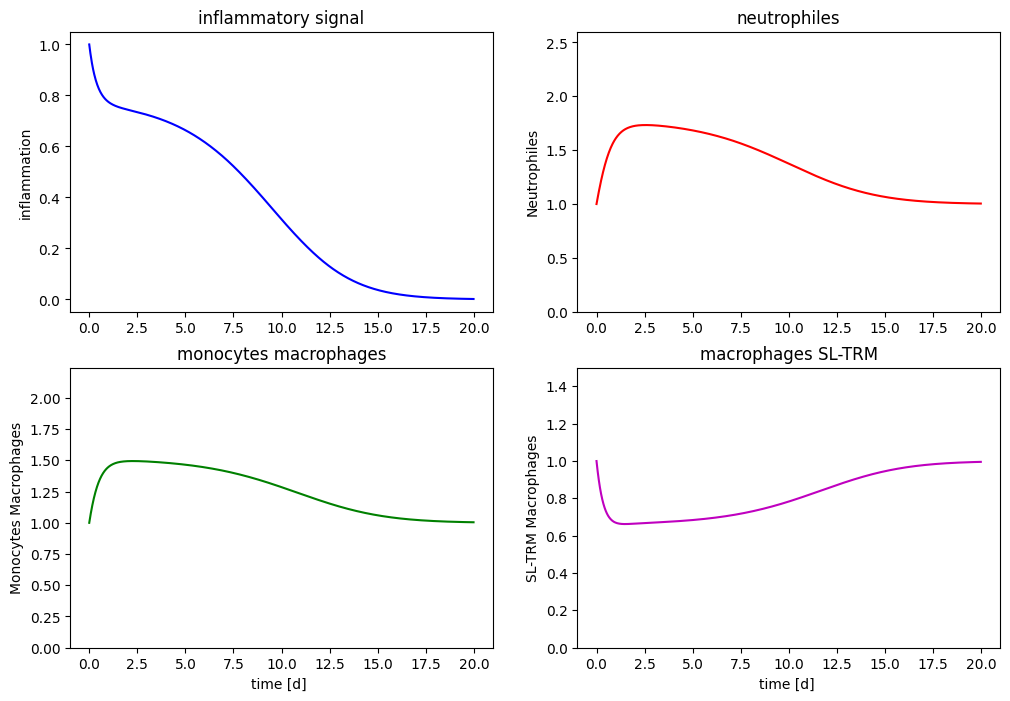

In [5]:
inflam_adim_oliv([1, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.37, b=1, duree=20)

## 5. Tester la stabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est stable (par exemple, a + b > seuil).

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


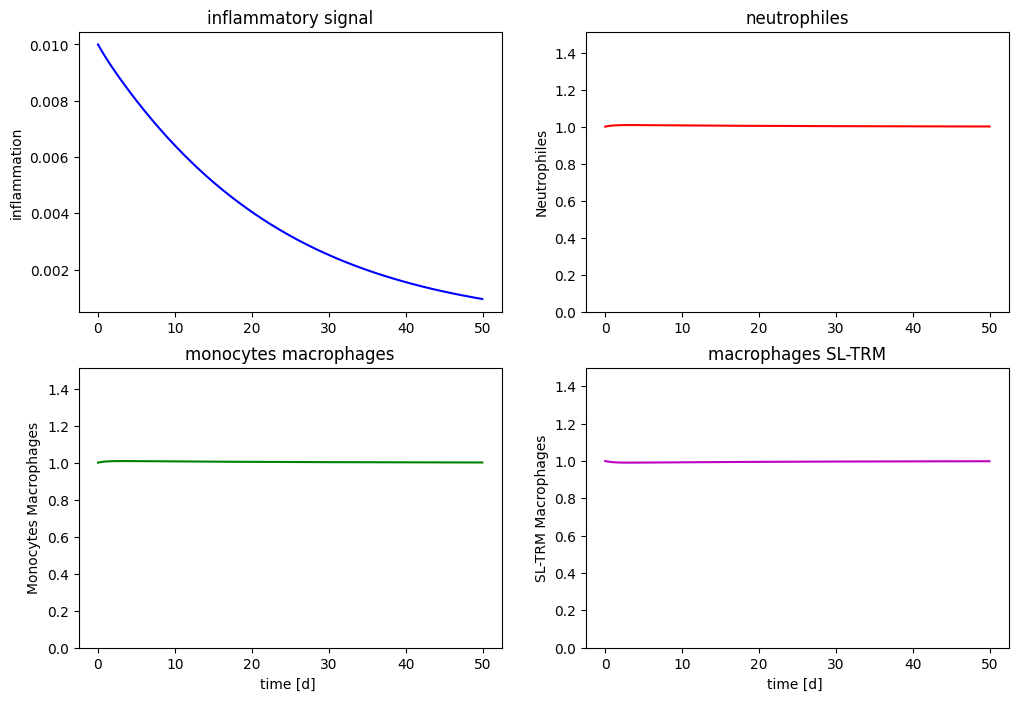

In [6]:
#l'équilibre physiologique est stable si a / b > seuil
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=0.40, duree=50)

## 6. Tester l’instabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est instable (par exemple, a + b < seuil).

valeurs finales: Signal=0.553, Neutrophiles=1.480, Momac=1.359, SL-TRM=0.730


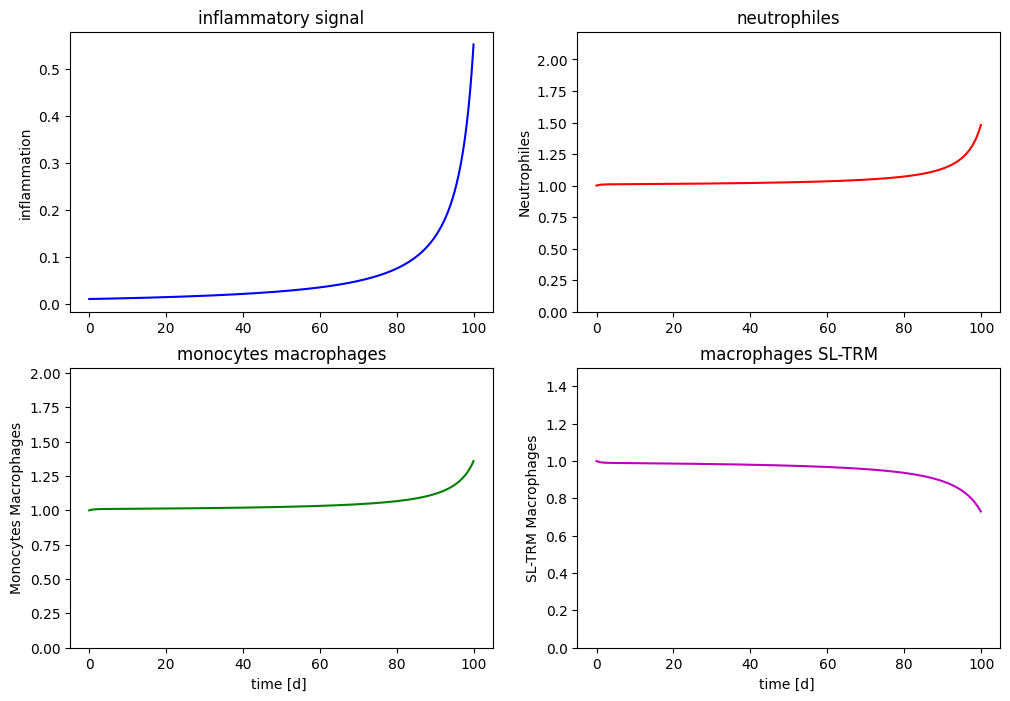

In [7]:
#l'équilibre physiologique est instable si a / b < seuil
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.31, b=0.30, duree=100)

/tmp/ipykernel_23395/3660657395.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


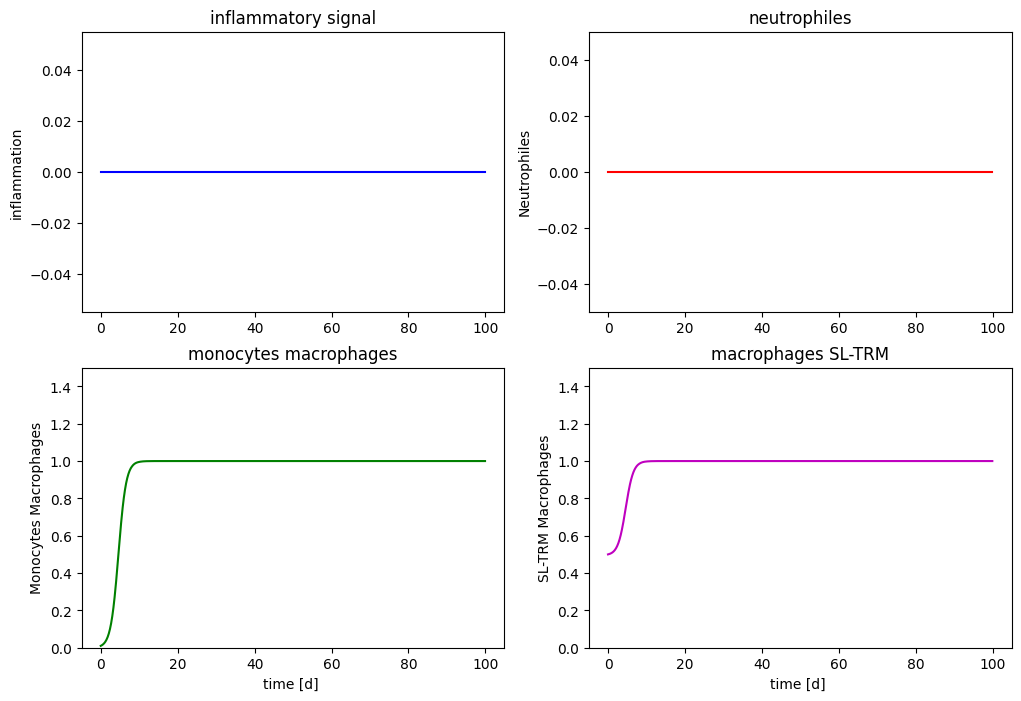

In [8]:
# test 10/10 brain storming pour instabilité des points fixes du type (0,0,0,T) avec T non nul <1
inflam_adim_oliv([0., 0, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


on constate que le système tend vers un autre point fixe $(S,N,M,T)=(0,0,1,1)$

/tmp/ipykernel_23395/3660657395.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


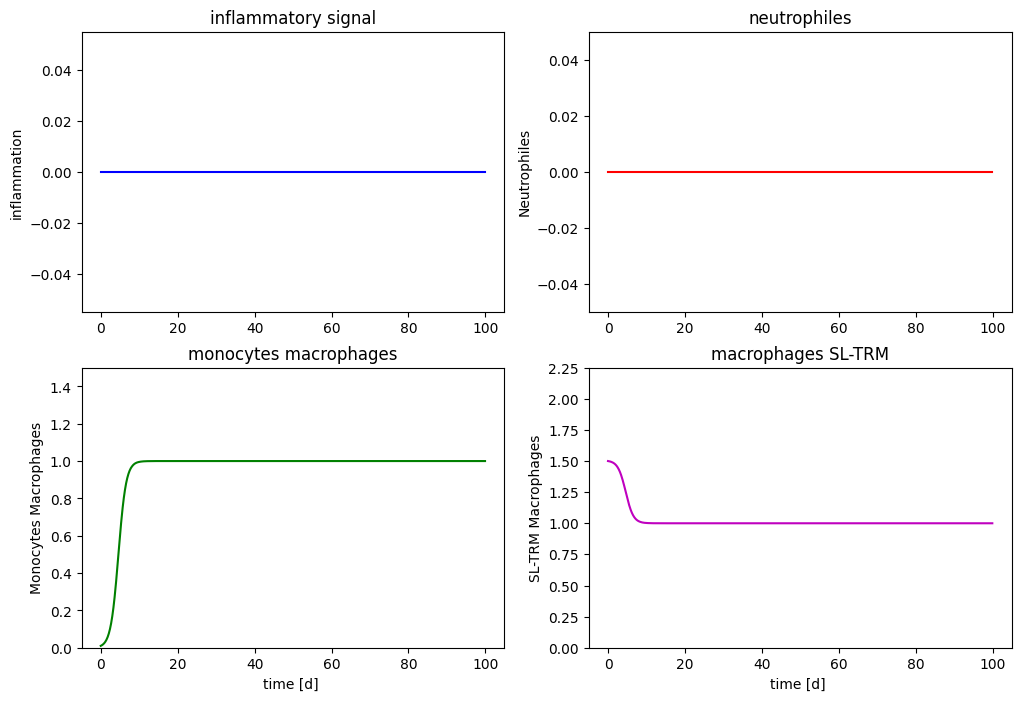

In [9]:
# test pour instabilité des points fixes du type (0,0,0,T) avec T_ini > 1
inflam_adim_oliv([0., 0, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=100)

On constate que  le système revient encore vers un autre point fixe $(S,N,M,T)=(0,0,1,1)$

Il semble qu'il y ait une sous-variété invariante $\{0\}\times \{0\}\times \mathbb{R}\times\mathbb{R}$

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


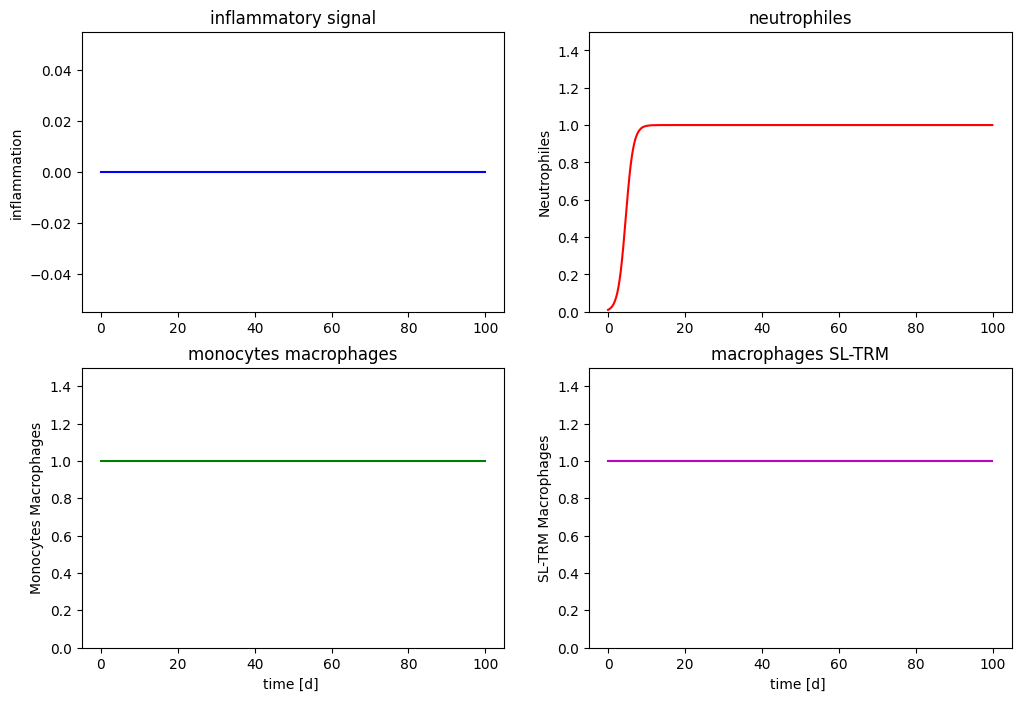

In [10]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_oliv([0., 0.01, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On voit que le système revient encore vers le point fixe $(S,N,M,T)=(0,1,1,1)$

/tmp/ipykernel_23395/3660657395.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


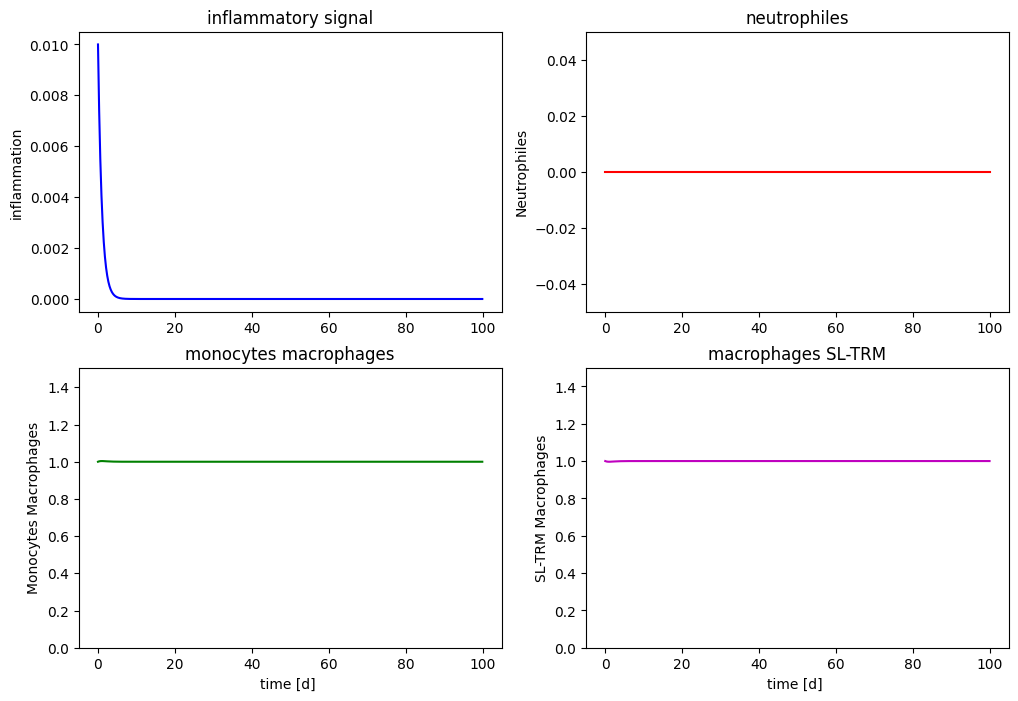

In [11]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_oliv([0.01, 0., 1.0, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On constate que ce point $(0,0,1,1)$ est stable pour les pertubations de $S$ et instable pour les perturbations en $N$.

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


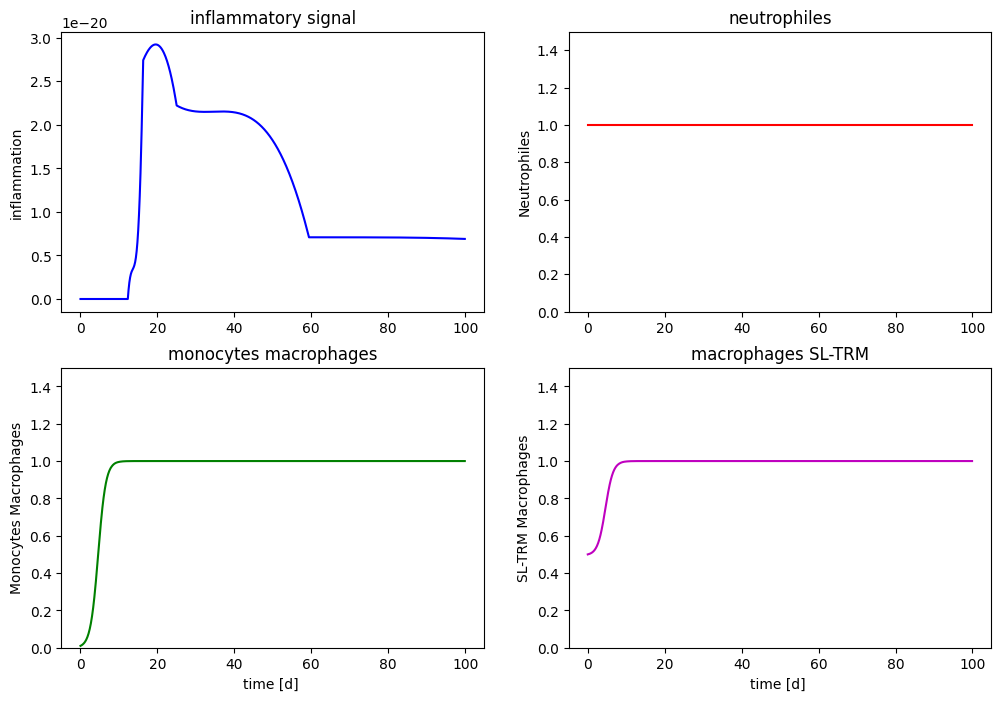

In [12]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,1,0,T) avec T non nul <1
inflam_adim_oliv([0., 1, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On va vers l'état physiologique. 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


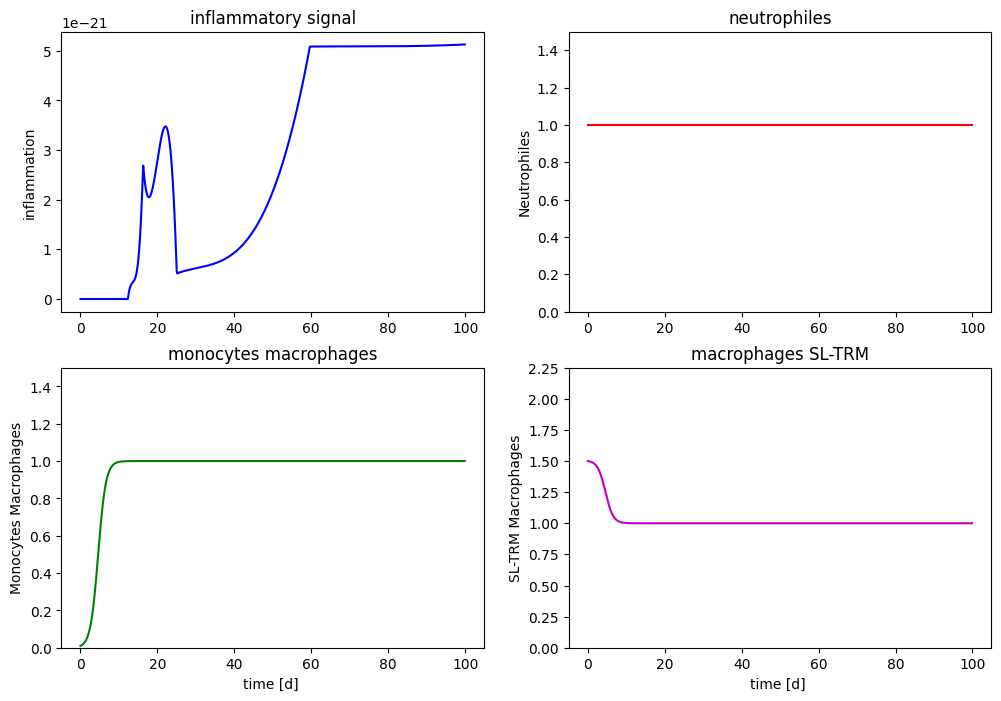

In [13]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini > 1
inflam_adim_oliv([0., 1, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=100)

On remarque un phénomène intéressant: en l'absence de signal immun initial même en présence de Neutrophiles, l'état $(0,1, 0, T)$ évolue vers l'état physiologique.


valeurs finales: Signal=1123.067, Neutrophiles=562.569, Momac=9.574, SL-TRM=0.014


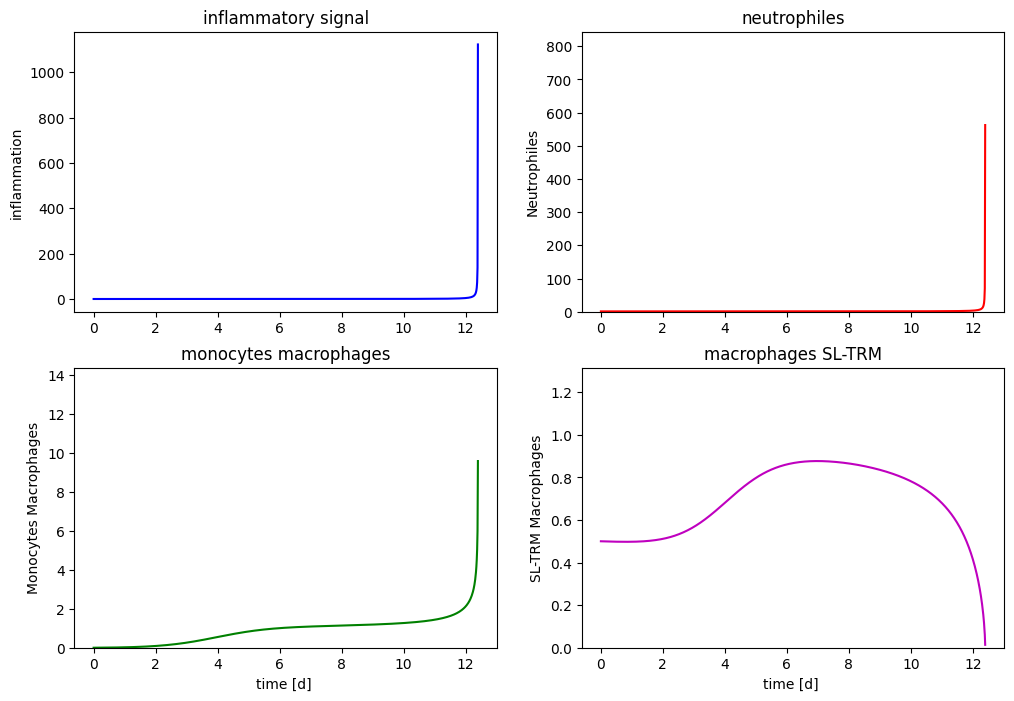

In [14]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini < 1
inflam_adim_oliv([0.01, 1, 0., 0.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=12.5)

On voit un instabilité lorsque le patient a un stock insuffisant de SL-TRM (T) et des neutrophiles.

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


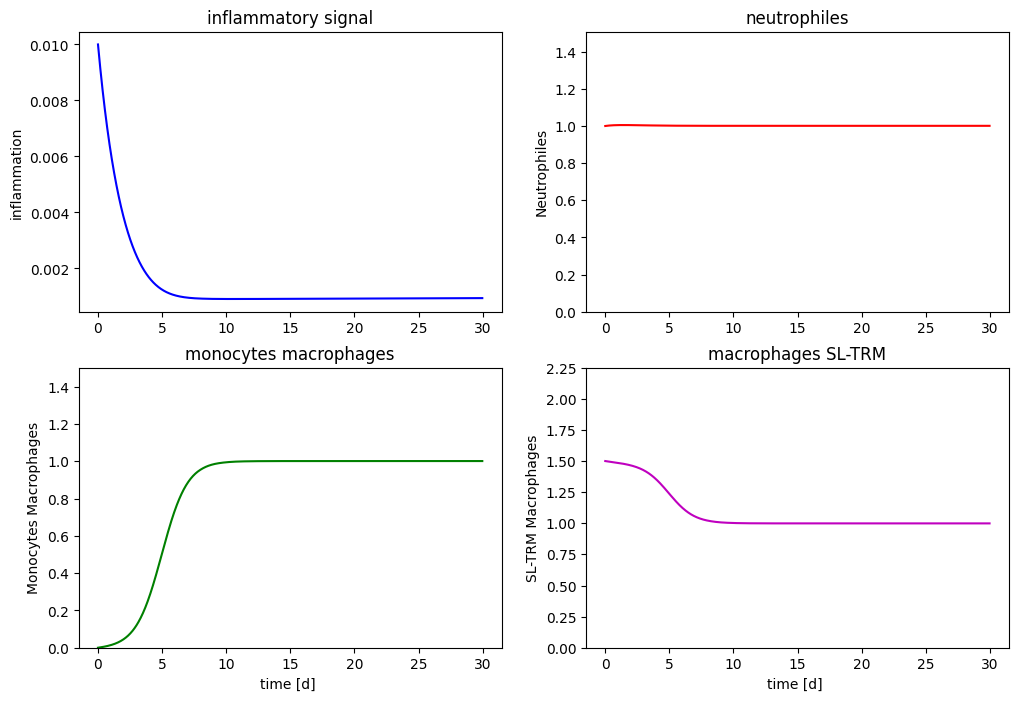

In [15]:
#instabilité des points fixes du type (0,1,0,T) avec T_ini > 1 
inflam_adim_oliv([0.01, 1, 0., 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=30)


On trouve que la sous-variété $T=1$ est critique pour ce type de point fixe. En effet  lorsque $T>1$ le système revient à l'état physiologique. Alors que pour $T<1$ le système s'emballe. La crise s'amplifie

valeurs finales: Signal=0.004, Neutrophiles=1.015, Momac=1.014, SL-TRM=0.987


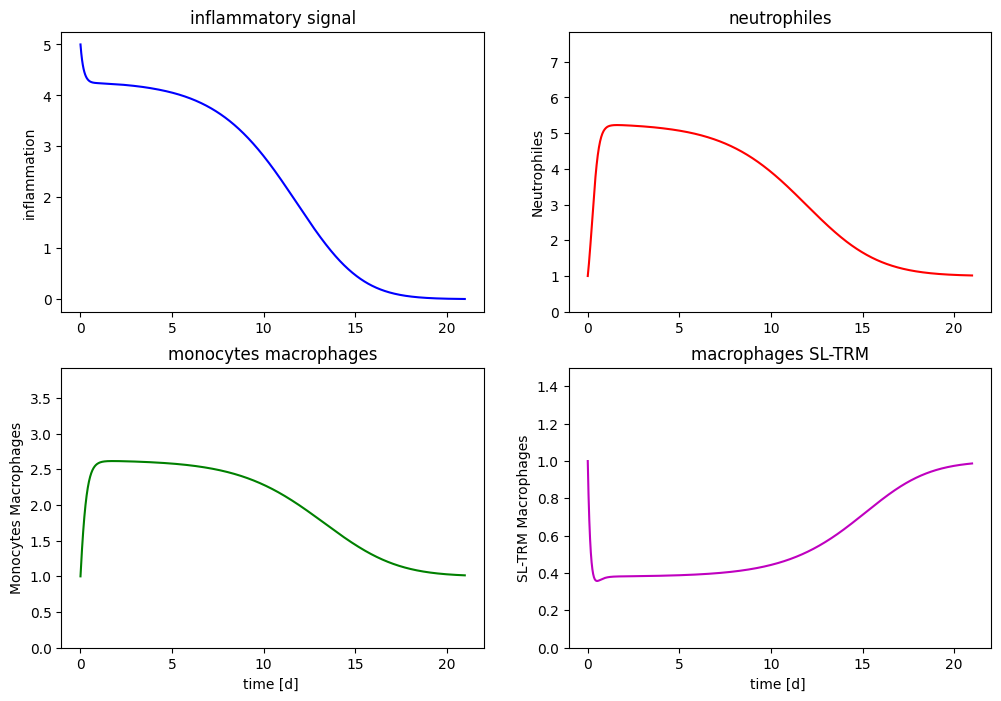

In [16]:
inflam_adim_oliv([5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.072, b=1, duree=21)

On teste l'influence du facteur $\delta_M$ qui contrôle la remontée des SL-TRM

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


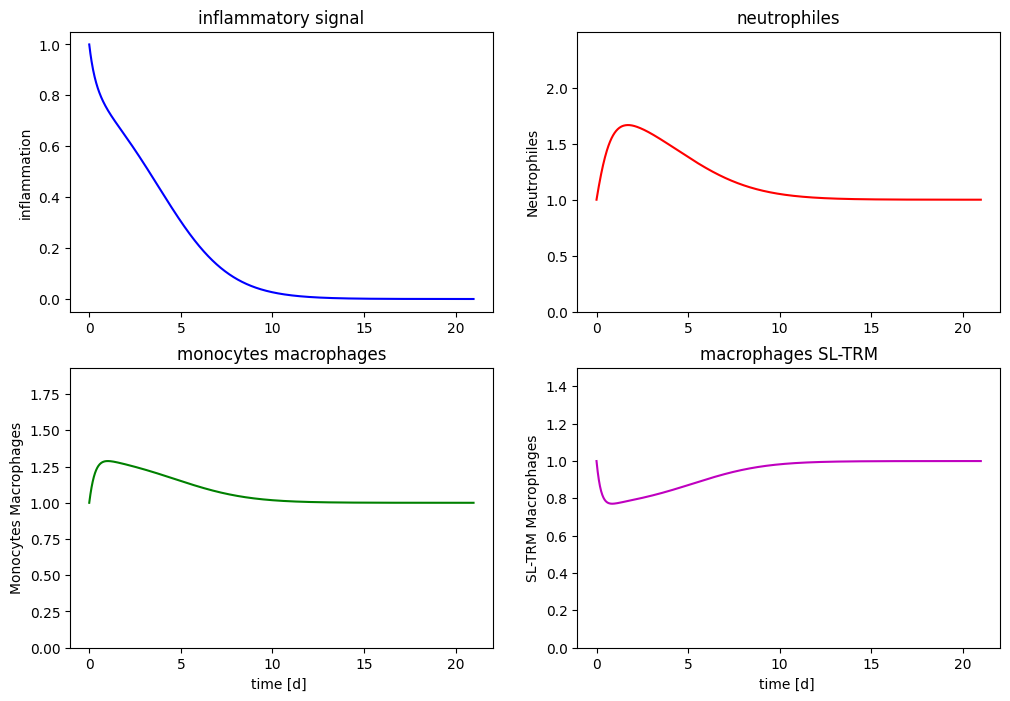

In [17]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=2,a=0.38, b=1, duree=21)

valeurs finales: Signal=320.168, Neutrophiles=233.053, Momac=9.659, SL-TRM=0.036


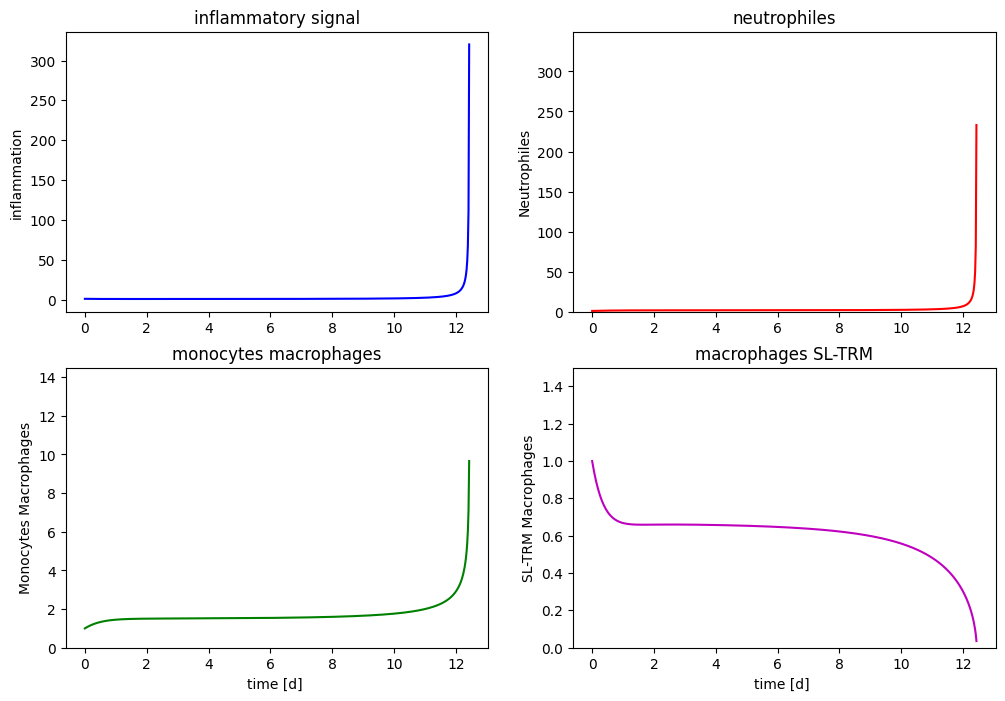

In [18]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=21)

On teste aussi l'influence de la population initiale de SL-TRM

valeurs finales: Signal=354.248, Neutrophiles=259.619, Momac=10.011, SL-TRM=0.034


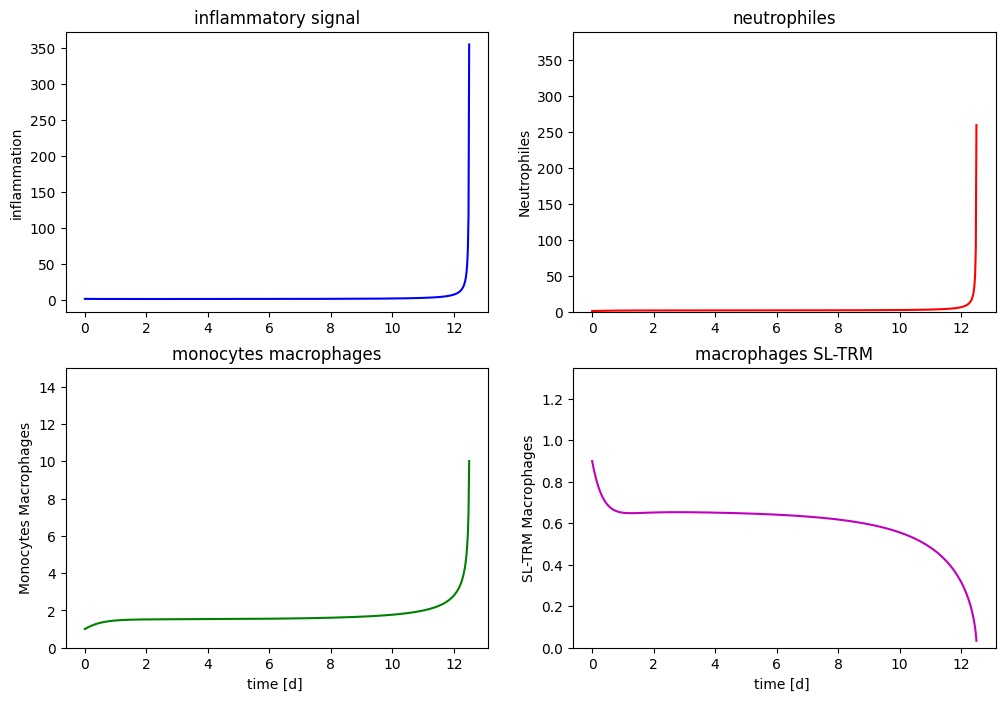

In [19]:
inflam_adim_oliv([1, 1, 1, 0.90],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.37, b=1, duree=21)

valeurs finales: Signal=0.001, Neutrophiles=1.003, Momac=1.003, SL-TRM=0.997


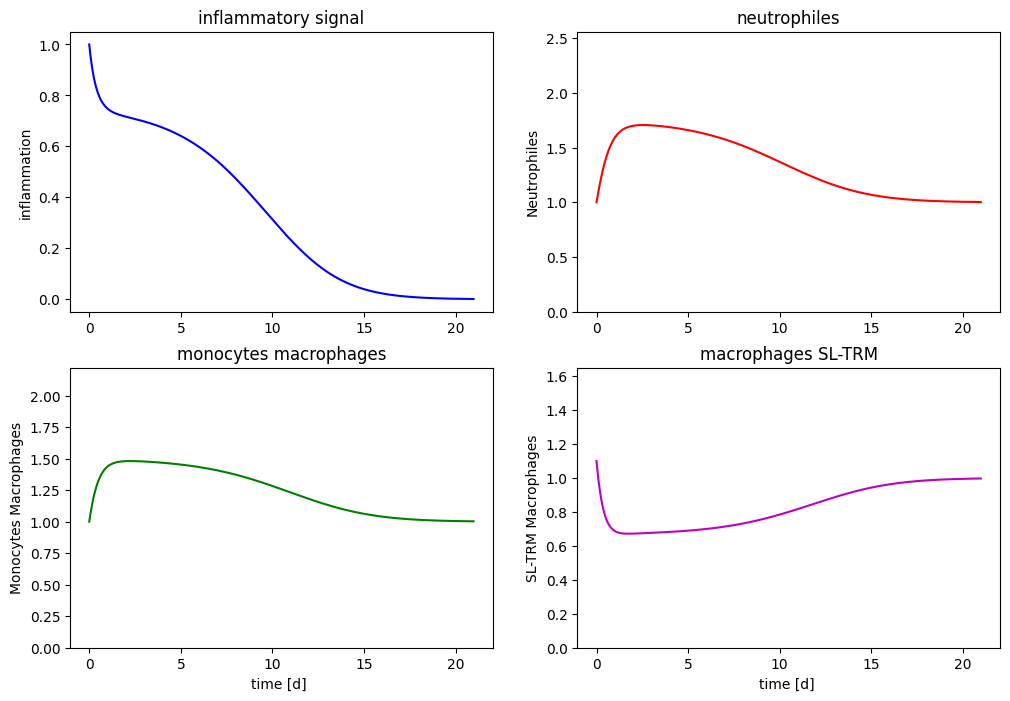

In [20]:
inflam_adim_oliv([1, 1, 1, 1.1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=21)

On teste en prenant une condition initiale proche d'un point fixe inflammatoire instable
$$A= 0.2,  T\approx 0.5, N= T/A, S= \frac{\delta_N}{\alpha}( N -1), M = 1 + \frac{\beta(1-T)}{\gamma T}
$$

valeurs finales: Signal=2.910, Neutrophiles=3.713, Momac=2.218, SL-TRM=0.442


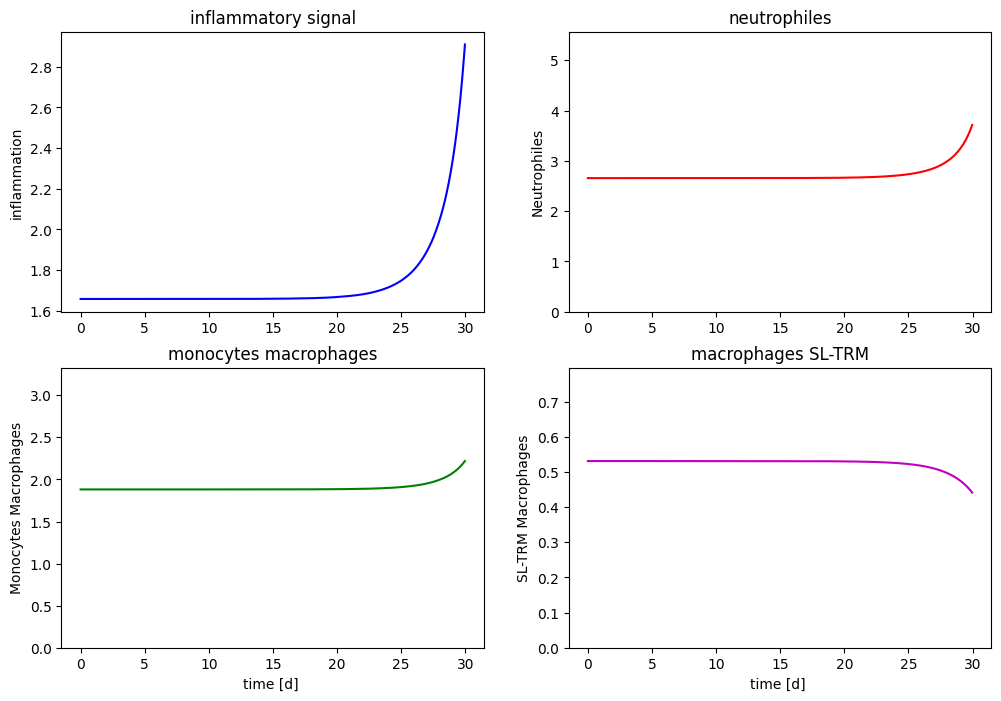

In [21]:
alpha=1
beta=1
gamma=1
delta_N=1
A=0.2
T_ini=0.5315550717454
N_ini=T_ini/A
S_ini = (delta_N/alpha)*(N_ini -1)
M_ini = 1 + beta*(1-T_ini)/(gamma*T_ini)
inflam_adim_oliv([S_ini, N_ini, M_ini, T_ini],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.2, b=1, duree=30)

On peut aussi augmenter le paramètre $\delta_M$ qui contrôle la population de Momac et le recrutement des SL-TRM. Cela favorise le retour à l'équilibre.

valeurs finales: Signal=0.000, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


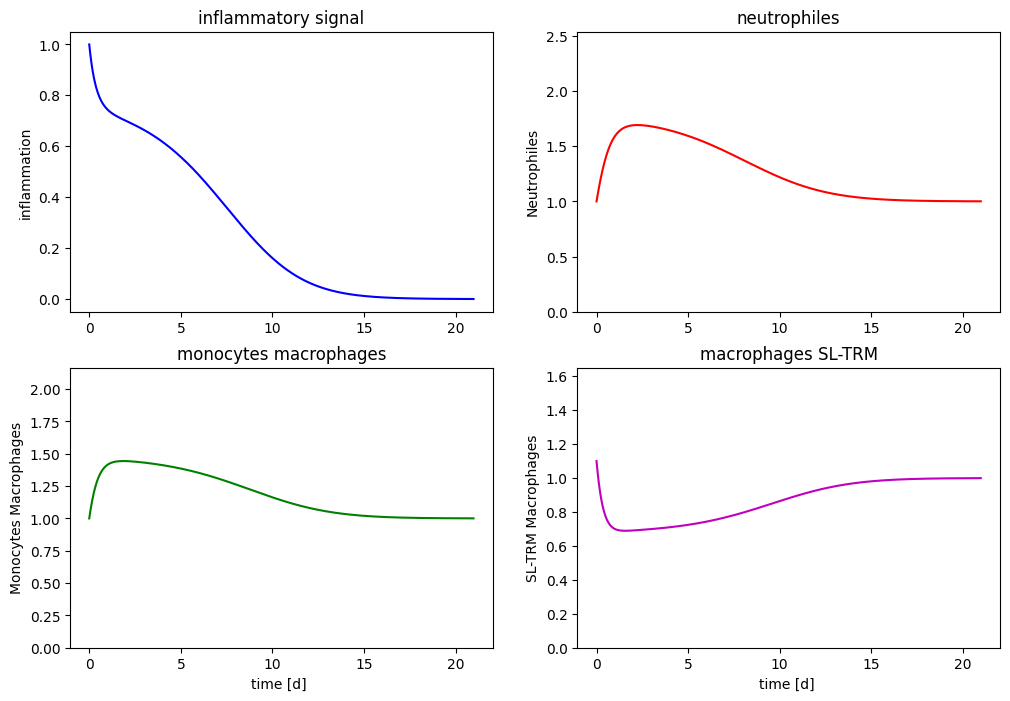

In [22]:
inflam_adim_oliv([1, 1, 1, 1.1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1.1 ,a=0.38, b=1, duree=21)

On peut aussi augementer le paramètre $\delta_N$ de contrôle des neutrophiles, cela favorise le retour à l'équilibre aussi.

valeurs finales: Signal=0.000, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


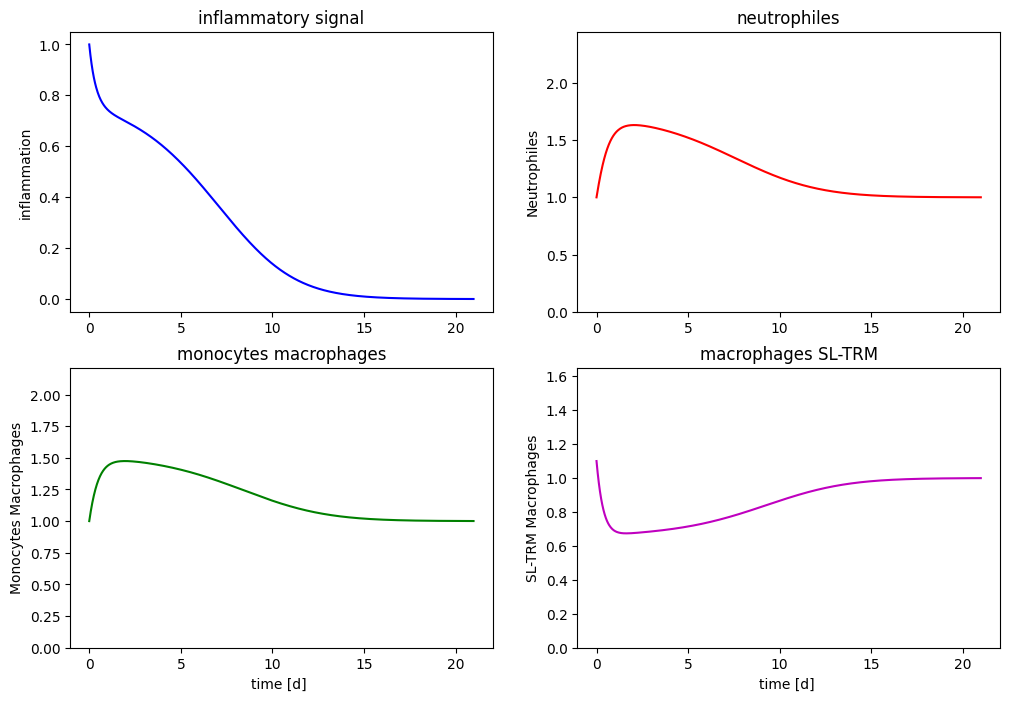

In [23]:
inflam_adim_oliv([1, 1, 1, 1.1],
    alpha=1, beta=1, gamma=1,
    delta_N=1.1, delta_M=1 ,a=0.38, b=1, duree=21)

On peut aussi commencer avec une population diminuee de SL-TRM. Cela favorise l'inflammation

valeurs finales: Signal=417.514, Neutrophiles=310.309, Momac=10.649, SL-TRM=0.030


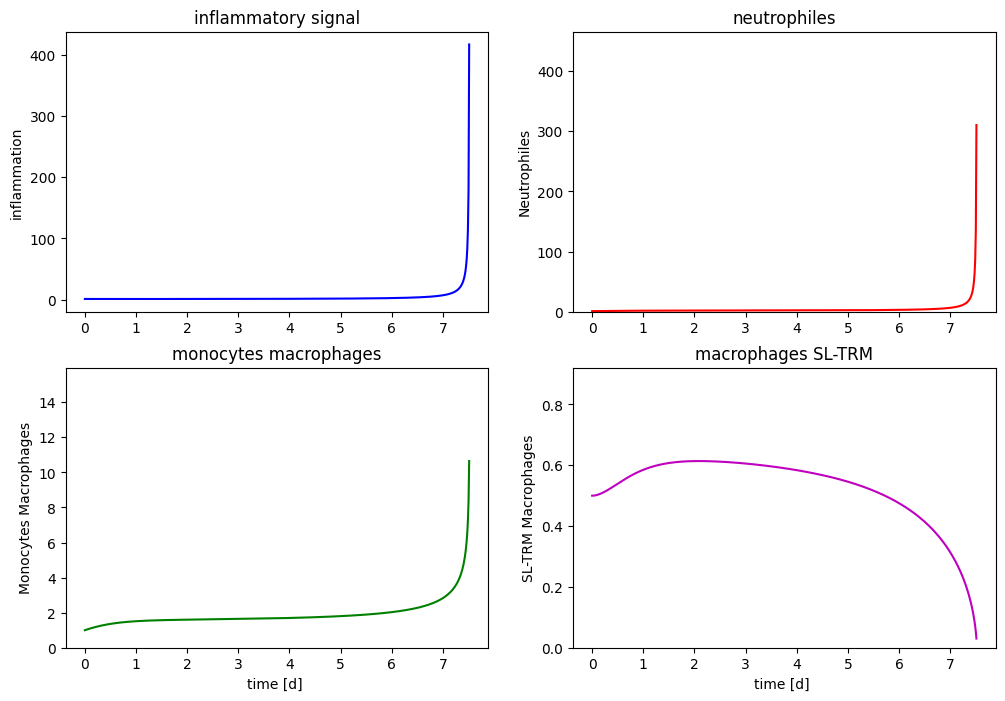

In [24]:
inflam_adim_oliv([1, 1, 1, 0.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1 ,a=0.35, b=1, duree=12)

valeurs finales: Signal=0.004, Neutrophiles=1.008, Momac=1.007, SL-TRM=0.994


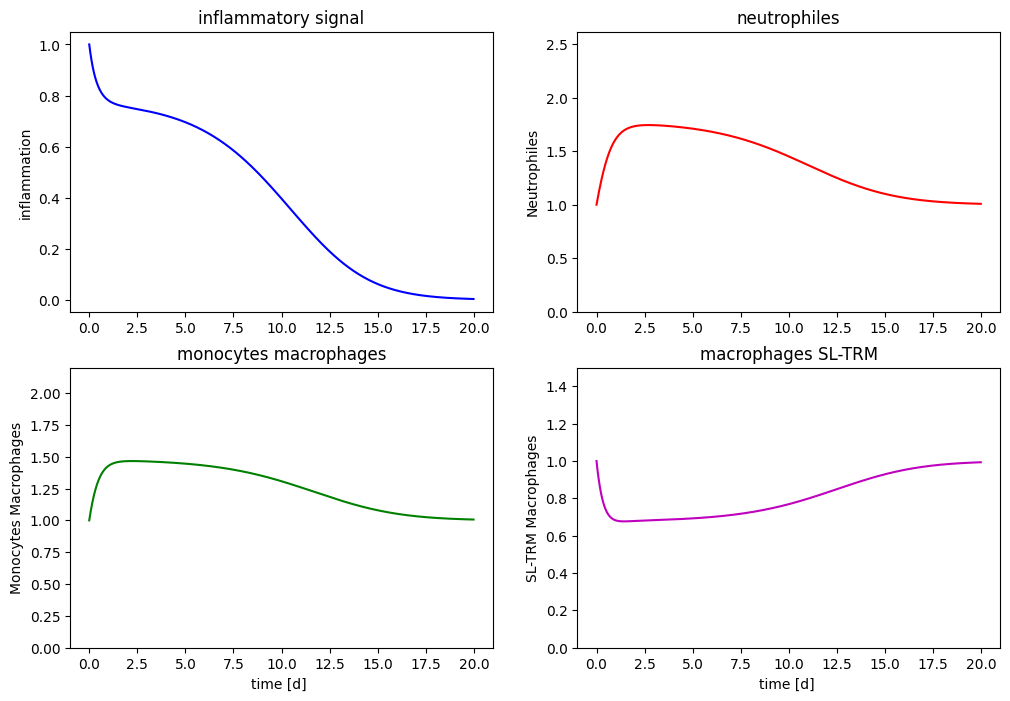

In [25]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1.1 ,a=0.38, b=1, duree=20)

## 7. Créer une interface interactive pour explorer le modèle

Utilisez les curseurs pour explorer dynamiquement l'effet des paramètres sur le modèle.

In [26]:
# Définition de la fonction interactive
def interactive_inflam_oliv(alpha,beta,gamma,delta_N,delta_M, a, b, duree):
    inflam_adim_oliv([1, 1.00, 1, 1],
           alpha, beta, gamma, delta_N, delta_M, a, b, duree)

# Création des curseurs pour les paramètres
ui = widgets.HBox([
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.01, value=1, description='alpha neutrophiles <-signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='beta Momac <- neutrophiles'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='gamma  SL-TRM <- signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_N  neutrophiles'),
    ]),
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_M conversion  Momac -> SL-TRM'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=0.35, description='a feed-back neutrophiles -> signal'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=1, description='b hold-back SL-TRM -> signal'),
        widgets.IntSlider(min=0, max=20, step=1, value=10, description='durée de la simulation'),
    ])
])

out = widgets.interactive_output(
    interactive_inflam_oliv,
    {
        'alpha': ui.children[0].children[0],
        'beta': ui.children[0].children[1],
        'gamma': ui.children[0].children[2],
        'delta_N': ui.children[0].children[3],
        'delta_M': ui.children[1].children[0],
        'a': ui.children[1].children[1],
        'b': ui.children[1].children[2],
        'duree': ui.children[1].children[3],
    }
)

display(ui, out)

Output()

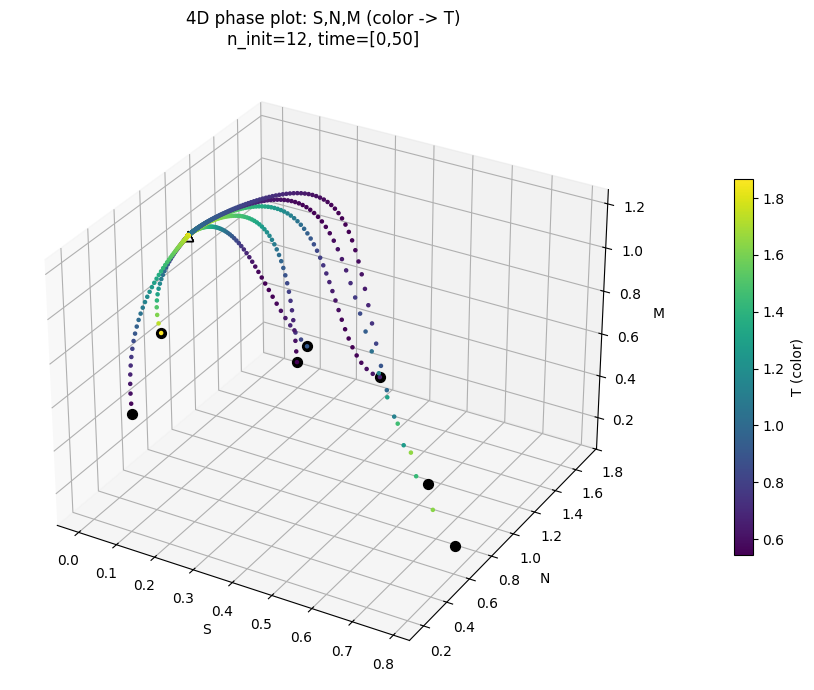

In [27]:
import numpy as np
from scipy.integrate import solve_ivp

# 4D phase-plot via 3D projections + color for the 4th variable
# Uses the already defined `system_adim_oliv` function and available imports (numpy, matplotlib, solve_ivp).
# Place this cell at index 35.

import matplotlib.pyplot as plt

def plot_4d_phase(system_func,
                  params=None,
                  n_trajectories=12,
                  bounds=(0.0, 2.0),
                  duree=20.0,
                  t_steps=300,
                  axes_names=('S','N','M','T'),
                  show_arrows=True,
                  cmap='viridis',
                  figsize=(10,7)):
    """
    Plot trajectories in 3D with the 4th variable encoded as color.
    - system_func : f(t, y, *params) as defined in the notebook (system_adim_oliv)
    - params : tuple/list of parameters passed to system_func (alpha, beta, gamma, delta_N, delta_M, a, b)
               If None, uses a reasonable default.
    - n_trajectories : number of initial conditions sampled in the hypercube
    - bounds : (low, high) for sampling each variable in the hypercube [low, high]^4
    - duree : integration time
    - t_steps : number of time points for t_eval
    - axes_names : names for axes (for labels)
    - show_arrows : mark start and end points of each trajectory
    """
    if params is None:
        params = (1, 1, 1, 1, 1, 0.35, 1)  # alpha, beta, gamma, delta_N, delta_M, a, b

    low, high = bounds
    t_eval = np.linspace(0, duree, t_steps)

    # Sample random initial conditions in the 4D hypercube
    inits = np.random.uniform(low, high, size=(n_trajectories, 4))

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # map axes indices
    axis_idx = {name: i for i, name in enumerate(axes_names)}
    # We'll plot S vs N vs M on the 3D axes and color by T by default.
    x_key, y_key, z_key, color_key = axes_names[0], axes_names[1], axes_names[2], axes_names[3]
    xi, yi, zi, ci = axis_idx[x_key], axis_idx[y_key], axis_idx[z_key], axis_idx[color_key]

    all_cvalues = []
    scatters = []

    for i, y0 in enumerate(inits):
        sol = solve_ivp(system_func, [0, duree], y0, method='Radau', t_eval=t_eval, args=tuple(params))
        if not sol.success:
            continue
        Y = sol.y  # shape (4, len(t_eval))
        X = Y[xi]
        Yv = Y[yi]
        Z = Y[zi]
        C = Y[ci]
        # scatter colored by 4th variable along the trajectory
        p = ax.scatter(X, Yv, Z, c=C, cmap=cmap, s=5, alpha=1)
        scatters.append(p)
        all_cvalues.append(C)
        if show_arrows:
            # mark start and end
            ax.scatter(X[0], Yv[0], Z[0], color='k', marker='o', s=50)
            ax.scatter(X[-1], Yv[-1], Z[-1], color='white', edgecolor='k', marker='^', s=50)

    # colorbar based on concatenated color values
    if len(all_cvalues) > 0:
        allc = np.concatenate(all_cvalues)
        mappable = plt.cm.ScalarMappable(cmap=cmap)
        mappable.set_array(allc)
        cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1)
        cbar.set_label(f'{color_key} (color)')

    ax.set_xlabel(x_key)
    ax.set_ylabel(y_key)
    ax.set_zlabel(z_key)
    ax.set_title(f'4D phase plot: {x_key},{y_key},{z_key} (color -> {color_key})\n'
                 f'n_init={n_trajectories}, time=[0,{duree}]')
    ax.grid(True)
    plt.tight_layout()
    plt.show()


# Example usage with the notebook's system_adim_oliv and typical parameters:
plot_4d_phase(system_adim_oliv,
              params=(1, 1, 1, 1, 1, 0.35, 1),
              n_trajectories=12,
              bounds=(0.0, 2.0),
              duree=50,
              t_steps=500)

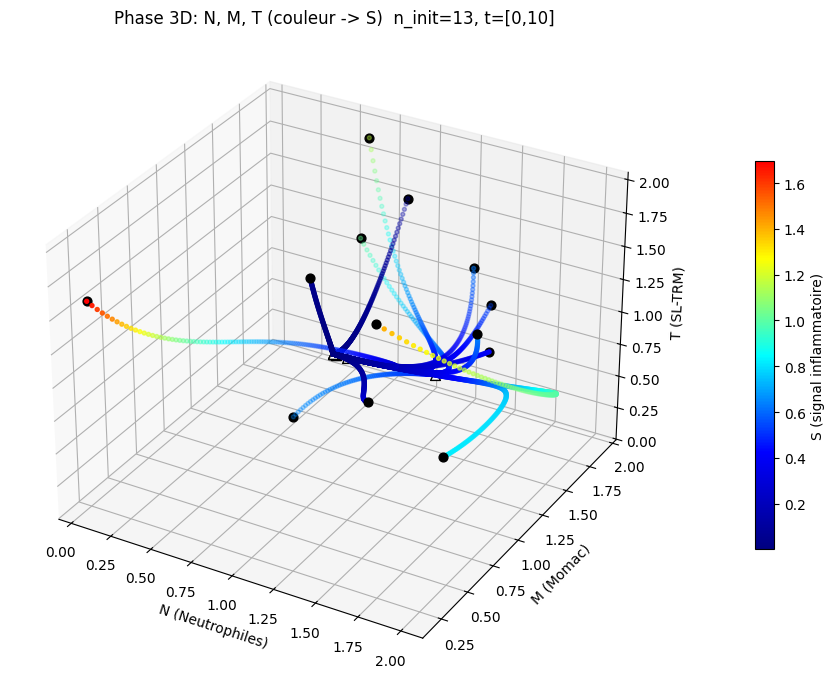

In [28]:
def plot_NMT_color_S(system_func,
                     params=None,
                     n_trajectories=12,
                     bounds=(0.0, 2.0),
                     duree=20.0,
                     t_steps=300,
                     show_arrows=True,
                     cmap_name='blue_red',
                     figsize=(10,7)):
    """
    Trace en 3D les trajectoires sur les axes N (x), M (y), T (z) et colore par S (signal).
    - system_func : f(t, y, *params) (ex: system_adim_oliv)
    - params : tuple (alpha, beta, gamma, delta_N, delta_M, a, b)
    - n_trajectories : nombre d'ICs
    - bounds : (low, high) intervalle d'échantillonnage pour chaque variable initiale
    - duree, t_steps : intégration
    - cmap_name : nom interne pour la cmap créée (navy -> red)
    """
    import matplotlib.colors as mcolors

    if params is None:
        params = (1, 1, 1, 1, 1, 0.35, 1)

    low, high = bounds
    t_eval = np.linspace(0, duree, t_steps)

    # échantillonnage des conditions initiales dans le cube 4D
    inits = np.random.uniform(low, high, size=(n_trajectories, 4))

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # indices: S=0, N=1, M=2, T=3
    xi, yi, zi, ci = 1, 2, 3, 0  # N, M, T axes; couleur = S

    all_cvalues = []

    # construire cmap allant du bleu profond (navy) au rouge
    cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, ['navy', 'blue', 'cyan', 'yellow', 'red'])

    trajs = []
    for y0 in inits:
        sol = solve_ivp(system_func, [0, duree], y0, method='Radau', t_eval=t_eval, args=tuple(params))
        if not sol.success:
            continue
        Y = sol.y
        X = Y[xi]
        Yv = Y[yi]
        Z = Y[zi]
        C = Y[ci]
        trajs.append((X, Yv, Z, C))
        all_cvalues.append(C)

    if len(trajs) == 0:
        print("Aucune trajectoire calculée avec succès.")
        return

    allc = np.concatenate(all_cvalues)
    vmin, vmax = np.min(allc), np.max(allc)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for X, Yv, Z, C in trajs:
        p = ax.scatter(X, Yv, Z, c=C, cmap=cmap, norm=norm, s=8)
        if show_arrows:
            ax.scatter(X[0], Yv[0], Z[0], color='k', marker='o', s=40)            # début
            ax.scatter(X[-1], Yv[-1], Z[-1], color='white', edgecolor='k', marker='^', s=50)  # fin

    # colorbar
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(allc)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1)
    cbar.set_label('S (signal inflammatoire)')

    ax.set_xlabel('N (Neutrophiles)')
    ax.set_ylabel('M (Momac)')
    ax.set_zlabel('T (SL-TRM)')
    ax.set_title(f'Phase 3D: N, M, T (couleur -> S)  n_init={len(trajs)}, t=[0,{duree}]')
    ax.grid(True)
    plt.tight_layout()
    plt.show()


# Exemple d'utilisation :
plot_NMT_color_S(system_adim_oliv,
                 params=(1, 1, 1, 1, 1, 0.3, 1),
                 n_trajectories=20,
                 bounds=(0.0, 2.0),
                 duree=10,
                 t_steps=500)

Il faut étudier avec précision les équilibres et les conditions de stabilité du système.

In [29]:
from itertools import product

# 2D projection of 4D points using a tesseract (4-hypercube) as reference.
# Uses existing `pts` (Nx4 numpy array) and plotting imports already present in the notebook.
# build `pts` as the entire trajectories of `system_adim_oliv` (concatenated time samples)
np.random.seed(0)
params = (1, 1, 1, 1, 1, 0.35, 1)   # alpha, beta, gamma, delta_N, delta_M, a, b
low, high = 0.0, 1.0
n_pts = 20
duree = 20.0

inits = np.random.uniform(low, high, size=(n_pts, 4))
all_traj = []

# choose time sampling for each trajectory
n_time = max(2, int(duree * 10) + 1)  # ~10 samples per time unit
t_eval = np.linspace(0.0, duree, n_time)

for y0 in inits:
    sol = solve_ivp(system_adim_oliv, [0.0, duree], y0, args=tuple(params), t_eval=t_eval, method='Radau')
    if sol.success:
        # sol.y shape is (4, n_time) -> transpose to (n_time, 4) and collect
        all_traj.append(sol.y.T)

# If no trajectories succeeded, fall back to using the initial points (one sample each)
if len(all_traj) == 0:
    pts = inits.copy()
else:
    # concatenate all time samples from all trajectories into a single (N_total x 4) array
    pts = np.vstack(all_traj)

print(f"pts shape: {pts.shape}  (N_total x 4)  -- concatenated time samples from trajectories")
#####
def plot_tesseract_2d_projection(points=pts,
                                 bounds=(0.0, 1.0),
                                 figsize=(8,8),
                                 annotate_vertices=False,
                                 show_axis_arrows=True,
                                 vertex_color='C3',
                                 point_color='k',
                                 point_alpha=0.8,
                                 point_s=1):
    """
    Project a 4D hypercube (tesseract) into 2D and plot:
    - the projected hypercube edges (reference),
    - the projected sample points (points, Nx4).
    The projection is an orthographic linear map from R^4 -> R^2 chosen for a clear tesseract drawing.
    """
    low, high = bounds
    # build 16 vertices of the hypercube [low,high]^4
    verts4 = np.array(list(product([low, high], repeat=4)))  # shape (16,4)
    # center at the middle of the hypercube for better visualization
    center = np.array([(low + high) / 2.0] * 4)

    # choose a 2x4 projection matrix (columns are images of the 4 canonical basis vectors)
    # Intuition: first two axes map mostly to x/y, last two are tilted so inner/outer square appears.
    P = np.array([
        [ 1.0,  0.0,  0.45, -0.35],   # x component
        [ 0.0,  1.0,  0.30,  0.50],   # y component
    ])
    # normalize column contributions a bit for balanced look
    colnorms = np.linalg.norm(P, axis=0)
    P = P / colnorms * 0.9

    # project vertices and points (centered first)
    proj_verts = (verts4 - center) @ P.T   # (16,2)
    pts_proj = (points - center) @ P.T     # (N,2)

    # draw
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal', 'box')

    # draw hypercube edges (connect vertices with Hamming distance 1)
    for i in range(len(verts4)):
        for j in range(i+1, len(verts4)):
            # Hamming distance = number of differing coordinates
            if np.sum(np.abs(verts4[i] - verts4[j]) > 1e-12) == 1:
                x = [proj_verts[i,0], proj_verts[j,0]]
                y = [proj_verts[i,1], proj_verts[j,1]]
                ax.plot(x, y, color='gray', linewidth=0.9, zorder=1)

    # draw vertices (outer/inner square corners)
    ax.scatter(proj_verts[:,0], proj_verts[:,1], color=vertex_color, s=40, zorder=3, edgecolor='k')

    if annotate_vertices:
        for v, coords in zip(verts4, proj_verts):
            label = ''.join(str(int(x)) for x in v)  # binary label e.g. '0101'
            ax.text(coords[0], coords[1], label, fontsize=8, ha='center', va='center')

    # optional: show arrows representing the four canonical 4D axes (projected)
    if show_axis_arrows:
        origin = np.zeros(2)
        # projected directions of unit vectors e1..e4
        e_dirs = P.T  # shape (4,2)
        for i, d in enumerate(e_dirs):
            ax.arrow(origin[0], origin[1], d[0]*0.9, d[1]*0.9,
                     head_width=0.03, head_length=0.04, fc='C{}'.format(i+1),
                     ec='C{}'.format(i+1), length_includes_head=True, linewidth=1.2, zorder=4)
            ax.text(d[0]*1.02, d[1]*1.02, f'e{i+1}', color=f'C{i+1}', fontsize=10)

    # plot the projected sample points
    ax.scatter(pts_proj[:,0], pts_proj[:,1], c=point_color, s=point_s, alpha=point_alpha, zorder=5)

    ax.set_title("2D projection of 4D points with tesseract (hypercube) reference")
    ax.axis('off')
    plt.tight_layout()
    #plt.show()



pts shape: (3819, 4)  (N_total x 4)  -- concatenated time samples from trajectories


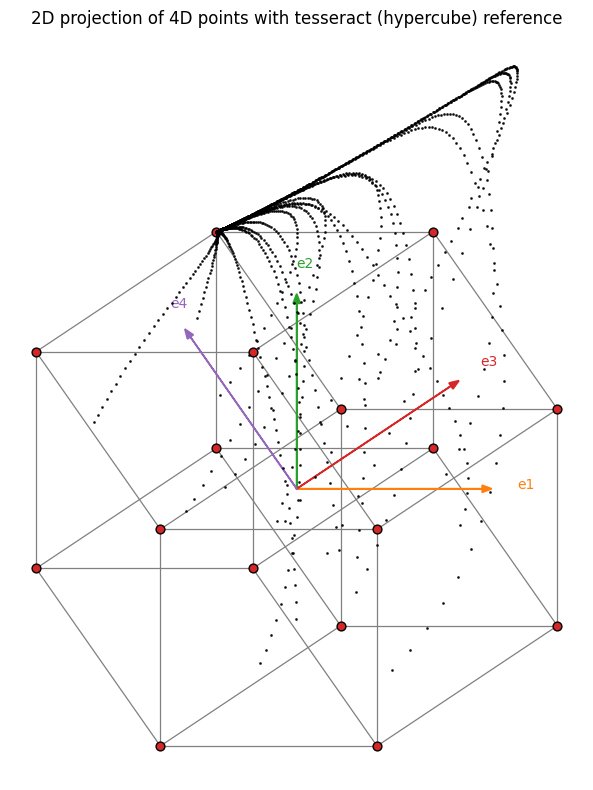

In [30]:
# generate and save the tesseract phase-space projection (uses existing `plot_tesseract_2d_projection` and `pts`)
plot_tesseract_2d_projection(points=pts, annotate_vertices=False, figsize=(8,8))
plt.savefig('phase_space_tesseract.png', format='png', bbox_inches='tight', dpi=150)

interface graphique pour trouver les points d'équilibre non triviaux, intersection de la parabole
$$
N^* = 1 + \frac{\alpha \delta_M}{\beta \delta_N} M^* (M^* - 1)
$$
et de l'hyperbole
$$
M^* =  \frac{a \,\gamma \,\delta_N}{b\, \alpha \,\delta_M} \frac{N^* (N^* - 1)}{(1 - \frac{a}{b} N^*)}
=-\frac{\gamma \delta_N}{\alpha \delta_M}  (N^* + b/a -1) + \frac{(b/a)^{2}(1-b/a)}{(N^* - b/a)} 

$$


In [31]:
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

import matplotlib.pyplot as plt

def plot_equilibres(a_b=1.0, alpha_beta=1.0, gamma_alpha=1.0, deltaN_deltaM=1.0):
    # N* range, avoid division by zero
    N = np.linspace(-10, 10, 2000)
    M = np.linspace(-10, 20, 2000)
    
    N_parabole= 1 + (alpha_beta/deltaN_deltaM)*(M - 1)*M
    #M_hyperbole = (a_b*gamma_alpha * deltaN_deltaM * N * (N - 1)) / (1 - a_b*N)

    # Avoid division by zero for N/a_b and N_star/a_b
    # Hyperbole : séparer les deux branches
    N_safe_left = N[N < 1/a_b - 1e-6]
    N_safe_right = N[N > 1/a_b + 1e-6]
    #M_hyperbole_left = (a_b*gamma_alpha * deltaN_deltaM * N_safe_left * (N_safe_left - 1)) / (1 - N_safe_left*a_b)
    #M_hyperbole_right = (a_b*gamma_alpha * deltaN_deltaM * N_safe_right * (N_safe_right - 1)) / (1 - N_safe_right*a_b)
    M_hyperbole_left = -gamma_alpha*deltaN_deltaM*(N_safe_left + 1/a_b -1)+ (1/a_b)**2 *(1- 1/a_b)/(N_safe_left - 1/a_b)
    M_hyperbole_right = -gamma_alpha*deltaN_deltaM*(N_safe_right + 1/a_b -1)+ (1/a_b)**2 *(1- 1/a_b)/(N_safe_right - 1/a_b)
    # tracé
    plt.figure(figsize=(8,6))
    plt.plot(N_parabole, M, label="nullcline N", color='blue')
    plt.plot(N_safe_left, M_hyperbole_left, label="", color='red')
    plt.plot(N_safe_right, M_hyperbole_right, label="nullcline M ", color='red')
    plt.plot(N, (-gamma_alpha * deltaN_deltaM * (N + 1/a_b -1) ), label="oblique asymptote", color='k', linestyle=':', linewidth=1)
    plt.plot((1/a_b)*np.ones_like(M), M, 'k:', label=" vertical asymptote N=b/a")
    plt.xlabel('$N^*$')
    plt.ylabel('$M^*$')
    plt.title(f"Equilibria points\n a/b={a_b:.2f}, α/β={alpha_beta:.2f}, γ/α={gamma_alpha:.2f}, δN/δM={deltaN_deltaM:.2f}")
    plt.ylim(-10, 10)
    plt.xlim(-10, 20)
    plt.legend()
    plt.grid(True)
    #plt.show()

interact(
    plot_equilibres,
    a_b=widgets.FloatSlider(min=0.1, max=10.0, step=0.01, value=1.0, description='a/b'),
    alpha_beta=widgets.FloatSlider(min=0.1, max=10.0, step=0.01, value=1.0, description='α/β'),
    gamma_alpha=widgets.FloatSlider(min=0.1, max=100, step=0.01, value=1.0, description='γ/α'),
    deltaN_deltaM=widgets.FloatSlider(min=0.1, max=10.0, step=0.01, value=1.0, description='δN/δM')
)


interactive(children=(FloatSlider(value=1.0, description='a/b', max=10.0, min=0.1, step=0.01), FloatSlider(val…

<function __main__.plot_equilibres(a_b=1.0, alpha_beta=1.0, gamma_alpha=1.0, deltaN_deltaM=1.0)>

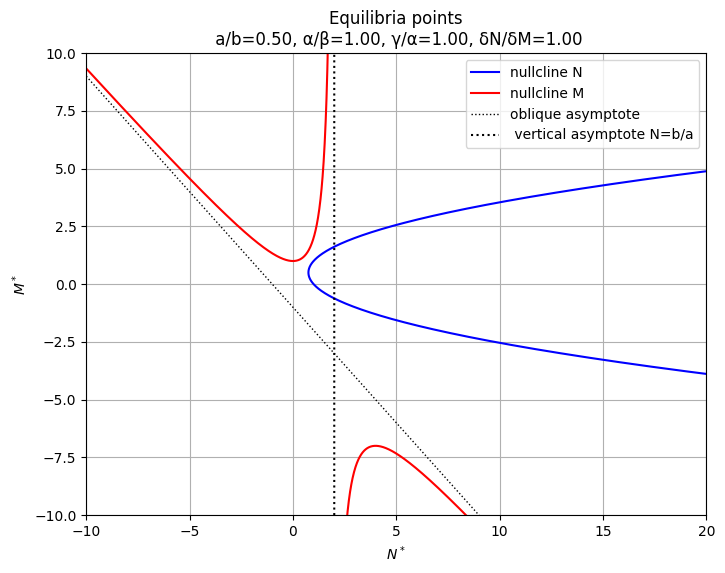

In [32]:
plot_equilibres(a_b=0.5, alpha_beta=1, gamma_alpha=1, deltaN_deltaM=1)
plt.savefig('equilibres.png', format = 'png')

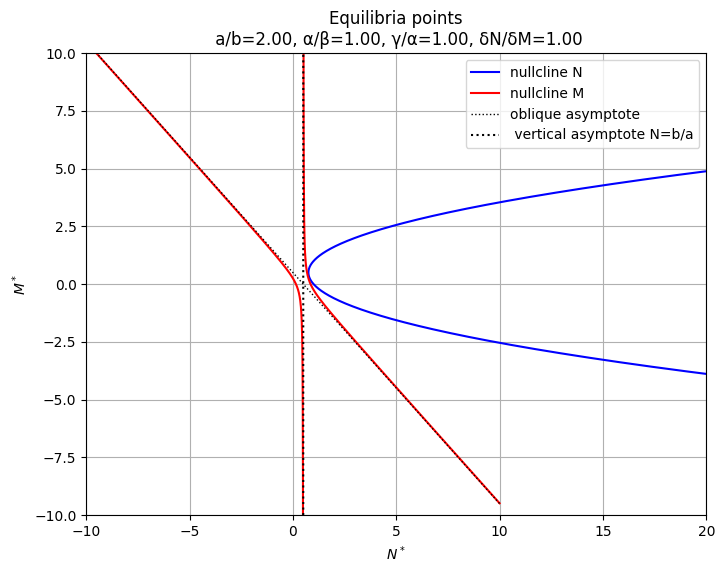

In [33]:
plot_equilibres(a_b=2, alpha_beta=1, gamma_alpha=1, deltaN_deltaM=1 )
plt.savefig('equilibres_1.png', format = 'png')


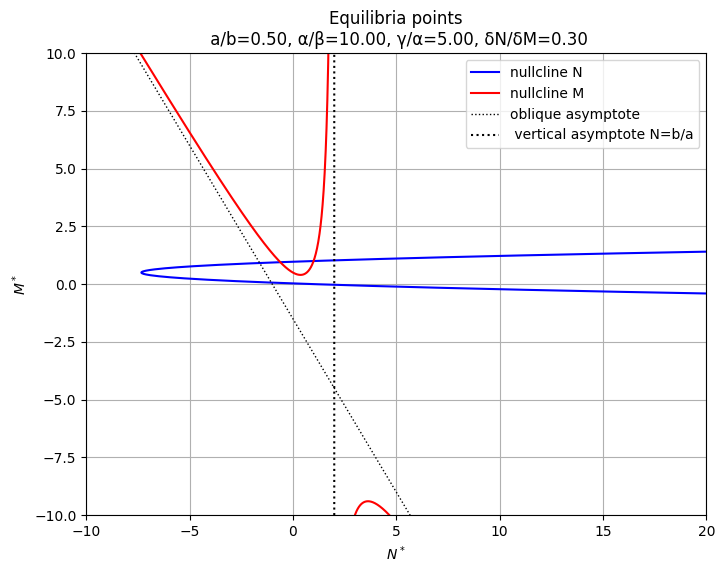

In [34]:
plot_equilibres(a_b=0.5, alpha_beta=10, gamma_alpha=5, deltaN_deltaM=0.3 )
plt.savefig('equilibres_2.png', format = 'png')

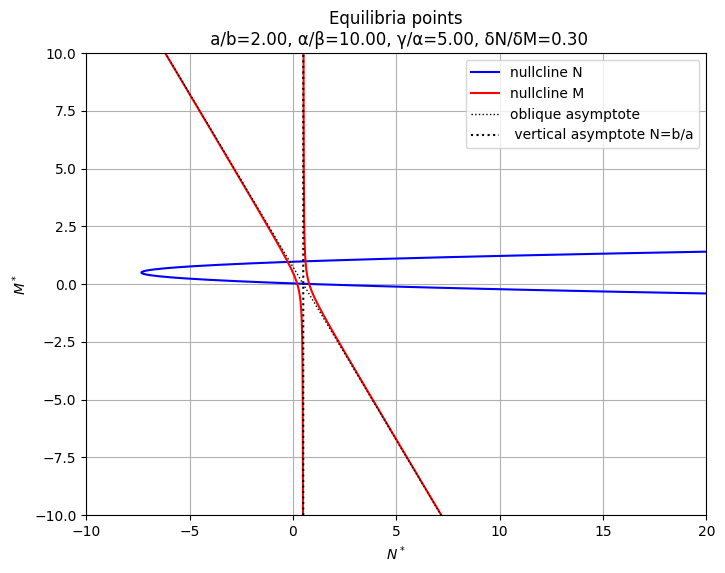

In [35]:
plot_equilibres(a_b=2, alpha_beta=10, gamma_alpha=5, deltaN_deltaM=0.3 )
plt.savefig('equilibres_3.png', format = 'png')

In [36]:
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

import matplotlib.pyplot as plt
def plot_cubics(A=1.0, B=1.0, C=1.0):
    # Example cubic: T**3 + p*T**2 + q*T + r
    T = np.linspace(-0.5, 6, 500)
    p = A *  (1 - B - C) /C # Coefficient for T^2
    q = A  * (2 * B - 1) /C         # Coefficient for T
    r = -A * B / C                   # Constant term
    Y = T**3 + p * T**2 + q * T + r
    # Calculate the discriminant
    s = A*(-A*(B + C - 1)**2 + 3*C*(2*B - 1))/(3*C**2)
    t = A*(-2*A**2*(B + C - 1)**3 + 9*A*C*(2*B - 1)*(B + C - 1) - 27*B*C**2)/(27*C**3)
    Delta = (t/2)**2 + (s/3)**3
    # Calculate roots based on the sign of the discriminant
    if Delta >= 0:
        root = np.cbrt(-t/2 + np.sqrt(Delta)) + np.cbrt(-t/2 - np.sqrt(Delta)) - p/3
        # do not forget to adjust root by -p/3 to get roots of original cubic
    else:
        theta = np.arccos(3*np.sqrt(3)*t/ (2*s*np.sqrt(-s)))
        root = [2 * np.sqrt(-s/3) * np.cos((theta + 2 * k * np.pi)/3) - p/3 for k in range(3)]
        root = np.sort(np.array(root))
        # do not forget to adjust roots by -p/3 to get roots of original cubic

    plt.figure(figsize=(8, 5))
    plt.plot(T, Y, label=f'T³ + {p:.2f}·T² + {q:.2f}·T + {r:.2f}')
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.xlabel('T')
    plt.ylabel('Cubic polynomial')
    plt.title(rf"Equilibria points A={A:.2f}, B={B:.2f}, C={C:.2f}, $\Delta_3$={Delta:.2f}")
    plt.figtext(0.98, 0.02, f'root={np.round(root, 2)}', ha='right', va='bottom', fontsize=12)
    plt.legend()
    plt.grid(True)
    #plt.show()


In [37]:
interact(
    plot_cubics,
    A=widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='A'),
    B=widgets.FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description='B'),
    C=widgets.FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='C')
    
)

interactive(children=(FloatSlider(value=1.0, description='A', max=5.0, min=0.1), FloatSlider(value=1.0, descri…

<function __main__.plot_cubics(A=1.0, B=1.0, C=1.0)>

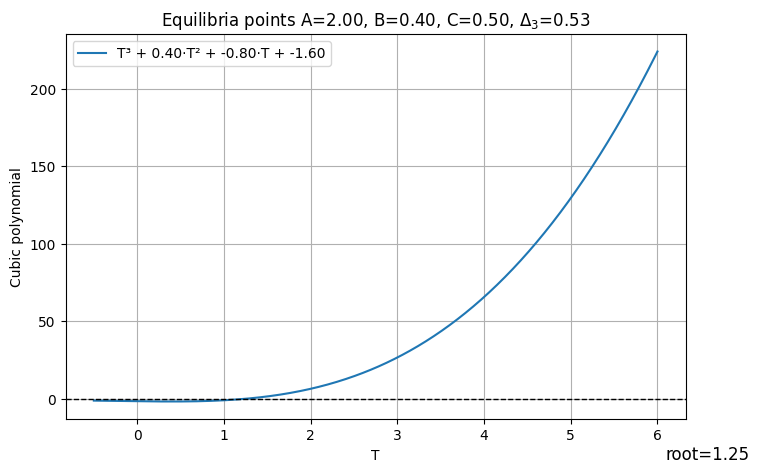

In [38]:
plot_cubics(A=2, B=0.4, C=0.5)
plt.savefig('cubic_1.png', format = 'png')

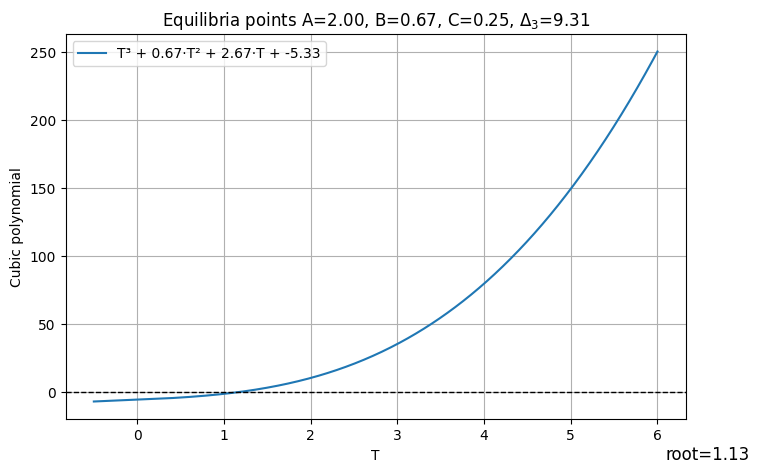

In [39]:
plot_cubics(A=2, B=2/3, C=1/4)
plt.savefig('cubic_2.png', format = 'png')

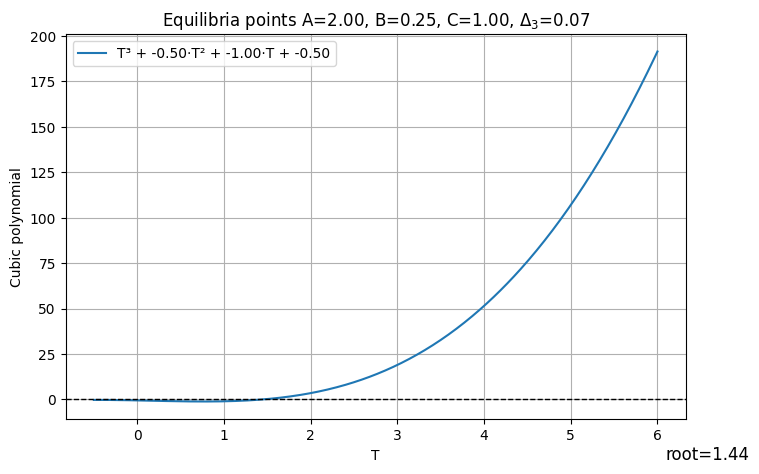

In [40]:
plot_cubics(A=2, B=0.25, C=1)
plt.savefig('cubic_3.png', format = 'png')

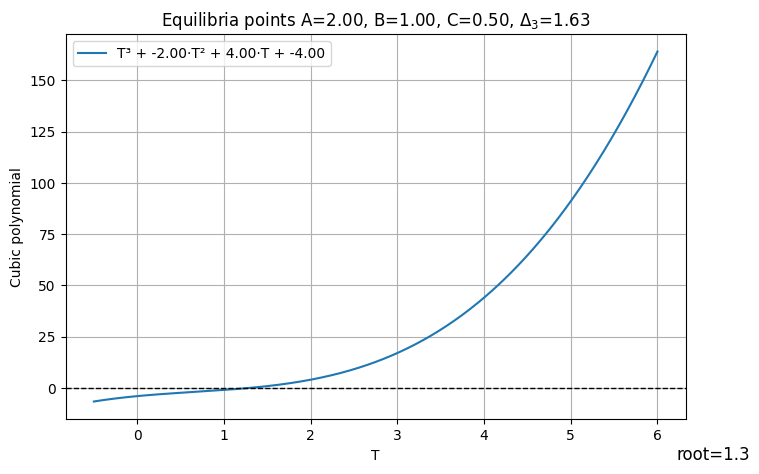

In [41]:
plot_cubics(A=2, B=1, C=0.5)
plt.savefig('cubic_4.png', format = 'png')

In [42]:
import sympy as sp
from sympy import factor, cancel, factor_terms, together, radsimp, simplify

# Define symbolic variables
A, B, C = sp.symbols('A B C ')
T = sp.symbols('T')

# Compute the coefficient for T^2 symbolically
p = A * (1 - B - C) / C # Coefficient for T^2

# Optionally, display the simplified expression
p_simplified = sp.simplify(p)
print("Symbolic expression for p:", p)
print("Simplified:", p_simplified)
q = A * (2 * B - 1) / C         # Coefficient for T
r = -A * B / C                   # Constant term
s = q - p_simplified**2 / 3
s_simplified = sp.simplify(s)
print("Symbolic expression for s:", s)
print("Simplified:", s_simplified)
t = (2 * p_simplified**3 / 27) - (p_simplified * q / 3) + r
t_simplified = sp.simplify(t)
print("Symbolic expression for t:", t)
print("Simplified:", t_simplified)
discrim = (t_simplified / 2)**2 + (s_simplified / 3)**3
discrim_simplified = sp.simplify(discrim)
print("Symbolic expression for discriminant:", discrim)
print("Simplified:", discrim_simplified)
# essayer plusieurs stratégies de simplification et afficher les résultats

# 1) facturation globale
disc_factored = factor(discrim_simplified)
print("factor(discrim_simplified):")
print(disc_factored)
print()

# 2) annulation des facteurs communs (écrire sous forme rationnelle si possible)
disc_canceled = cancel(discrim_simplified)
print("cancel(discrim_simplified):")
print(disc_canceled)
print()

# 3) mise sur un seul dénominateur
disc_together = together(discrim_simplified)
print("together(discrim_simplified):")
print(disc_together)
print()

# 4) simplification algébrique / radicale
disc_radsimp = radsimp(discrim_simplified)
print("radsimp(discrim_simplified):")
print(disc_radsimp)
print()

# 5) factorisation des termes numériques/communs
disc_factor_terms = factor_terms(discrim_simplified)
print("factor_terms(discrim_simplified):")
print(disc_factor_terms)
print()

# 6) extraire un préfacteur évident A**2/(2916*C**6) et factoriser l'intérieur
prefactor = A**2/(2916*C**6)
inner = simplify(discrim_simplified / prefactor)
inner_factored = factor(inner)
print("Après extraction du préfacteur A**2/(2916*C**6) :")
print("inner (simplified) =")
print(inner_factored)
print()

# 7) proposition finale : forme la plus compacte trouvée
candidates = [disc_factored, disc_canceled, disc_together, disc_radsimp, disc_factor_terms, prefactor*inner_factored]
best = simplify(candidates[-1])  # on propose l'option avec préfacteur comme résultat lisible
print("Proposition finale (préfacteur * expression factorisée) :")
print(best)

#expression Oana
disc_oana= A**2/(108*C**4)*(A**2*(B + C - 1)**2*(4*B*C-1)-2*A*C*(2*B-1)*(B**2-B-2+9*B*C) + 27*B**2*C**2)
print("Expression proposée par Oana :")
print(disc_oana)
simplify(disc_oana - best)  # doit être nul si les deux expressions sont équivalentes
#calculons le sous-discriminant du trinôme en A dans disc_oana
trinom = A**2*(B + C - 1)**2*(4*B*C-1)-2*A*C*(2*B-1)*(B**2-B-2+9*B*C) + 27*B**2*C**2
A_coeff = (B + C - 1)**2 * (4*B*C - 1)
B_coeff = -2 * C * (2*B - 1) * (B**2 - B - 2 + 9*B*C)
C_coeff = 27 * B**2 * C**2
discriminant_trinom = B_coeff**2 - 4 * A_coeff * C_coeff
simplified_discriminant_trinom = simplify(discriminant_trinom)
print("Discriminant du trinôme en A dans disc_oana :")
print(simplified_discriminant_trinom)
# Factorisation du trinôme en A et de son discriminant
fact_trinom = factor(trinom)
#poly_fact_trinom = sp.factor_poly(trinom, A)  # factorisation algébrique en A (Poly si possible)
fact_disc_trinom = factor(simplified_discriminant_trinom)

print("factor(trinom) =")
print(fact_trinom)
#print("\nfactor_poly(trinom, A) =")
#print(poly_fact_trinom)
print("\nfactor(discriminant_trinom) =")
print(fact_disc_trinom)
print("\nverification =")  
print(simplify(fact_disc_trinom - simplified_discriminant_trinom))  # doit être nul si la factorisation est correcte
# du signe de ce sous discriminant dépend le nombre de racines réelles du trinôme en A dans disc_oana

Symbolic expression for p: A*(-B - C + 1)/C
Simplified: A*(-B - C + 1)/C
Symbolic expression for s: -A**2*(-B - C + 1)**2/(3*C**2) + A*(2*B - 1)/C
Simplified: A*(-A*(B + C - 1)**2 + 3*C*(2*B - 1))/(3*C**2)
Symbolic expression for t: 2*A**3*(-B - C + 1)**3/(27*C**3) - A**2*(2*B - 1)*(-B - C + 1)/(3*C**2) - A*B/C
Simplified: A*(-2*A**2*(B + C - 1)**3 + 9*A*C*(2*B - 1)*(B + C - 1) - 27*B*C**2)/(27*C**3)
Symbolic expression for discriminant: A**3*(-A*(B + C - 1)**2 + 3*C*(2*B - 1))**3/(729*C**6) + A**2*(-2*A**2*(B + C - 1)**3 + 9*A*C*(2*B - 1)*(B + C - 1) - 27*B*C**2)**2/(2916*C**6)
Simplified: A**2*(-4*A*(A*(B + C - 1)**2 - 3*C*(2*B - 1))**3 + (2*A**2*(B + C - 1)**3 - 9*A*C*(2*B - 1)*(B + C - 1) + 27*B*C**2)**2)/(2916*C**6)
factor(discrim_simplified):
A**2*(4*A**2*B**3*C + 8*A**2*B**2*C**2 - 8*A**2*B**2*C - A**2*B**2 + 4*A**2*B*C**3 - 8*A**2*B*C**2 + 2*A**2*B*C + 2*A**2*B - A**2*C**2 + 2*A**2*C - A**2 - 4*A*B**3*C - 36*A*B**2*C**2 + 6*A*B**2*C + 18*A*B*C**2 + 6*A*B*C - 4*A*C + 27*B**2*C**

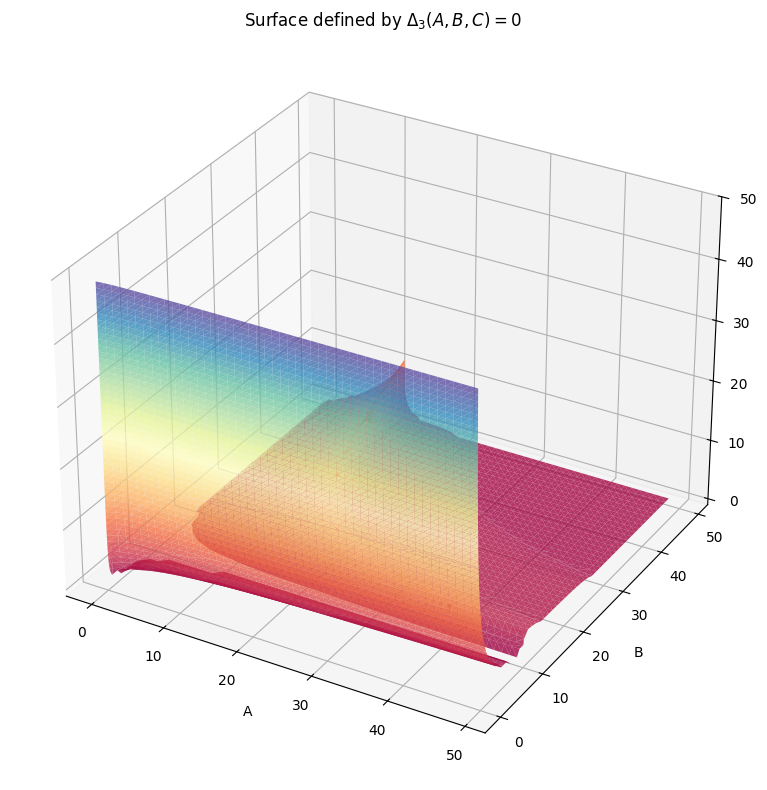

In [43]:
#%matplotlib notebook
# pour avoir une figure interactive

import numpy as np
import matplotlib.pyplot as plt

from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d import Axes3D
from IPython import get_ipython

# Définir la fonction implicite
def f(A, B, C):
    # accepts numpy arrays (C can be vector)
    return A**2 * (-4*A*(A*(B + C - 1)**2 - 3*C*(2*B - 1))**3
                   + (2*A**2*(B + C - 1)**3 - 9*A*C*(2*B - 1)*(B + C - 1)
                       + 27*B*C**2)**2) / (2916 * C**6)

# Créer une grille 3D de points
x_min, x_max = 0.01, 5
y_min, y_max = 0.01, 5
z_min, z_max = 0.01 , 5
resolution = 50

x = np.linspace(x_min, x_max, resolution)
y = np.linspace(y_min, y_max, resolution)
z = np.linspace(z_min, z_max, resolution)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Évaluer la fonction sur la grille
vol = f(X, Y, Z)

# Appliquer marching cubes pour extraire la surface
verts, faces, _, _ = marching_cubes(vol, level=0)

# Tracer la surface
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                cmap='Spectral', lw=0.1, alpha=0.8)

# Ajouter des labels et un titre
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_zlabel('C')
ax.set_title(r"Surface defined by $\Delta_3(A,B,C) = 0$")
plt.draw()
plt.tight_layout()
plt.show()


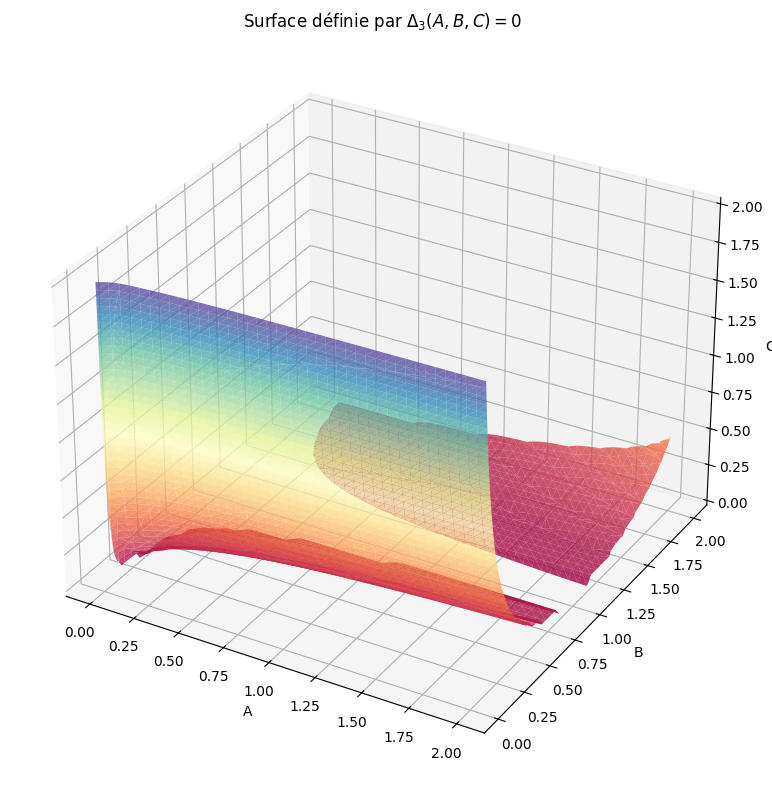

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage.measure import marching_cubes

def implicit_plot3d(f, xrange, yrange, zrange, resolution=50, level=0, 
                    cmap='viridis', alpha=0.8, title=None, labels=None):
    """
    Trace une surface implicite 3D définie par f(x,y,z) = level
    
    Paramètres:
    -----------
    f : fonction
        Fonction qui prend trois arrays (X, Y, Z) et retourne un array de valeurs
    xrange : tuple (xmin, xmax)
        Plage pour l'axe x
    yrange : tuple (ymin, ymax)
        Plage pour l'axe y
    zrange : tuple (zmin, zmax)
        Plage pour l'axe z
    resolution : int
        Nombre de points par axe (défaut: 50)
    level : float
        Niveau de l'isosurface (défaut: 0)
    cmap : str
        Colormap matplotlib (défaut: 'viridis')
    alpha : float
        Transparence (0=transparent, 1=opaque)
    title : str
        Titre du graphique
    labels : tuple (xlabel, ylabel, zlabel)
        Labels des axes
    """
    # Créer la grille
    x = np.linspace(xrange[0], xrange[1], resolution)
    y = np.linspace(yrange[0], yrange[1], resolution)
    z = np.linspace(zrange[0], zrange[1], resolution)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    # Évaluer la fonction
    vol = f(X, Y, Z)
    
    # Extraire la surface avec marching cubes
    try:
        verts, faces, _, _ = marching_cubes(vol, level=level)
        
        # Rescale vertices to actual coordinates
        verts[:, 0] = verts[:, 0] * (xrange[1] - xrange[0]) / (resolution - 1) + xrange[0]
        verts[:, 1] = verts[:, 1] * (yrange[1] - yrange[0]) / (resolution - 1) + yrange[0]
        verts[:, 2] = verts[:, 2] * (zrange[1] - zrange[0]) / (resolution - 1) + zrange[0]
        
        # Créer le graphique
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Tracer la surface
        ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                       cmap=cmap, lw=0.1, alpha=alpha, edgecolor='none')
        
        # Labels et titre
        if labels:
            ax.set_xlabel(labels[0])
            ax.set_ylabel(labels[1])
            ax.set_zlabel(labels[2])
        else:
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            ax.set_zlabel('z')
            
        if title:
            ax.set_title(title)
            
        plt.tight_layout()
        return fig, ax
        
    except Exception as e:
        print(f"Erreur lors du tracé: {e}")
        print("Astuce: Essayez de changer la résolution ou vérifiez que f(x,y,z)=0 a des solutions dans les plages données")
        return None, None

# Exemple d'utilisation avec votre équation
def mon_equation(A, B, C):
    """Équation Delta_3(A,B,C) = 0"""
    return (A**2 * (-4*A*(A*(B + C - 1)**2 - 3*C*(2*B - 1))**3
                   + (2*A**2*(B + C - 1)**3 - 9*A*C*(2*B - 1)*(B + C - 1) + 27*B*C**2)**2) 
            / (2916 * C**6))

# Tracer la surface
fig, ax = implicit_plot3d(
    mon_equation,
    xrange=(0.01, 2),
    yrange=(0.01, 2), 
    zrange=(0.01, 2),
    resolution=40,  # Commence avec une résolution moyenne
    level=0,
    cmap='Spectral',
    alpha=0.8,
    title=r"Surface définie par $\Delta_3(A,B,C) = 0$",
    labels=('A', 'B', 'C')
)

plt.show()

## 🖱️ Mode interactif - Rotation 3D avec la souris

Pour avoir une rotation interactive des figures 3D (comme dans SageMath), utilisez la commande magique suivante **au début de votre notebook** ou avant vos tracés 3D :

```python
%matplotlib widget
```

**Alternative :** `%matplotlib notebook` (fonctionne aussi mais moins moderne)

**⚠️ Important :**
- Cette commande doit être exécutée **une seule fois** au début de votre session
- Si vous changez de backend, **redémarrez le kernel** pour éviter les conflits
- Pour revenir aux images statiques : `%matplotlib inline`

In [45]:
# Alternative 1: Mode notebook (plus stable dans VS Code)
%matplotlib notebook

print("✓ Mode interactif activé avec 'notebook' backend!")
print("  Vous pouvez maintenant faire tourner les figures 3D avec la souris.")
print("  - Clic gauche + glisser : rotation")
print("  - Clic droit + glisser : zoom")
print("  - Clic molette + glisser : translation")

✓ Mode interactif activé avec 'notebook' backend!
  Vous pouvez maintenant faire tourner les figures 3D avec la souris.
  - Clic gauche + glisser : rotation
  - Clic droit + glisser : zoom
  - Clic molette + glisser : translation


## 🎯 Solutions pour rotation 3D interactive

**Problème**: Les backends `widget` et `notebook` ont des problèmes JavaScript dans VS Code.

**Solutions disponibles**:

1. **Matplotlib statique** (fonctionne toujours) : `%matplotlib inline`
   - Pas d'interactivité mais images de haute qualité
   - Utilisez les paramètres `elev` et `azim` pour changer l'angle de vue

2. **Plotly** (meilleur pour l'interactivité) : Voir cellule suivante
   - ⚠️ Nécessite de redémarrer le kernel après installation de `nbformat`

3. **PyVista** (alternative professionnelle) : 
   - Installation: `pip install pyvista`
   - Rendu 3D interactif avancé

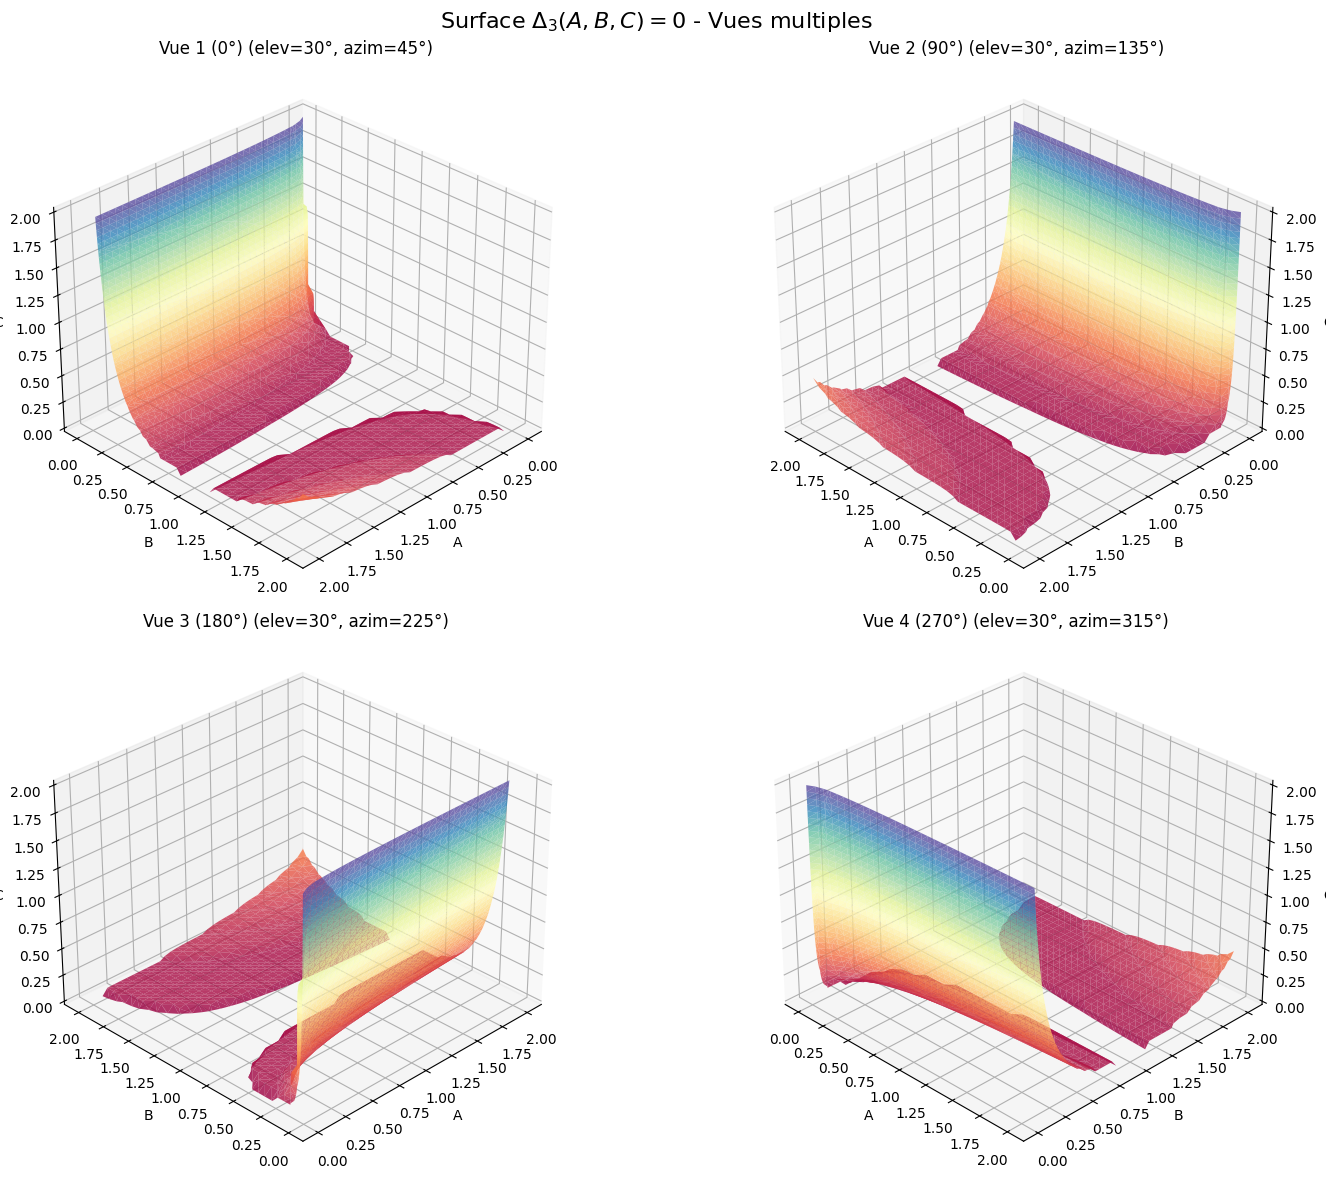

✓ 4 vues de la surface créées pour voir la géométrie sous différents angles !


In [46]:
%matplotlib inline
# Solution simple et fiable: Matplotlib avec différents angles de vue
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def implicit_plot3d_multiview(f, xrange, yrange, zrange, resolution=40, level=0,
                               cmap='Spectral', alpha=0.8, title=None, labels=None):
    """
    Crée 4 vues différentes de la surface implicite (comme une rotation manuelle)
    """
    from skimage.measure import marching_cubes
    import numpy as np
    
    # Créer la grille et évaluer
    x = np.linspace(xrange[0], xrange[1], resolution)
    y = np.linspace(yrange[0], yrange[1], resolution)
    z = np.linspace(zrange[0], zrange[1], resolution)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    vol = f(X, Y, Z)
    
    # Marching cubes
    verts, faces, _, _ = marching_cubes(vol, level=level)
    verts[:, 0] = verts[:, 0] * (xrange[1] - xrange[0]) / (resolution - 1) + xrange[0]
    verts[:, 1] = verts[:, 1] * (yrange[1] - yrange[0]) / (resolution - 1) + yrange[0]
    verts[:, 2] = verts[:, 2] * (zrange[1] - zrange[0]) / (resolution - 1) + zrange[0]
    
    # Créer 4 sous-graphiques avec différents angles
    fig = plt.figure(figsize=(16, 12))
    angles = [(30, 45), (30, 135), (30, 225), (30, 315)]  # (élévation, azimut)
    angle_names = ['Vue 1 (0°)', 'Vue 2 (90°)', 'Vue 3 (180°)', 'Vue 4 (270°)']
    
    axis_labels = labels if labels else ('x', 'y', 'z')
    
    for i, ((elev, azim), name) in enumerate(zip(angles, angle_names), 1):
        ax = fig.add_subplot(2, 2, i, projection='3d')
        ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                       cmap=cmap, lw=0.1, alpha=alpha, edgecolor='none')
        ax.set_xlabel(axis_labels[0])
        ax.set_ylabel(axis_labels[1])
        ax.set_zlabel(axis_labels[2])
        ax.set_title(f"{name} (elev={elev}°, azim={azim}°)")
        ax.view_init(elev=elev, azim=azim)
    
    if title:
        fig.suptitle(title, fontsize=16, y=0.98)
    
    plt.tight_layout()
    return fig

# Exemple avec votre équation
def mon_equation(A, B, C):
    return (A**2 * (-4*A*(A*(B + C - 1)**2 - 3*C*(2*B - 1))**3
                   + (2*A**2*(B + C - 1)**3 - 9*A*C*(2*B - 1)*(B + C - 1) + 27*B*C**2)**2) 
            / (2916 * C**6))

fig = implicit_plot3d_multiview(
    mon_equation,
    xrange=(0.01, 2),
    yrange=(0.01, 2),
    zrange=(0.01, 2),
    resolution=35,
    cmap='Spectral',
    title=r"Surface $\Delta_3(A,B,C) = 0$ - Vues multiples",
    labels=('A', 'B', 'C')
)
plt.show()

print("✓ 4 vues de la surface créées pour voir la géométrie sous différents angles !")

In [47]:
import numpy as np
import plotly.graph_objects as go
from skimage.measure import marching_cubes

def implicit_plot3d_plotly(f, xrange, yrange, zrange, resolution=50, level=0, 
                           colorscale='Viridis', opacity=0.8, title=None, labels=None):
    """
    Version Plotly de implicit_plot3d - 100% interactif dans VS Code !
    
    Avantages:
    - Rotation, zoom, pan avec la souris sans problèmes JavaScript
    - Meilleure performance
    - Tooltips interactifs
    - Export facile en HTML
    """
    # Créer la grille
    x = np.linspace(xrange[0], xrange[1], resolution)
    y = np.linspace(yrange[0], yrange[1], resolution)
    z = np.linspace(zrange[0], zrange[1], resolution)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    # Évaluer la fonction
    vol = f(X, Y, Z)
    
    # Extraire la surface avec marching cubes
    try:
        verts, faces, _, _ = marching_cubes(vol, level=level)
        
        # Rescale vertices to actual coordinates
        verts[:, 0] = verts[:, 0] * (xrange[1] - xrange[0]) / (resolution - 1) + xrange[0]
        verts[:, 1] = verts[:, 1] * (yrange[1] - yrange[0]) / (resolution - 1) + yrange[0]
        verts[:, 2] = verts[:, 2] * (zrange[1] - zrange[0]) / (resolution - 1) + zrange[0]
        
        # Créer le mesh 3D avec Plotly
        fig = go.Figure(data=[
            go.Mesh3d(
                x=verts[:, 0],
                y=verts[:, 1],
                z=verts[:, 2],
                i=faces[:, 0],
                j=faces[:, 1],
                k=faces[:, 2],
                colorscale=colorscale,
                opacity=opacity,
                intensity=verts[:, 2],  # Colorer selon z
                name='Surface',
                hoverinfo='x+y+z'
            )
        ])
        
        # Configuration du layout
        axis_labels = labels if labels else ('x', 'y', 'z')
        fig.update_layout(
            title=title if title else 'Surface implicite 3D',
            scene=dict(
                xaxis_title=axis_labels[0],
                yaxis_title=axis_labels[1],
                zaxis_title=axis_labels[2],
                aspectmode='data'
            ),
            width=900,
            height=700,
            showlegend=False
        )
        
        print("✓ Figure interactive créée ! Utilisez la souris pour:")
        print("  - Rotation: clic gauche + glisser")
        print("  - Zoom: molette ou clic droit + glisser")
        print("  - Pan: Shift + clic gauche + glisser")
        
        return fig
        
    except Exception as e:
        print(f"Erreur lors du tracé: {e}")
        return None

# Exemple avec votre équation
def mon_equation(A, B, C):
    """Équation Delta_3(A,B,C) = 0"""
    return (A**2 * (-4*A*(A*(B + C - 1)**2 - 3*C*(2*B - 1))**3
                   + (2*A**2*(B + C - 1)**3 - 9*A*C*(2*B - 1)*(B + C - 1) + 27*B*C**2)**2) 
            / (2916 * C**6))

# Tracer avec Plotly (interactif !) - la figure s'affiche automatiquement
fig = implicit_plot3d_plotly(
    mon_equation,
    xrange=(0.01, 2),
    yrange=(0.01, 2), 
    zrange=(0.01, 2),
    resolution=40,
    colorscale='Spectral',
    opacity=0.9,
    title=r"Surface Delta_3(A,B,C) = 0 - Version interactive Plotly",
    labels=('A', 'B', 'C')
)

# La figure s'affiche automatiquement dans VS Code
fig

✓ Figure interactive créée ! Utilisez la souris pour:
  - Rotation: clic gauche + glisser
  - Zoom: molette ou clic droit + glisser
  - Pan: Shift + clic gauche + glisser


## 📊 Fonction `implicit_plot3d` - Équivalent Python de SageMath

Cette fonction permet de tracer des surfaces implicites en 3D définies par $f(x,y,z) = 0$, similaire à `implicit_plot3d` de SageMath.

**Utilisation simple :**
```python
def ma_fonction(x, y, z):
    return x**2 + y**2 + z**2 - 1  # Sphère de rayon 1

implicit_plot3d(ma_fonction, 
                xrange=(-2, 2), 
                yrange=(-2, 2), 
                zrange=(-2, 2))
```

**Paramètres disponibles :**
- `resolution` : précision du maillage (plus élevé = plus détaillé mais plus lent)
- `level` : valeur de l'isosurface (par défaut 0)
- `cmap` : palette de couleurs ('viridis', 'Spectral', 'coolwarm', etc.)
- `alpha` : transparence (0 à 1)
- `title` : titre du graphique
- `labels` : tuple des labels des axes

**Astuce :** Si la surface ne s'affiche pas, essayez de :
1. Ajuster les plages `xrange`, `yrange`, `zrange`
2. Augmenter la `resolution`
3. Vérifier que votre équation a bien des solutions dans les plages données

In [48]:
%matplotlib inline

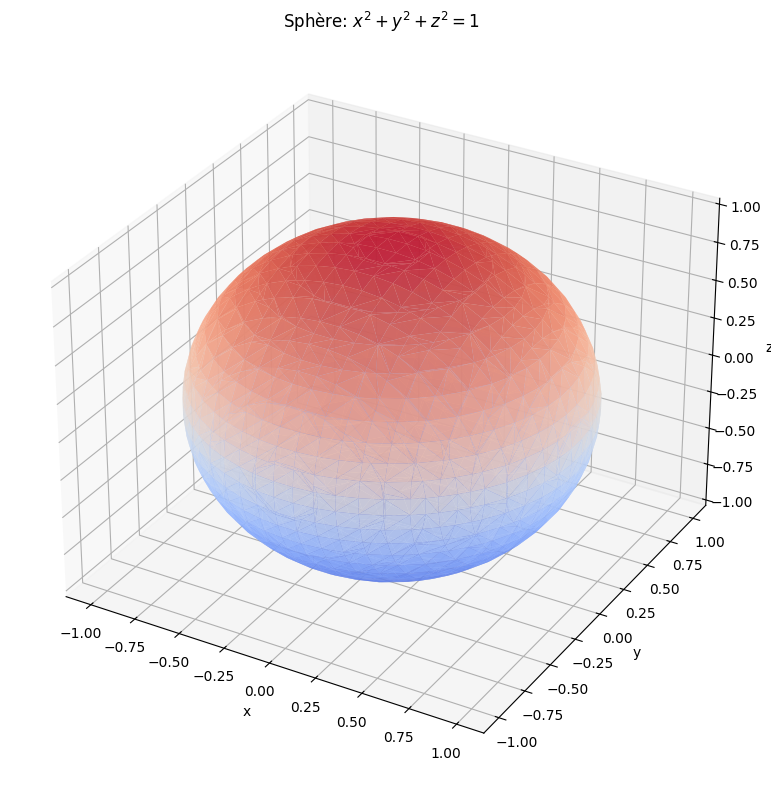

In [49]:
# Exemple 1 : Sphère
def sphere(x, y, z):
    return x**2 + y**2 + z**2 - 1

implicit_plot3d(sphere, 
                xrange=(-1.5, 1.5), 
                yrange=(-1.5, 1.5), 
                zrange=(-1.5, 1.5),
                resolution=30,
                cmap='coolwarm',
                title='Sphère: $x^2 + y^2 + z^2 = 1$')
plt.show()

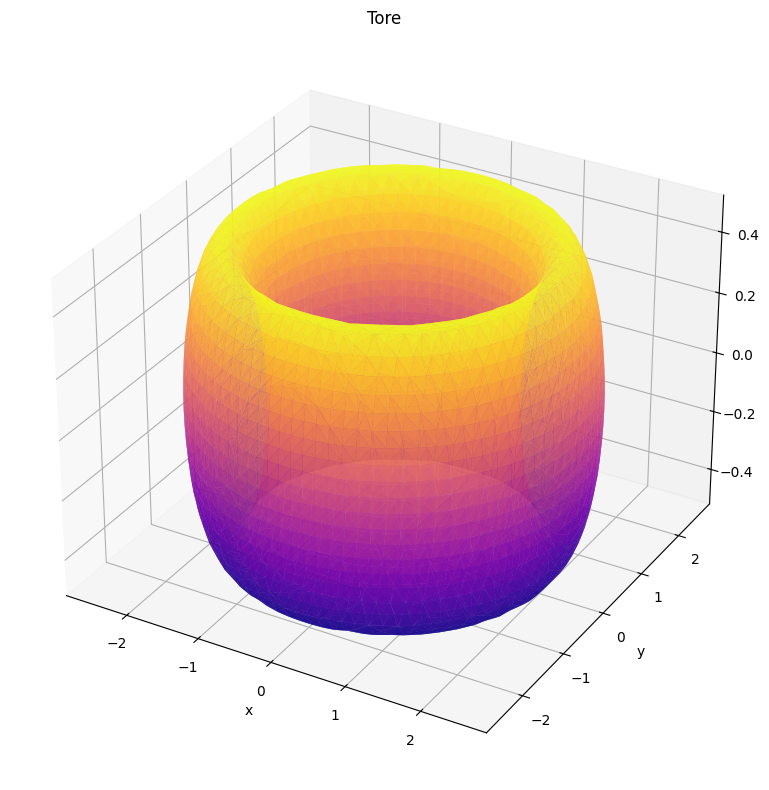

In [50]:
# Exemple 2 : Tore
def torus(x, y, z, R=2, r=0.5):
    """Tore avec grand rayon R et petit rayon r"""
    return (np.sqrt(x**2 + y**2) - R)**2 + z**2 - r**2

implicit_plot3d(torus, 
                xrange=(-3, 3), 
                yrange=(-3, 3), 
                zrange=(-1, 1),
                resolution=40,
                cmap='plasma',
                title='Tore')
plt.show()

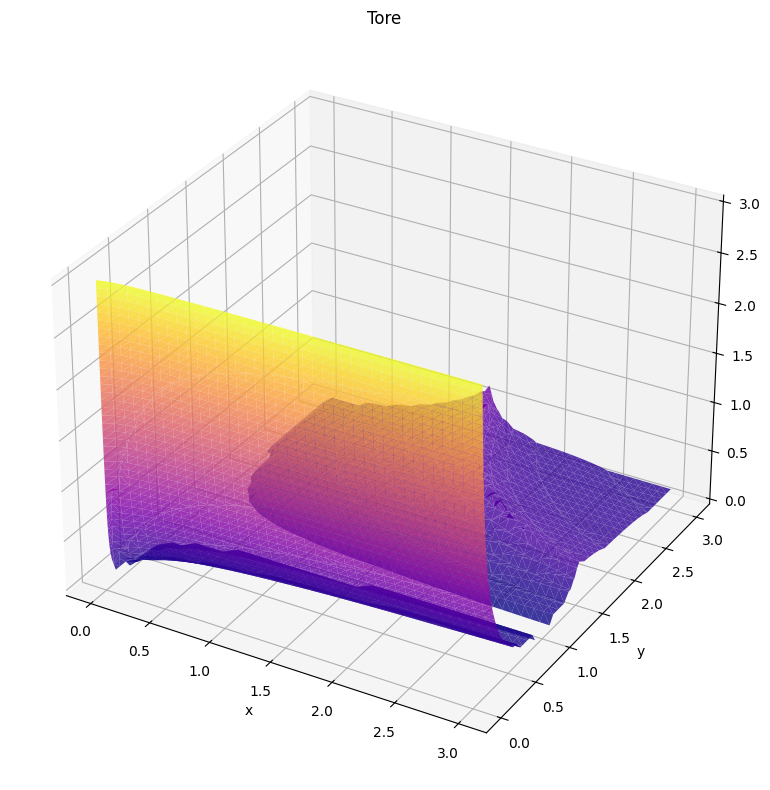

In [51]:
# Exemple 3 : discriminant cubique Delta_3 = 0
def Delta_3(A, B, C):
    return A**2 * (-4*A*(A*(B + C - 1)**2 - 3*C*(2*B - 1))**3
                   + (2*A**2*(B + C - 1)**3 - 9*A*C*(2*B - 1)*(B + C - 1) + 27*B*C**2)**2) / (2916 * C**6)
    
implicit_plot3d(Delta_3, 
                xrange=(0.01, 3), 
                yrange=(0.01, 3), 
                zrange=(0.01, 3),
                resolution=40,
                cmap='plasma',
                title='Tore')
plt.show()

In [52]:
from ipywidgets import FloatSlider, interact
import numpy as np

def compute_Delta(A, B, C):
    Delta = A**2*(-4*A*(A*(B + C - 1)**2 - 3*C*(2*B - 1))**3 + (2*A**2*(B + C - 1)**3 - 9*A*C*(2*B - 1)*(B + C - 1) + 27*B*C**2)**2)/(2916*C**6)
    return Delta
import matplotlib.pyplot as plt

def plot_Delta(A_val=1.0, C_val=1.0):
    A_num, C_num = A_val,  C_val
    # On trace Delta en fonction de B
    B_range = np.linspace(0, 10, 400)
    Delta_vals = [float(compute_Delta(A_num, b, C_num)) for b in B_range]
    plt.figure(figsize=(8,5))
    plt.plot(B_range, Delta_vals, label=r'$\Delta$')
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.xlabel('B')
    plt.ylabel(r'$\Delta$')
    plt.title(f"Discriminant Δ (A={A_num}, C={C_num})")
    plt.grid(True)
    plt.legend()
    plt.show()

interact(
    plot_Delta,
    A_val=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='A'),
    B_val=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='B '),
    C_val=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='C')
)

interactive(children=(FloatSlider(value=1.0, description='A', max=5.0, min=0.1), FloatSlider(value=1.0, descri…

<function __main__.plot_Delta(A_val=1.0, C_val=1.0)>

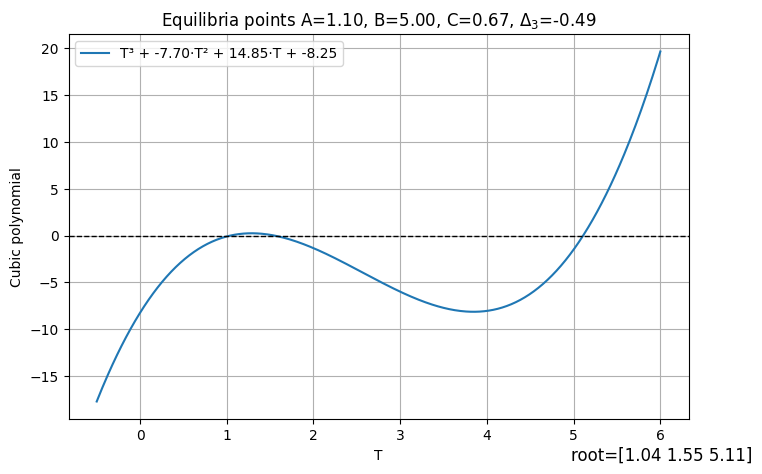

In [53]:
#pour A=1,B=10, C=1
plot_cubics(A=1.1, B=5, C=2/3)
plt.savefig('three_roots.png', format = 'png')

# Tracé de la zone où il y a trois racines dans le cas où l'une d'elle vaut 1.
l'équation du troisième degré se factorise en
$$
    (T^* - 1) \left( (T^*)^2 + \frac{1}{C} (B - 1) T^* + \frac{B}{C} \right) = 0
$$
le discriminant est positif ssi $\frac{(B-1)^2}{4B} > C$

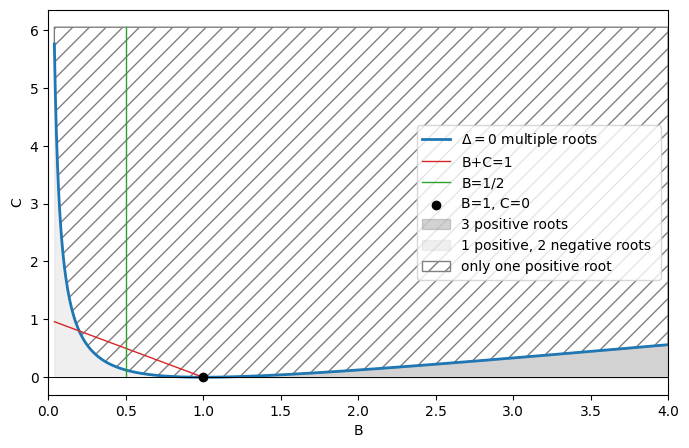

In [54]:
# Trace la courbe C = (B-1)**2/(4B) dans le plan (B, C)
# Utilise les imports déjà présents dans le notebook (np, plt)

# éviter B = 0 (division par zéro), tracer la branches  positive seulement
B_pos = np.linspace(0.04, 4, 600)

C_pos = (B_pos - 1)**2 / (4 * B_pos)
y_top = np.max(C_pos) * 1.05
plt.figure(figsize=(8,5))
# plt.plot(B_neg, C_neg, color='tab:orange', lw=2, label='branche B<0')
plt.plot(B_pos, C_pos, color='tab:blue', lw=2, label=r'$\Delta=0$ multiple roots' )
plt.plot(B_pos[B_pos<1],1-B_pos[B_pos<1], color='tab:red', lw=1, linestyle='-', label='B+C=1'  )
plt.plot(0.5*np.ones_like(B_pos), np.linspace(0, y_top, len(B_pos))   , color='tab:green', lw=1, linestyle='-', label='B=1/2'  )
# points et repères utiles
plt.scatter([1.0], [0.0], color='k', zorder=5, label='B=1, C=0')
plt.axhline(0, color='k', lw=0.7)
plt.axvline(0, color='k', lw=0.7, linestyle='--')

plt.xlabel('B')
plt.ylabel('C')
#plt.title(r'Courbe $C=\dfrac{(B-1)^2}{4B}$')
plt.xlim(0, 4)
# remplir la zone entre la courbe et l'axe des abscisses (B>0)
plt.fill_between(B_pos, C_pos, 0, where=(B_pos >= 1), color='grey', alpha=0.35, interpolate=True, label='3 positive roots')
plt.fill_between(B_pos, C_pos, 0, where=(B_pos < 1), color='lightgrey', alpha=0.35, interpolate=True, label='1 positive, 2 negative roots ')
y_top = np.max(C_pos) * 1.05
poly = plt.fill_between(B_pos, C_pos, y_top, where=(C_pos <= y_top),
                        facecolor='none', interpolate=True, label='only one positive root')
poly.set_edgecolor('gray')
poly.set_hatch('//')
plt.legend()
#plt.show()
plt.savefig('discriminant_curve.png', format = 'png')

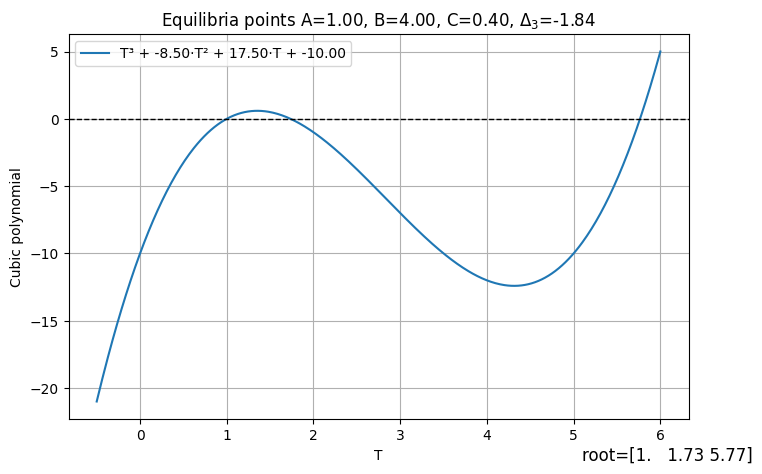

In [55]:
#pour A=1,B=4, C=0.1#pour A=1,B=4, C=0.1
plot_cubics(A=1, B=4, C=0.4)
plt.savefig('three_roots_A=1.png', format = 'png')#pour A=1,B=4, C=0.1

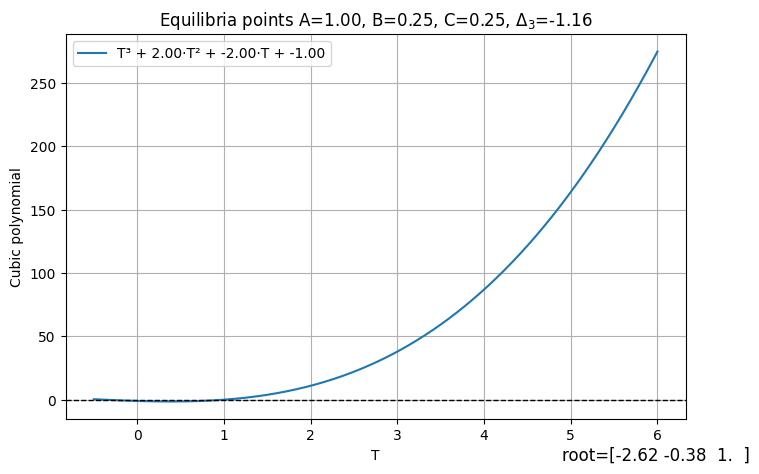

In [56]:
#pour A=1,B=1/4, C=1/4
plot_cubics(A=1, B=0.25, C=0.25)
plt.savefig('onepositive_twonegative_A=1.png', format = 'png')

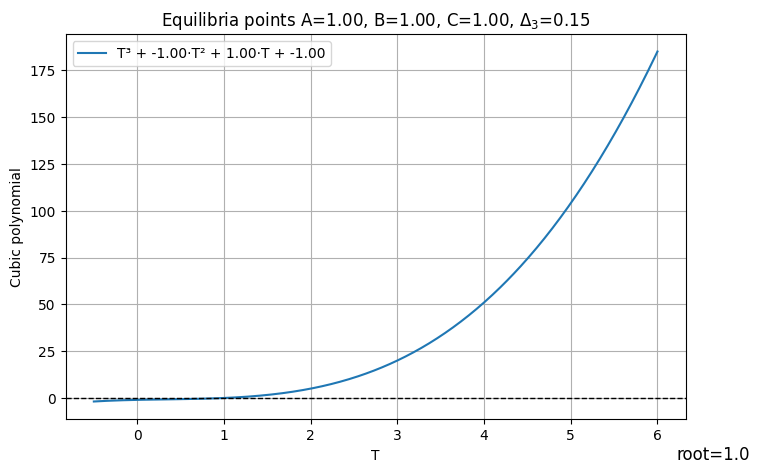

In [57]:
#pour A=1,B=1, C=1    
plot_cubics(A=1, B=1, C=1)
plt.savefig('onepositive_A=1.png', format = 'png')

### Stabilité des équilibres non triviaux.

Il s'agit de calculer les valeurs propres de la jacobienne aux points $(S^\star, N^\star, M^\star, T^\star)$.
$$
J = \begin{pmatrix}
aN^\star - bT^\star & aS^\star & 0 & -bS^\star \\
\alpha N^\star & \alpha S^\star - \delta_N (2N^\star-1) & 0 & 0 \\
\beta & 0 & -\delta_M (2M^\star-1) & 0 \\
-\gamma T^\star & 0 & \delta_M (1-T^\star) & -\gamma S^\star - \delta_M M^\star
\end{pmatrix}
$$
Pour cela on utilise les fonctions de Numpy.


In [58]:
# Calcul des valeurs propres de la jacobienne J (numérique et optionnellement symbolique)
# Utilise les imports et variables déjà présents dans le notebook (np, sp, params, y0, ...)

def J_matrix(S, N, M, T, alpha, beta, gamma, delta_N, delta_M, a, b):
    """
    Retourne la matrice Jacobienne 4x4 évaluée en (S,N,M,T) pour les paramètres donnés.
    Ordre des variables : (S, N, M, T)
    """
    J = np.zeros((4,4), dtype=float)
    J[0,0] = a * N - b * T
    J[0,1] = a * S
    J[0,2] = 0.0
    J[0,3] = -b * S

    J[1,0] = alpha * N
    J[1,1] = alpha * S - delta_N * (2.0 * N - 1.0)
    J[1,2] = 0.0
    J[1,3] = 0.0

    J[2,0] = beta
    J[2,1] = 0.0
    J[2,2] = -delta_M * (2.0 * M - 1.0)
    J[2,3] = 0.0

    J[3,0] = -gamma * T
    J[3,1] = 0.0
    J[3,2] = delta_M * (1.0 - T)
    J[3,3] = -gamma * S - delta_M * M

    return J

def eigenvalues_jacobian(S, N, M, T, alpha, beta, gamma, delta_N, delta_M, a, b):
    J = J_matrix(S, N, M, T, alpha, beta, gamma, delta_N, delta_M, a, b)
    eigs = np.linalg.eigvals(J)
    return J, eigs

# Optionnel: calcul symbolique de la jacobienne (utilise sympy si on veut expressions exactes)
def symbolic_jacobian(S_sym, N_sym, M_sym, T_sym, alpha_sym, beta_sym, gamma_sym, deltaN_sym, deltaM_sym, a_sym, b_sym):
    Js = sp.Matrix([
        [a_sym * N_sym - b_sym * T_sym,  a_sym * S_sym,                 0,                 -b_sym * S_sym],
        [alpha_sym * N_sym,             alpha_sym * S_sym - deltaN_sym*(2*N_sym-1), 0,  0],
        [beta_sym,                      0,                             -deltaM_sym*(2*M_sym-1), 0],
        [-gamma_sym * T_sym,            0,                             deltaM_sym*(1-T_sym), -gamma_sym*S_sym - deltaM_sym*M_sym]
    ])
    return Js, Js.eigenvects()

# Exemple d'utilisation numérique avec les variables existantes dans le notebook
# params = (alpha, beta, gamma, delta_N, delta_M, a, b)
alpha, beta, gamma, delta_N, delta_M, a, b = params
S0, N0, M0, T0 = y0  # utilise la condition initiale y0 déjà définie dans le notebook

J_num, eigs_num = eigenvalues_jacobian(S0, N0, M0, T0, alpha, beta, gamma, delta_N, delta_M, a, b)
print("Jacobian (numérique) en (S,N,M,T) =", (S0, N0, M0, T0))
print(J_num)
print("Valeurs propres (numériques) :", eigs_num)
print("Parties réelles :", np.real(eigs_num))

# Si vous préférez évaluer la jacobienne symboliquement en un point (ex: S=sp.Integer(0), ...),
# utilisez symbolic_jacobian et substituez les valeurs par .subs(...) sur la matrice retournée.

Jacobian (numérique) en (S,N,M,T) = (np.float64(0.2828069625764096), np.float64(0.1201965612131689), np.float64(0.29614019752214493), np.float64(0.11872771895424405))
[[-0.07665892  0.09898244  0.         -0.28280696]
 [ 0.12019656  1.04241384  0.          0.        ]
 [ 1.          0.          0.4077196   0.        ]
 [-0.11872772  0.          0.88127228 -0.57894716]]
Valeurs propres (numériques) : [-0.86962802+0.j          0.30644759+0.42682204j  0.30644759-0.42682204j
  1.0512602 +0.j        ]
Parties réelles : [-0.86962802  0.30644759  0.30644759  1.0512602 ]


Let us take an example with $A=1$ and 3 equilibria, one of them being the trivial equilibrium $T=1$.
Specifically we ensure $\Delta = \frac{(B-1)^2 - 4 B C }{C^2} >0$.
We take $A=1, B=4, C=0.40$,
$a=b$, $\beta = 4\gamma$,
$\gamma \delta_N = 0.4\,\alpha \delta_M.$

Remarque: on pourrait peut-être conjuguer la matrice jacobienne sans changer le signe de ses valeurs propres et en ne faisant apparaître que les paramètres principaux $A,B,C$.
$$
J = \begin{pmatrix}
aN^\star - bT^\star & aS^\star & 0 & -bS^\star \\
\alpha N^\star & \alpha S^\star - \delta_N (2N^\star-1) & 0 & 0 \\
\beta & 0 & -\delta_M (2M^\star-1) & 0 \\
-\gamma T^\star & 0 & \delta_M (1-T^\star) & -\gamma S^\star - \delta_M M^\star
\end{pmatrix}
$$
Pour le moment on se contente de calculer un cas particulier:
$a=b=1$, $\beta = 4$, $\gamma=1$,
$\alpha = 1$, $\delta_N = 0.4$
$\delta_M = 1$

    


In [59]:
alpha, beta, gamma, delta_N, delta_M, a, b = (1, 4, 1, 0.4, 1, 1, 1)   # alpha, beta, gamma, delta_N, delta_M, a, b
A = a/b
B = beta/gamma
C = gamma*delta_N/(alpha*delta_M)
discrim_2 = ((B-1)**2 - 4*B*C)/C**2
T1 = ((B-1)/C - np.sqrt(discrim_2))/2 
T2 = ((B-1)/C + np.sqrt(discrim_2))/2
print(f"Pour a/b={A}, beta/gamma={B}, gamma*delta_N/(alpha*delta_M)={C}:")
print(f"Discriminant 2D: {discrim_2}")
print(f"Racines T*: {T1}, {T2}") 


Pour a/b=1.0, beta/gamma=4.0, gamma*delta_N/(alpha*delta_M)=0.4:
Discriminant 2D: 16.249999999999993
Racines T*: 1.7344355629253632, 5.765564437074637


In [60]:
N1= T1/A
S1= delta_N/alpha * (N1-1)
M1 = 1+ beta/gamma *(1-T1)/T1
print(f"Point d'équilibre 1: S*={S1}, N*={N1}, M*={M1}, T*={T1}")
N2= T2/A
S2= delta_N/alpha * (N2-1)
M2 = 1+ beta/gamma *(1-T2)/T2
print(f"Point d'équilibre 2: S*={S2}, N*={N2}, M*={M2}, T*={T2}")

Point d'équilibre 1: S*=0.2937742251701453, N*=1.7344355629253632, M*=-0.6937742251701458, T*=1.7344355629253632
Point d'équilibre 2: S*=1.906225774829855, N*=5.765564437074637, M*=-2.306225774829855, T*=5.765564437074637


Aucun des deux points d'équilibres ne convient car $M<0$.
Il y a une condition sur le point d'équilibre $T$ pour que $M>0$.
Il faut aussi assurer que $S>0, N>0, M>0$ *pas seulement* $T>0$

Caractérisons l'ensemble des paramètres $A,B,C$ tels qu'il y ait d'autres points d'équilibres admissibles que $(0,1,1,1)$. Le cas $A=1$ a déjà été traité. Il n'y en a pas d'autres dans ce cas. Dans le cas  $A\neq 1$, la question se pose de savoir s'il existe d'autres points d'équilibres. Lorsque   $S=0$ il y en a un seul qui est stable : $S,N,M,T = (0,1,1,1)$. Lorsque $S\neq 0$, nous devons nous assurer que les points d'equilibres possibles sont admissible.
Pour cela si $B\geq 1$ (resp. $B <1$ )il faut et il suffit que $ A \leq T^\star \leq \frac{B}{B-1}$ ( resp.$  A \leq T^\star$ )


In [61]:
#ecriture d'un test de faisabilité des points d'équilibre en fonction des paramètres
#en fonction de A, B, C et du discriminant $\Delta_3$
def test_feasibility(A, B, C):
        
        p = A *  (1 - B - C) / C  # Coefficient for T^2
        # Calculate the discriminant
        s = A * (-A * (B + C - 1)**2 + 3 * C * (2 * B - 1)) / (3 * C**2)
        t = A * (-2 * A**2 * (B + C - 1)**3 + 9 * A * C * (2 * B - 1) * (B + C - 1) - 27 * B * C**2) / (27 * C**3)
        Delta = (t / 2)**2 + (s / 3)**3
    
        # Calculate roots based on the sign of the discriminant
        if Delta > 0:
            T = np.cbrt(-t / 2 + np.sqrt(Delta)) + np.cbrt(-t / 2 - np.sqrt(Delta)) - p / 3
            # do not forget to adjust root by -p/3 to get roots of original cubic
        elif Delta < 0:
            # guard against numerical issues in the arccos argument
            arg = 3 * np.sqrt(3) * t / (2 * s * np.sqrt(-s))
            arg = np.clip(arg, -1.0, 1.0)
            theta = np.arccos(arg)
            T = [2 * np.sqrt(-s / 3) * np.cos((theta + 2 * k * np.pi) / 3) - p / 3 for k in range(3)]
            # do not forget to adjust roots by -p/3 to get roots of original cubic
        else:  # Delta == 0
            T = [-2 * np.cbrt(t / 2) - p / 3, np.cbrt(t / 2) - p / 3]  # one multiple root
    
        # Test feasibility conditions on roots T and give the number of feasible roots
        if isinstance(T, list):
            T_arr = np.asarray(T, dtype=float)
            if B <= 1:
                return int(np.count_nonzero(T_arr > A))
            else:  # B > 1
                cond = (T_arr > A) & (T_arr < B / (B - 1))
                return int(np.count_nonzero(cond))
        else:
            T_val = float(T)
            if B <= 1:
                return int(T_val > A)
            else:
                return int((T_val > A) and (T_val < B / (B - 1)))

In [62]:
test_feasibility(A=0.99, B=0.4, C=0.5)

1

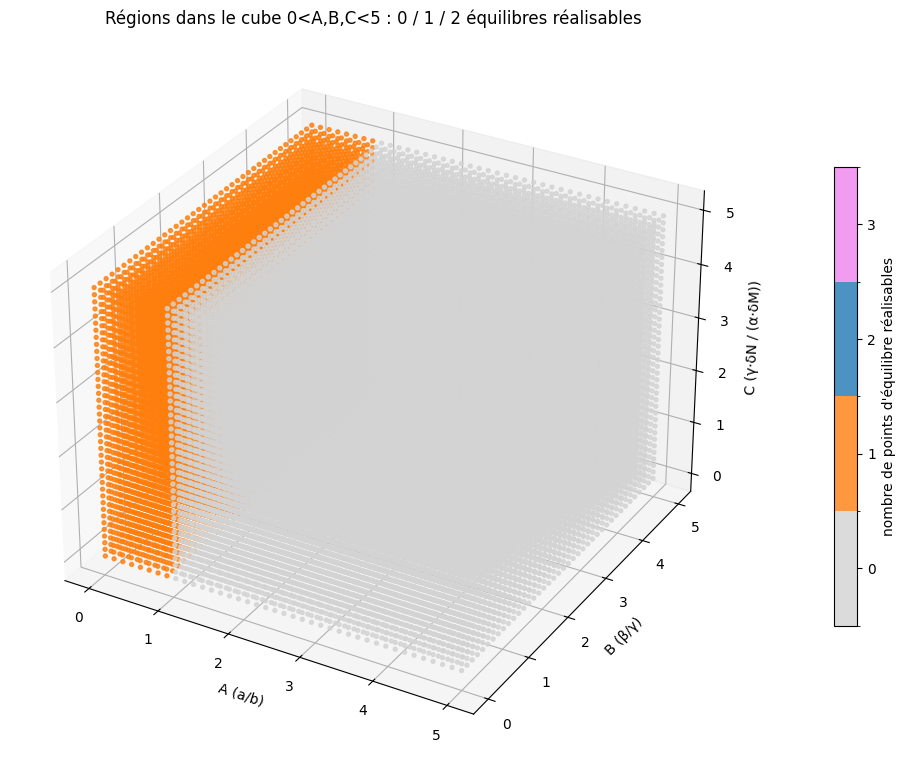

In [63]:
# trace dans un cube 0 < A,B,C < 3 la fonction test_feasibility 
# et colorie les régions en fonction du nombre de points d'équilibre réalisables (0, 1 ou 3)
# grille et calcul de faisabilité dans le cube 0<A,B,C<3
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt

res = 40
A_range = np.linspace(0.01, 4.99, res)
B_range = np.linspace(0.01, 4.99, res)
C_range = np.linspace(0.01, 4.99, res)

AA, BB, CC = np.meshgrid(A_range, B_range, C_range, indexing='ij')


# vectorisation de la fonction scalaire test_feasibility
vec_test = np.vectorize(lambda a, b, c: test_feasibility(a, b, c), otypes=[int])
counts = vec_test(AA, BB, CC)   # shape (res, res, res)

# projection en nuage 3D colorié par nombre de points d'équilibre réalisables
A_flat = AA.ravel()
B_flat = BB.ravel()
C_flat = CC.ravel()
counts_flat = counts.ravel()


cmap = ListedColormap(['lightgrey', 'tab:orange', 'tab:blue', 'violet'])
norm = BoundaryNorm([ -0.5, 0.5, 1.5, 2.5, 3.5 ], cmap.N)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(A_flat, B_flat, C_flat, c=counts_flat, cmap=cmap, norm=norm, s=8, alpha=0.8)
cbar = fig.colorbar(p, ticks=[0,1,2,3,4], shrink=0.6, pad=0.1)
cbar.set_label("nombre de points d'équilibre réalisables")
ax.set_xlabel('A (a/b)')
ax.set_ylabel('B (β/γ)')
ax.set_zlabel('C (γ·δN / (α·δM))')
ax.set_title("Régions dans le cube 0<A,B,C<5 : 0 / 1 / 2 équilibres réalisables")
plt.tight_layout()
plt.savefig('feasibility_regions_3D.png', format = 'png')   
plt.show()


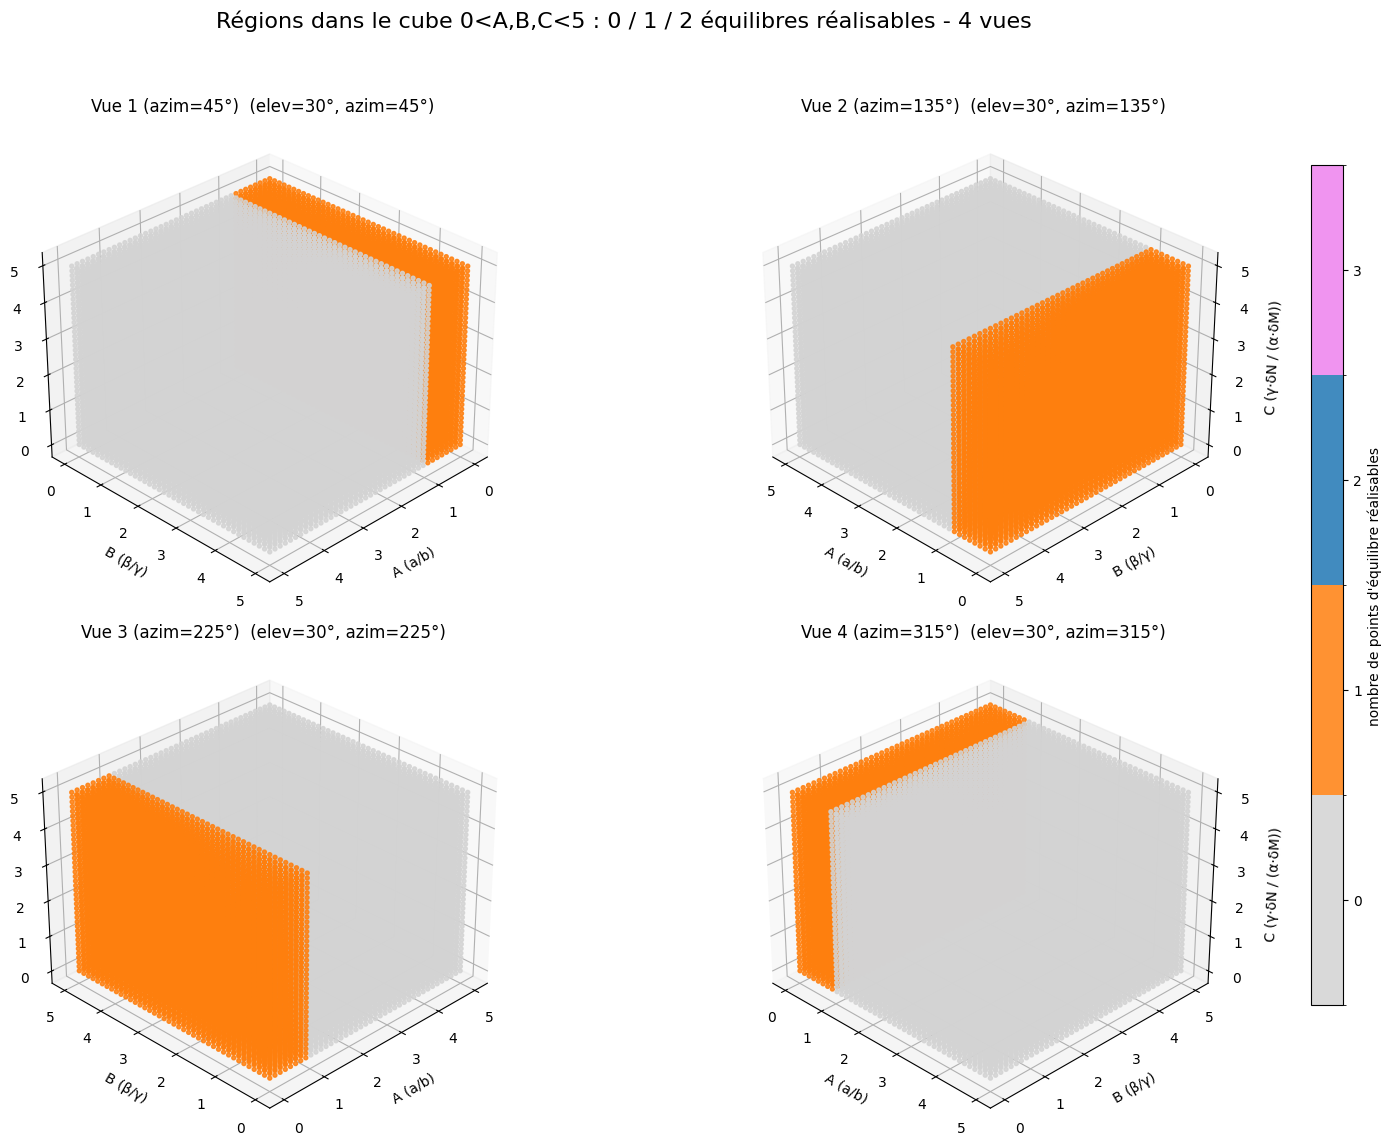

In [64]:
# 4 vues différentes du nuage 3D déjà calculé (utilise A_flat, B_flat, C_flat, counts_flat, cmap, norm)
fig = plt.figure(figsize=(16, 12))
angles = [(30, 45), (30, 135), (30, 225), (30, 315)]
titles = ['Vue 1 (azim=45°)', 'Vue 2 (azim=135°)', 'Vue 3 (azim=225°)', 'Vue 4 (azim=315°)']

for i, ((elev, azim), ttl) in enumerate(zip(angles, titles), start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    sc = ax.scatter(A_flat, B_flat, C_flat, c=counts_flat, cmap=cmap, norm=norm, s=8, alpha=0.85)
    ax.set_xlabel('A (a/b)')
    ax.set_ylabel('B (β/γ)')
    ax.set_zlabel('C (γ·δN / (α·δM))')
    ax.set_title(f"{ttl}  (elev={elev}°, azim={azim}°)")
    ax.view_init(elev=elev, azim=azim)
    ax.grid(True)

# colorbar unique
#cbar = fig.colorbar(sc, ax=fig.get_axes(), shrink=0.6, pad=0.05)
#cbar.set_ticks([0,1,2])
#cbar.set_label("nombre de points d'équilibre réalisables")

plt.suptitle("Régions dans le cube 0<A,B,C<5 : 0 / 1 / 2 équilibres réalisables - 4 vues", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# optionnel : sauvegarder
#plt.savefig('regions_4views.png', dpi=150, bbox_inches='tight')
# reposition the colorbar to the right so it doesn't sit over the subplots
# create a new narrow axis on the right for the colorbar
cax = fig.add_axes([0.93, 0.15, 0.02, 0.7])  # [left, bottom, width, height] in figure coords
cb = fig.colorbar(sc, cax=cax, ticks=[0, 1, 2,3])
cb.set_label("nombre de points d'équilibre réalisables")

plt.show()

In [65]:
test_feasibility(A=0.99, B=2, C=2)

1

Il semble que seule la valeur de $A$ importe. On conjecture que si $A\geq 1$ il n'y a pas d'autre équilibre que l'équilibre "disease-free".
Il y a une bifurcation donc pour $A=1$.
Etudions la stabilité de l'équilibre pour $A<1$

In [66]:
def feasible_equilibria(A, B, C):
    
    #calcul  de l'équilibre lorsque test_feasibility renvoie 1

    p = A *  (1 - B - C) /C # Coefficient for T^2
    # Calculate the discriminant
    s = A*(-A*(B + C - 1)**2 + 3*C*(2*B - 1))/(3*C**2)
    t = A*(-2*A**2*(B + C - 1)**3 + 9*A*C*(2*B - 1)*(B + C - 1) - 27*B*C**2)/(27*C**3)
    Delta = (t/2)**2 + (s/3)**3
    # Calculate roots based on the sign of the discriminant
    if Delta > 0:
        T = np.cbrt(-t/2 + np.sqrt(Delta)) + np.cbrt(-t/2 - np.sqrt(Delta)) - p/3
    # do not forget to adjust root by -p/3 to get roots of original cubic
    elif Delta < 0:
        theta = np.arccos(3*np.sqrt(3)*t/ (2*s*np.sqrt(-s)))
        T = [2 * np.sqrt(-s/3) * np.cos((theta + 2 * k * np.pi)/3) - p/3 for k in range(3)]
    # do not forget to adjust roots by -p/3 to get roots of original cubic          
    else:  # Delta == 0
            T = [- 2 * np.cbrt(t/2) - p/3, np.cbrt(t/2) - p/3 ] # one multiple root

    # Test feasibility conditions on roots T
    # and give the number of feasible roots
    if B <= 1:
        feasible_T = [t for t in (T if isinstance(T, list) else [T]) if t > A]
    else:  # B > 1  
        feasible_T = [t for t in (T if isinstance(T, list) else [T]) if (t > A) and (t < B / (B - 1))]

    
    if len(feasible_T) == 0:
        print("Aucun point d'équilibre réalisable pour ces paramètres.")
        return None 
    S=[]
    N=[]
    M=[]
    for i in range(len(feasible_T)):
        print("Racines T* réalisables :", np.round(feasible_T[i], 5))
        S.append(delta_N/alpha * (feasible_T[i]/A - 1))
        N.append(feasible_T[i]/A)
        M.append(1 + B * (1 - feasible_T[i]) / feasible_T[i])
    print(f"Point d'équilibre réalisable: S*={S[i]}, N*={N[i]}, M*={M[i]}, T*={feasible_T[i]}")
    print(f"Nombre de points d'équilibre réalisables: {len(feasible_T)}")
    return S, N, M, feasible_T

In [67]:
S,N,M,T = feasible_equilibria(A=0.75, B=0.5, C=1)


Racines T* réalisables : 0.87021
Point d'équilibre réalisable: S*=0.06411021449189987, N*=1.1602755362297497, M*=1.0745761638937616, T*=0.8702066521723122
Nombre de points d'équilibre réalisables: 1


In [68]:
def stable_equilibria(alpha, beta, gamma, delta_N, delta_M, a, b):
    """
    Teste la stabilité des points d'équilibre réalisables pour les paramètres A, B, C donnés.
    Affiche les résultats.
    """
#testons la stabilité des points d'équilibre réalisables
#lorsque $S \neq 0$,
# a partir des valeurs de A,B,C trouvons les paramètres numériques correspondants
# rappel des définitions:
    A = a/b
    B = beta/gamma        
    C = gamma*delta_N/(alpha*delta_M)
    if test_feasibility(A, B, C) == 0:
        print("Aucun point d'équilibre réalisable pour ces paramètres.")
    else:
        S,N,M,T = feasible_equilibria(A, B, C)
        print("Paramètres numériques correspondants:")
        print(f"alpha={alpha}, beta={beta}, gamma={gamma}, delta_N={delta_N}, delta_M={delta_M}, a={a}, b={b}")
        print("Calcul de la matrice Jacobienne et des valeurs propres en chaque point d'équilibre réalisable:")
    for i in range(len(T)):
        print(f"\nPoint d'équilibre réalisable {i+1}: S*={S[i]}, N*={N[i]}, M*={M[i]}, T*={T[i]}")
        J_num, eigs_num = eigenvalues_jacobian(S[i], N[i], M[i], T[i], alpha, beta, gamma, delta_N, delta_M, a, b)
        print("Jacobian (numérique) :")
        print(J_num)
        print("Valeurs propres (numériques) :", eigs_num)
        print("Parties réelles :", np.real(eigs_num))
        if all(np.real(eigs_num) < 0):
            print("Le point d'équilibre est stable (toutes les parties réelles des valeurs propres sont négatives).")
        else:
            print("Le point d'équilibre est instable (au moins une partie réelle des valeurs propres est positive).")   

In [69]:
# choisissons b=1, delta_M=1 delta_N=1 pour simplifier le calcul des paramètres
A,B,C = 0.75, 0.5, 1
# en déduire les paramètres numériques
alpha, beta, gamma, delta_N, delta_M, a, b = (1/C, B , 1, 1, 1, A,1)
stable_equilibria(alpha, beta, gamma, delta_N, delta_M, a, b)



Racines T* réalisables : 0.87021
Point d'équilibre réalisable: S*=0.16027553622974966, N*=1.1602755362297497, M*=1.0745761638937616, T*=0.8702066521723122
Nombre de points d'équilibre réalisables: 1
Paramètres numériques correspondants:
alpha=1.0, beta=0.5, gamma=1, delta_N=1, delta_M=1, a=0.75, b=1
Calcul de la matrice Jacobienne et des valeurs propres en chaque point d'équilibre réalisable:

Point d'équilibre réalisable 1: S*=0.16027553622974966, N*=1.1602755362297497, M*=1.0745761638937616, T*=0.8702066521723122
Jacobian (numérique) :
[[ 0.          0.12020665  0.         -0.16027554]
 [ 1.16027554 -1.16027554  0.          0.        ]
 [ 0.5         0.         -1.14915233  0.        ]
 [-0.87020665  0.          0.12979335 -1.2348517 ]]
Valeurs propres (numériques) : [ 0.19503759 -1.42898094 -1.1737093  -1.13662691]
Parties réelles : [ 0.19503759 -1.42898094 -1.1737093  -1.13662691]
Le point d'équilibre est instable (au moins une partie réelle des valeurs propres est positive).


Simulons une trajectoire partant au voisinage du point fixe instable précédent
S*=0.16027553622974966, N*=1.1602755362297497, M*=1.0745761638937616, T*=0.8702066521723122
avec les paramètres alpha=1.0, beta=0.5, gamma=1, delta_N=1, delta_M=1, a=0.75, b=1



valeurs finales: Signal=0.149, Neutrophiles=1.151, Momac=1.070, SL-TRM=0.877


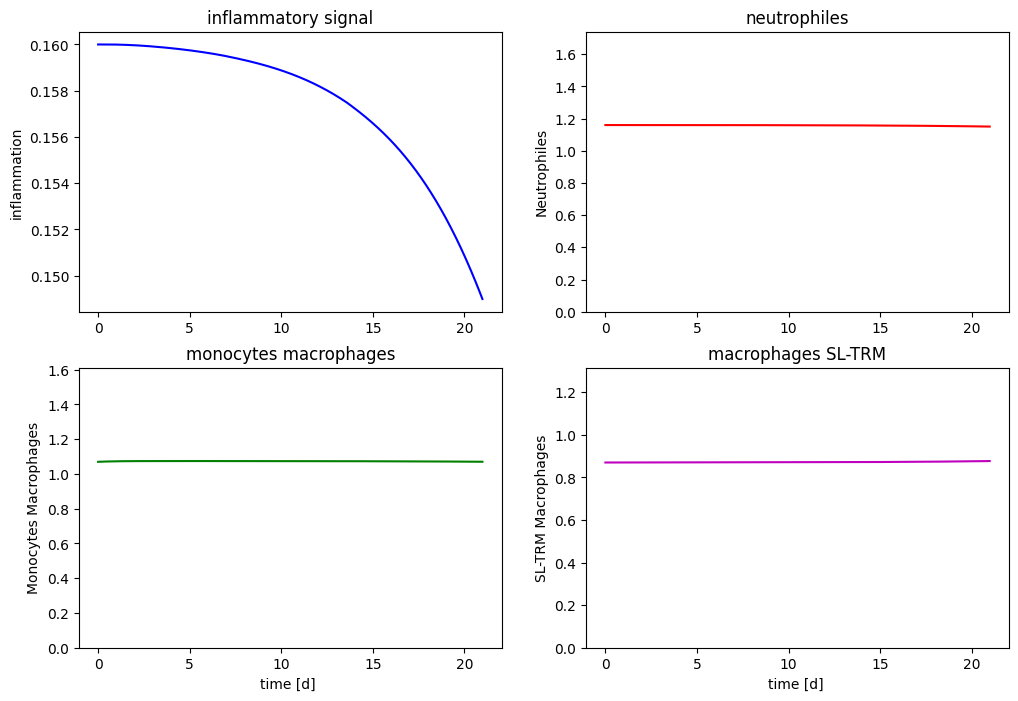

In [70]:
inflam_adim_oliv([0.16, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=21)


Il semble que la trajectoire soit attirée par le point fixe homéostasique $(0,1,1,1)$
Cependant si on double la dose de sérum immun, le scénario est différent:

valeurs finales: Signal=857.395, Neutrophiles=490.962, Momac=5.953, SL-TRM=0.010


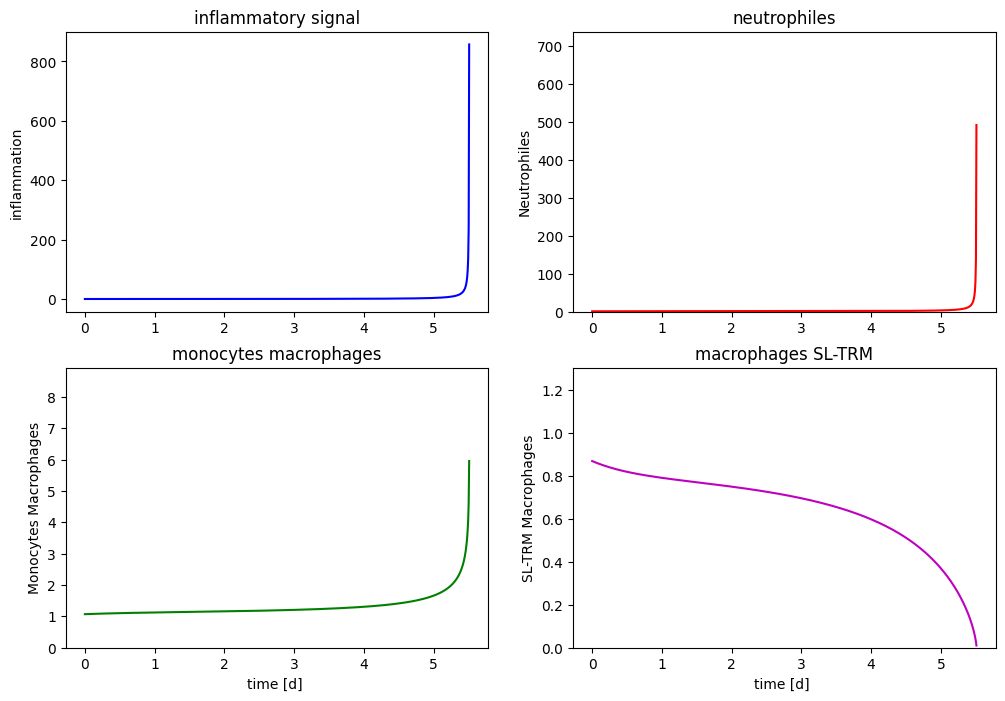

In [71]:
inflam_adim_oliv([0.32, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=7)


On peut aussi augmenter le pouvoir anti-inflammatoire des macrophages SL-TRM

valeurs finales: Signal=0.070, Neutrophiles=1.093, Momac=1.045, SL-TRM=0.920


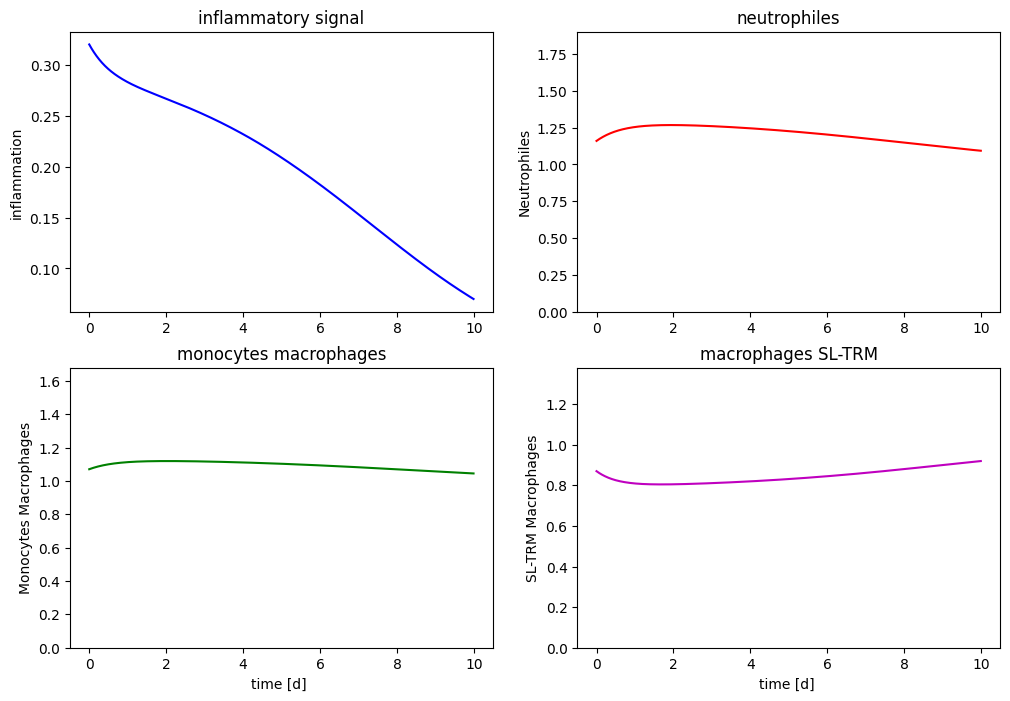

In [72]:
inflam_adim_oliv([0.32, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1.25, duree=10)


ou diminuer la rétro-action inflammatoire des neutrophiles

valeurs finales: Signal=0.044, Neutrophiles=1.066, Momac=1.032, SL-TRM=0.942


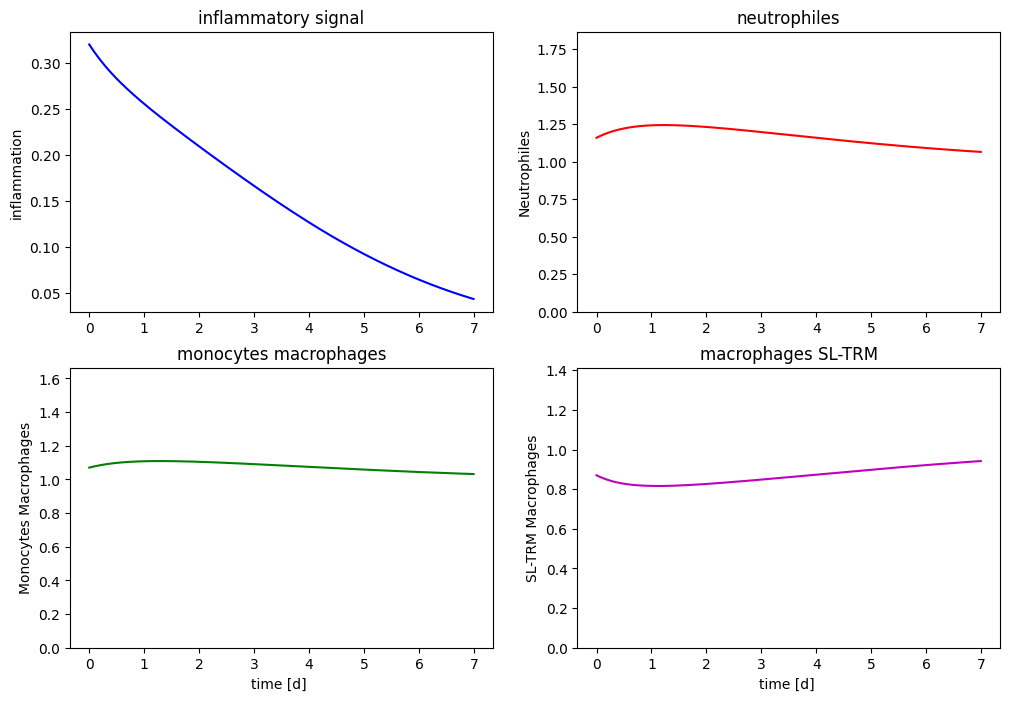

In [73]:
inflam_adim_oliv([0.32, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.5, b=1, duree=7)


Racines T* réalisables : 0.87021
Point d'équilibre réalisable: S*=0.16027553622974966, N*=1.1602755362297497, M*=1.0745761638937616, T*=0.8702066521723122
Nombre de points d'équilibre réalisables: 1
valeurs finales: Signal=0.160, Neutrophiles=1.160, Momac=1.075, SL-TRM=0.870


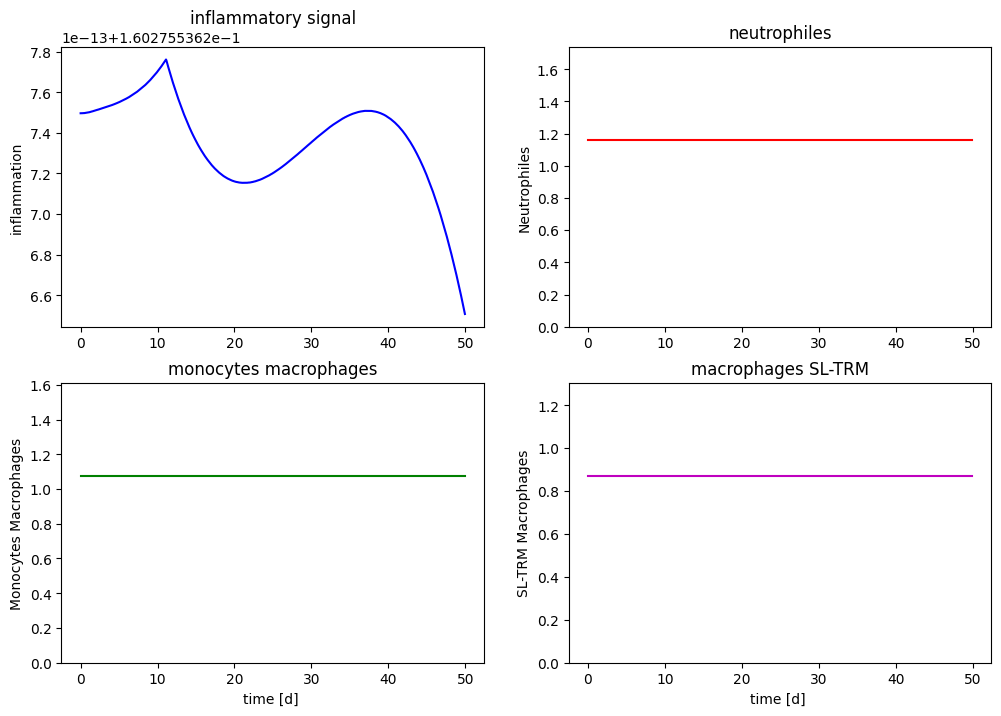

In [74]:
S,N,M,T = feasible_equilibria(A=0.75, B=0.5, C=1)
inflam_adim_oliv([S[0], N[0], M[0], T[0]],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=50)


valeurs finales: Signal=2.917, Neutrophiles=2.894, Momac=1.561, SL-TRM=0.419


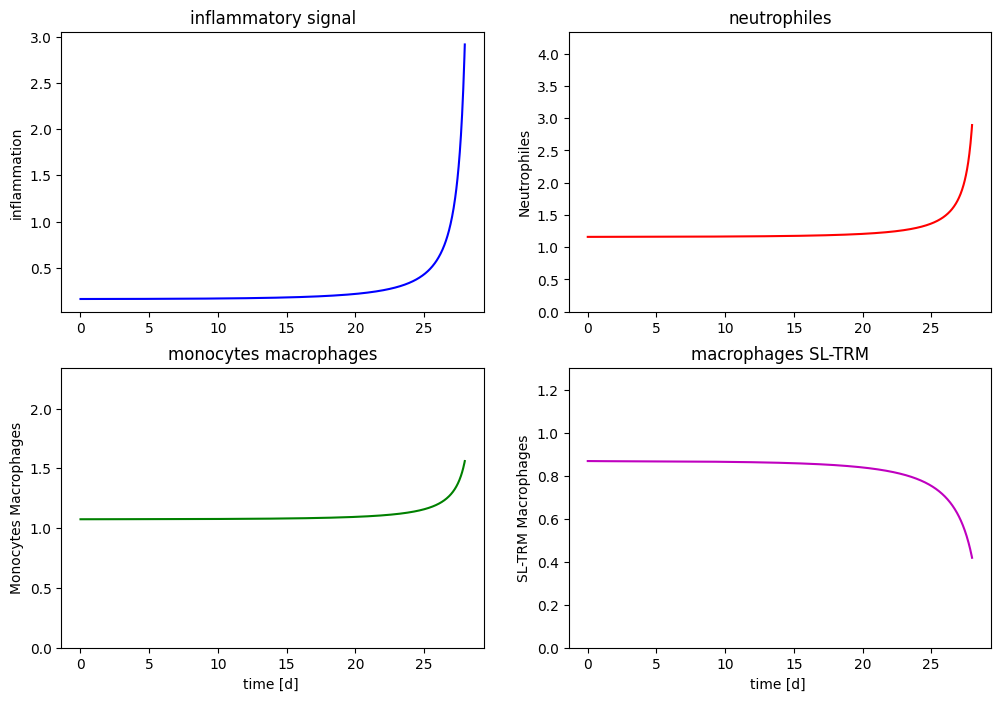

In [75]:
inflam_adim_oliv([S[0]+1e-3, N[0], M[0], T[0]],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=28)

On constate que la crise d'arthrite s'emballe dans ce cas.

valeurs finales: Signal=0.064, Neutrophiles=1.072, Momac=1.035, SL-TRM=0.936


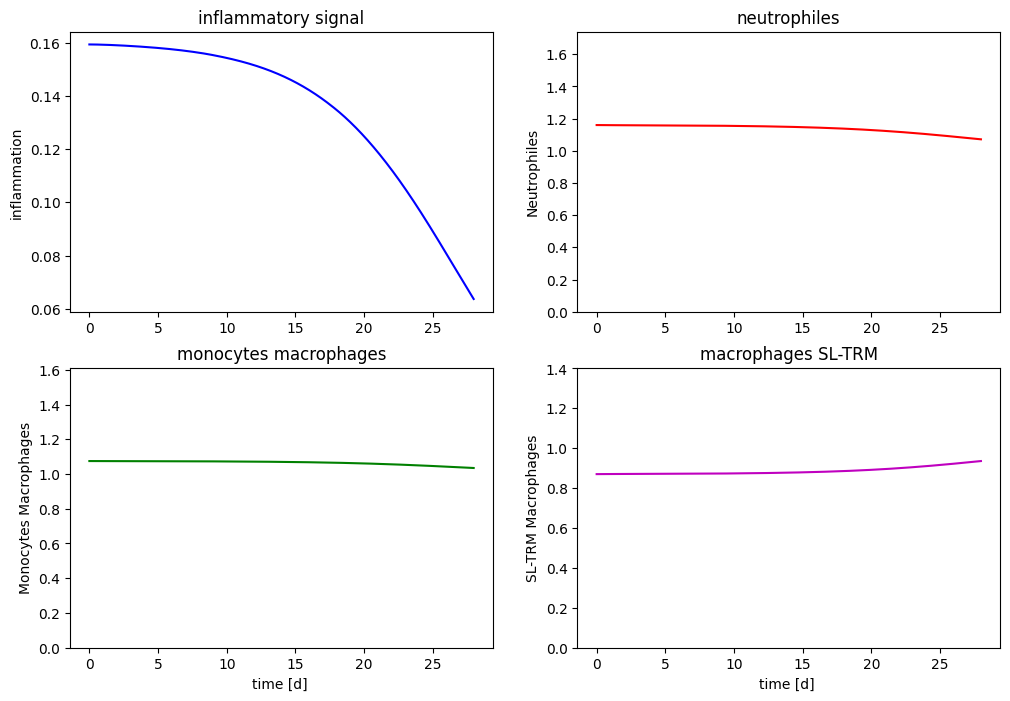

In [76]:
inflam_adim_oliv([S[0]-1e-3, N[0], M[0], T[0]],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=28)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


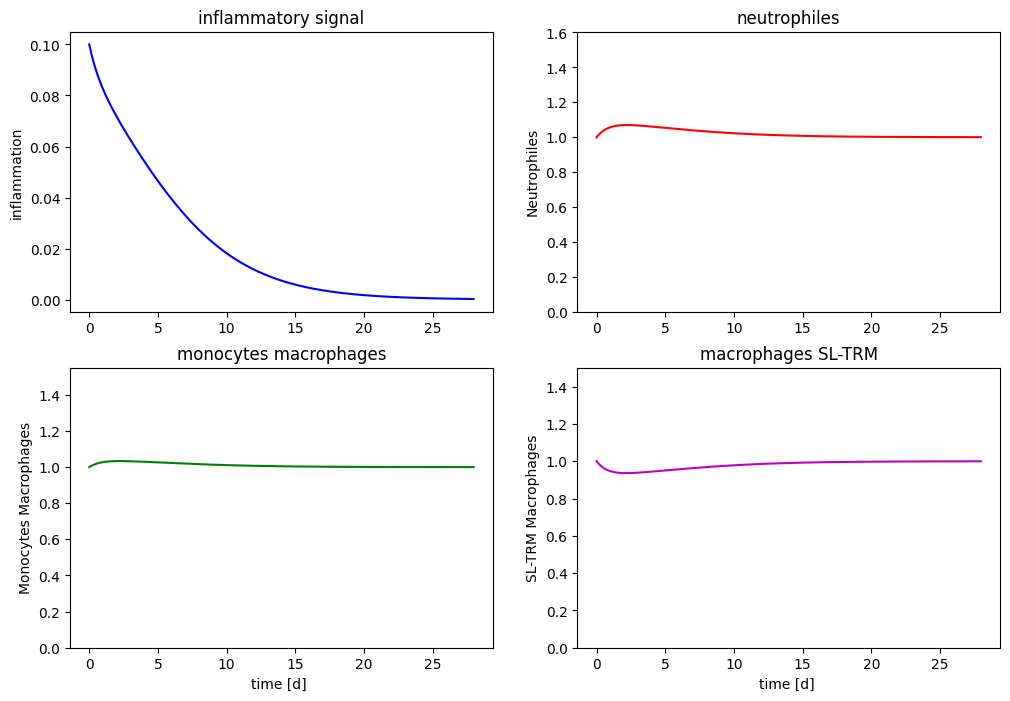

In [77]:
inflam_adim_oliv([0.1, 1-1e-3, 1, 1+1e-3],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=28)

valeurs finales: Signal=2.917, Neutrophiles=2.894, Momac=1.561, SL-TRM=0.419


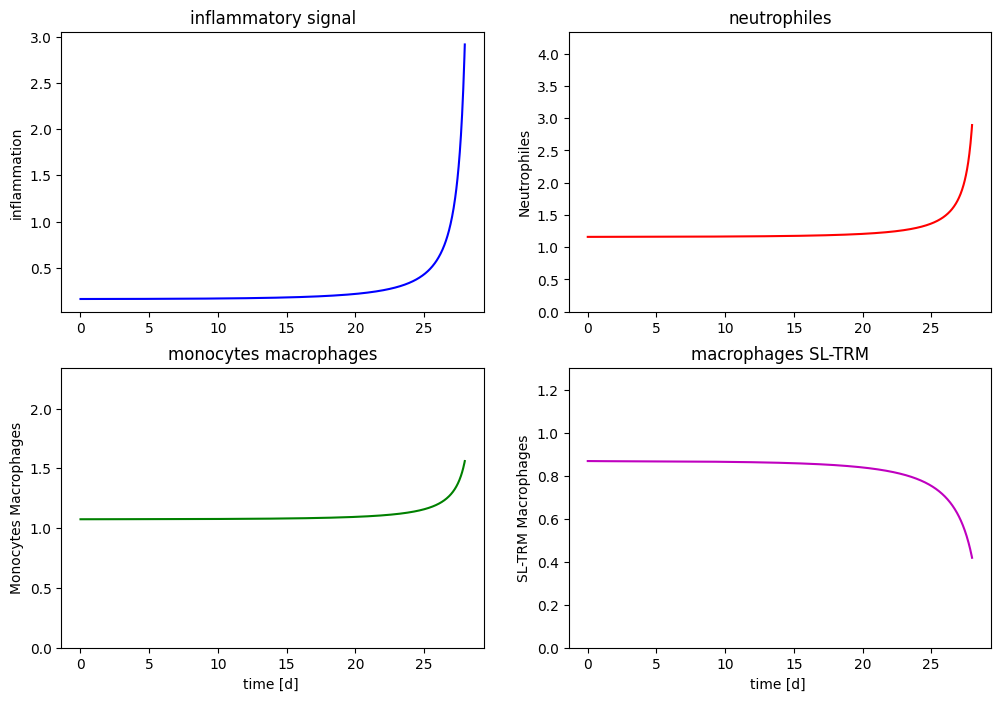

In [78]:
inflam_adim_oliv([S[0]+1e-3, N[0], M[0], T[0]],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=28)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


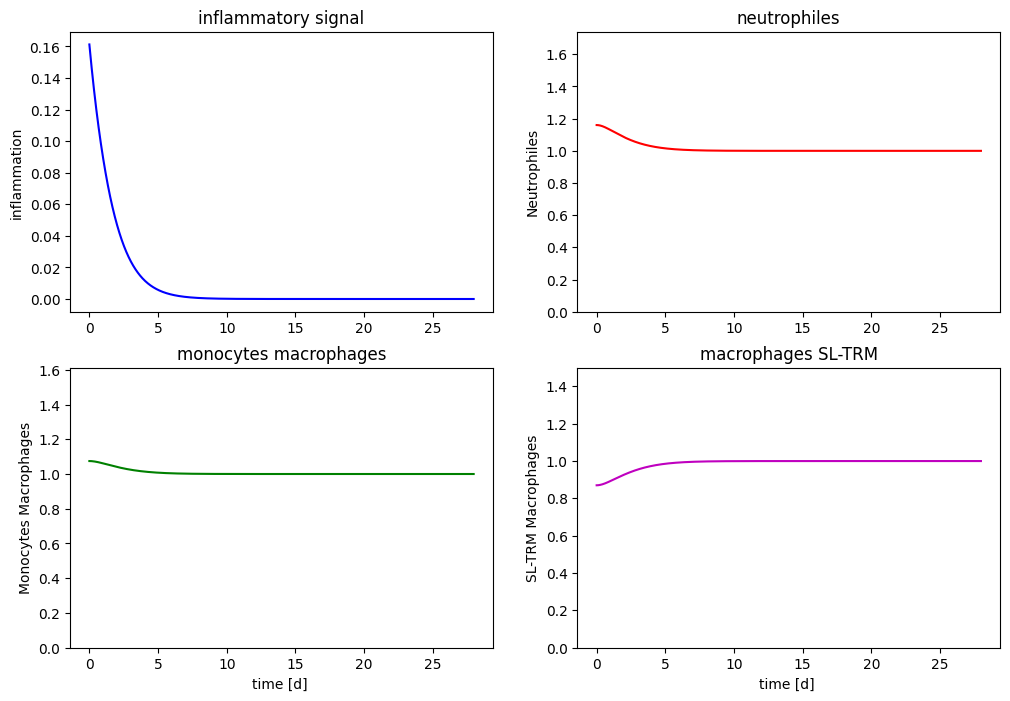

In [79]:
inflam_adim_oliv([S[0]+1e-3, N[0], M[0], T[0]],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.25, b=1, duree=28)

on remarque que la valeur de $a$ est critique pour la résolution de la crise. Si $a$ décroît l'équilibre homéostasique est de plus en plus attractif.

La question se pose : y a-t-il des points d'équilibres stables avec $S\neq 0$?


Pour résumer si $a>b$ i.e. $A>1$ il y a un seul point d'equilibre, c'est l'état homéostasique mais il est instable

valeurs finales: Signal=2.961, Neutrophiles=2.613, Momac=1.498, SL-TRM=0.439


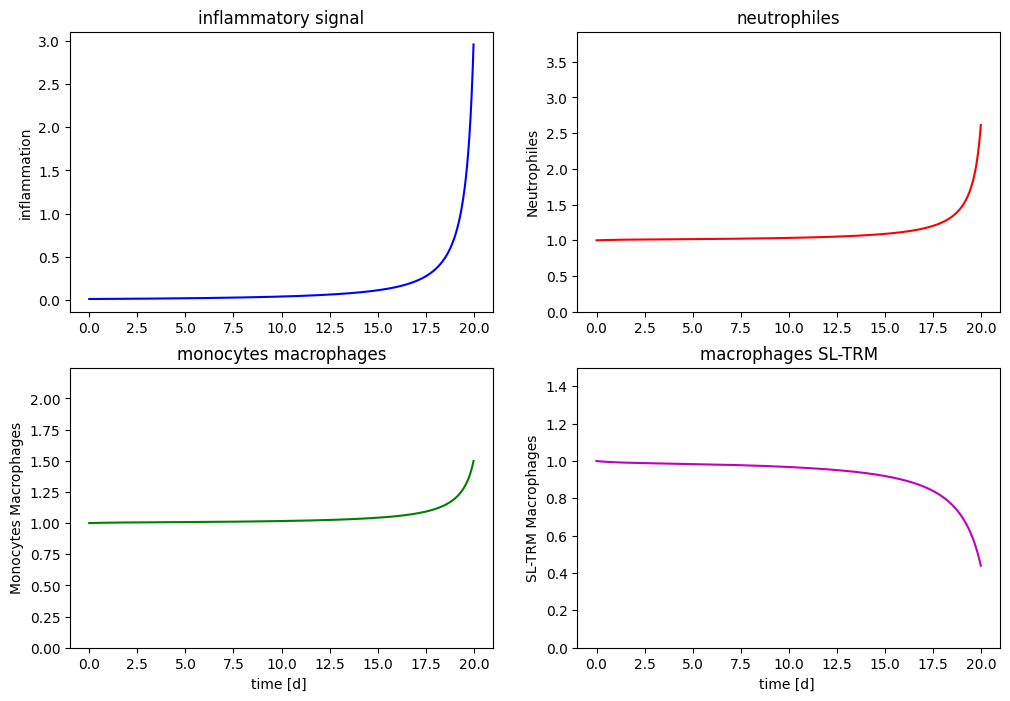

In [80]:
inflam_adim_oliv([0.01, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=1.1, b=1, duree=20)

Pour $a<b$ i.e. pour $A<1$ il y a deux équilibres, l'équilibre homeostasique qui est **stable** et un autre équilibre maladie chronique avec $S\neq 0$ qui est instable. Plus $a/b$ est petit plus le bassin d'attraction de l'équilibre homéostasique est grand

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


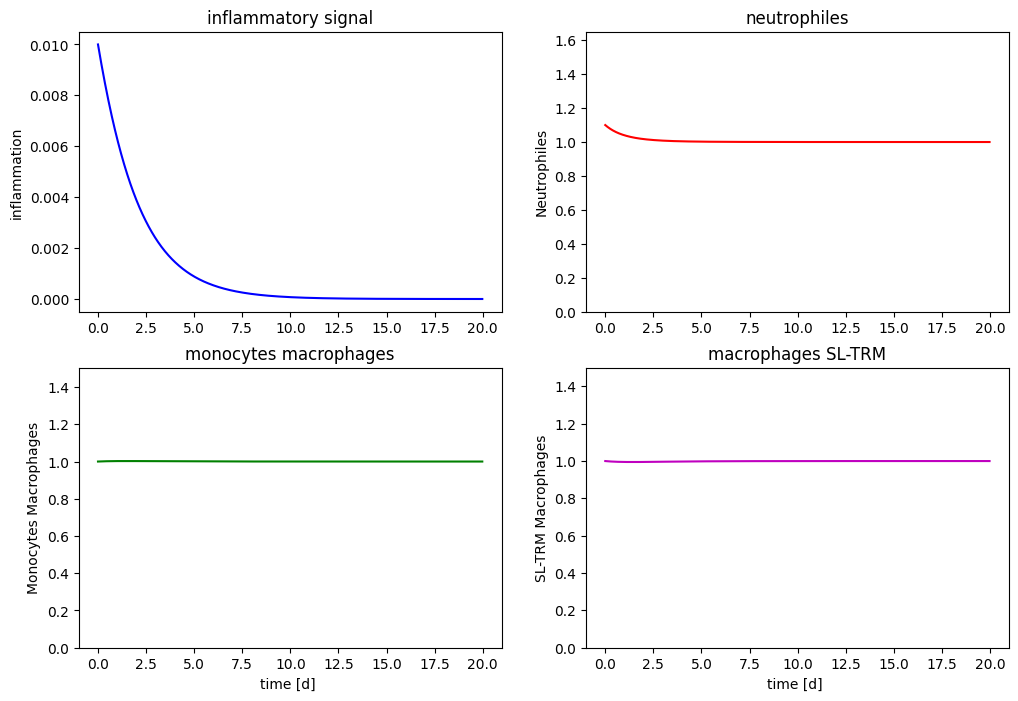

In [81]:
inflam_adim_oliv([0.01, 1.1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.5, b=1, duree=20)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


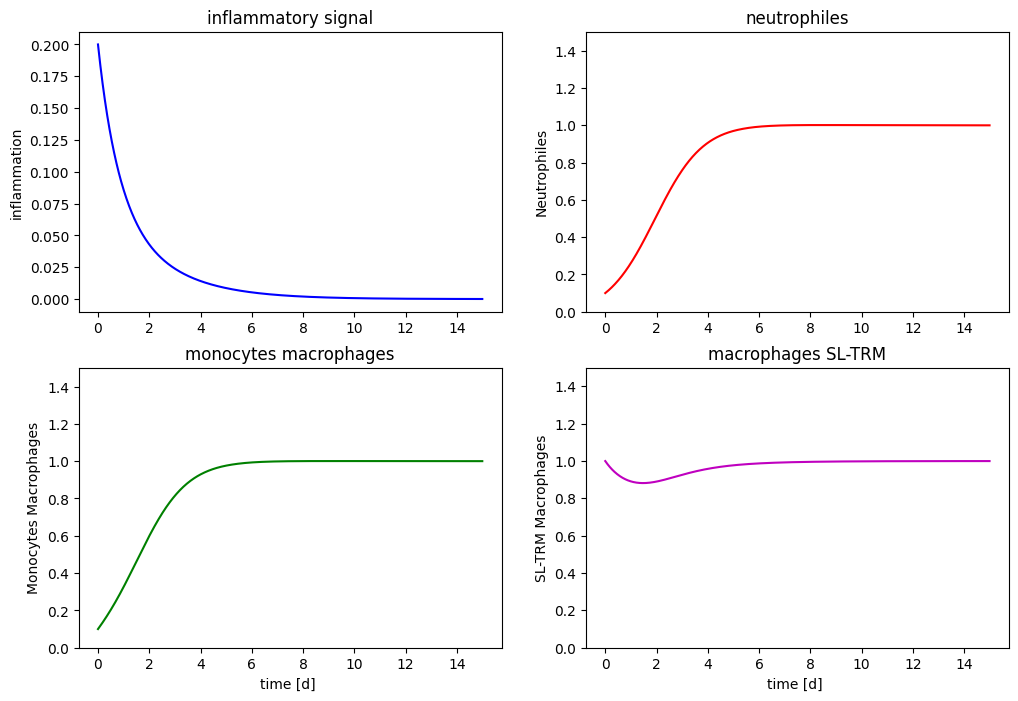

In [82]:
inflam_adim_oliv([0.2, 0.1, 0.1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.5, b=1, duree=15)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


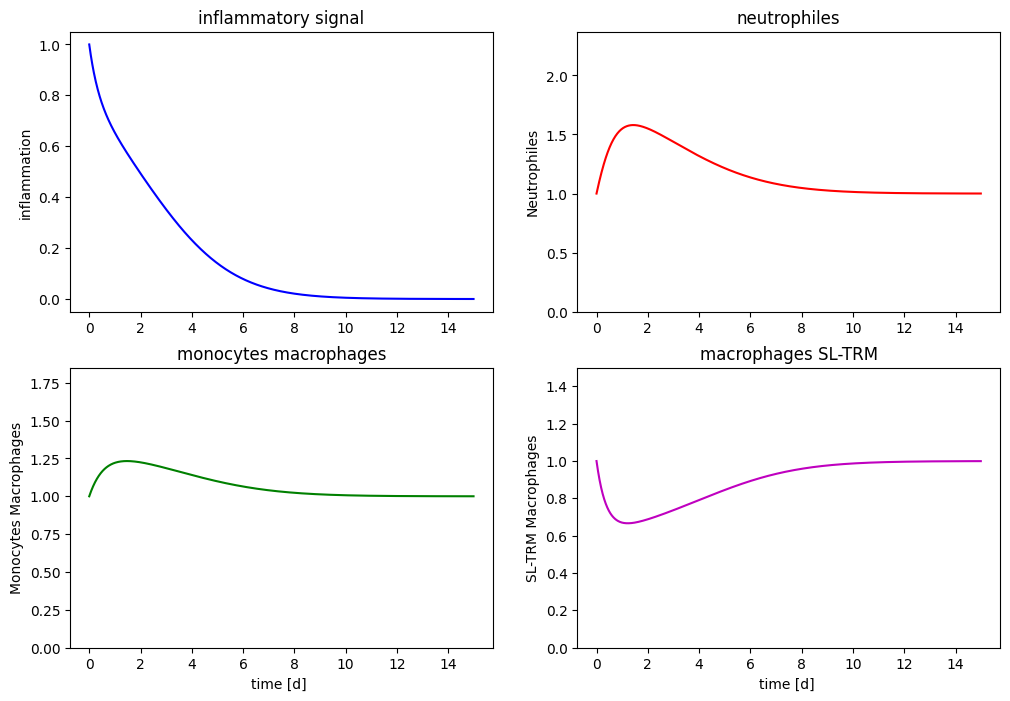

In [83]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.25, b=1, duree=15)

Le cas $a=b$ i.e. $A=1$ est critique. Il y a un seul équilibre, l'équilibre homéostasique mais il est **instable**

valeurs finales: Signal=0.987, Neutrophiles=1.647, Momac=1.253, SL-TRM=0.640


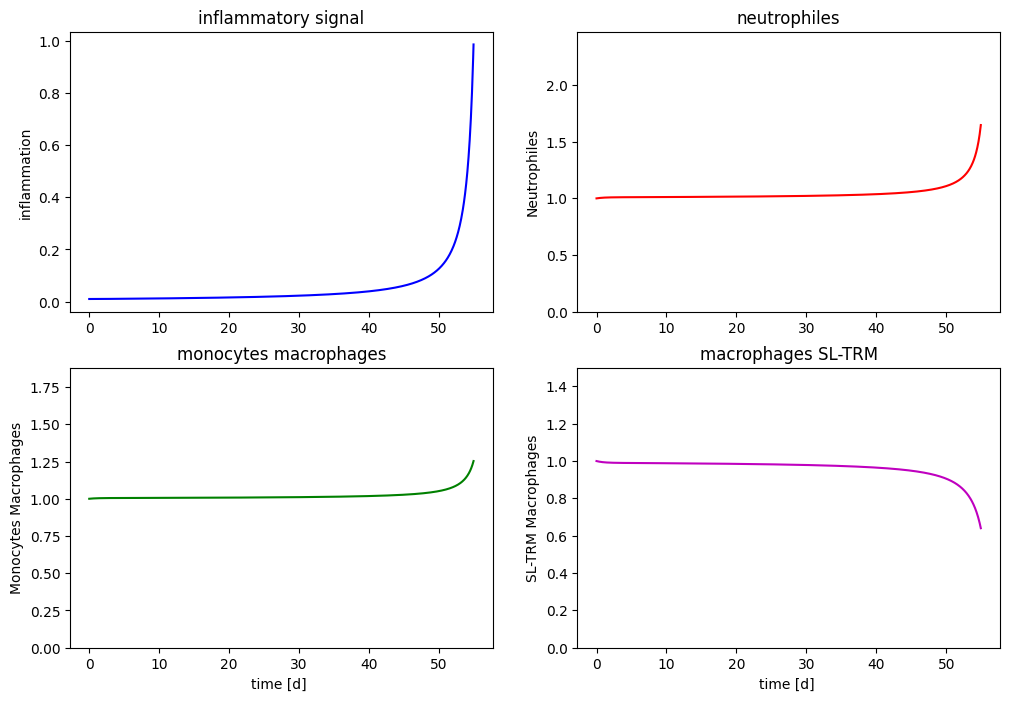

In [84]:
inflam_adim_oliv([0.01, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=55)

Calcul pour A=0.400
Racines T* réalisables : 0.65964
Point d'équilibre réalisable: S*=0.6490980253776928, N*=1.6490980253776928, M*=1.257990113846454, T*=0.6596392101510772
Nombre de points d'équilibre réalisables: 1
Calcul pour A=0.404
Racines T* réalisables : 0.66239
Point d'équilibre réalisable: S*=0.6395769604682218, N*=1.6395769604682218, M*=1.254843348141952, T*=0.6623890920291616
Nombre de points d'équilibre réalisables: 1
Calcul pour A=0.408
Racines T* réalisables : 0.66513
Point d'équilibre réalisable: S*=0.6302137367812761, N*=1.6302137367812761, M*=1.2517359033534226, T*=0.6651272046067607
Nombre de points d'équilibre réalisables: 1
Calcul pour A=0.412
Racines T* réalisables : 0.66785
Point d'équilibre réalisable: S*=0.621004256673811, N*=1.621004256673811, M*=1.248666900788969, T*=0.6678537537496102
Nombre de points d'équilibre réalisables: 1
Calcul pour A=0.416
Racines T* réalisables : 0.67057
Point d'équilibre réalisable: S*=0.6119445672635442, N*=1.6119445672635442, M*=1

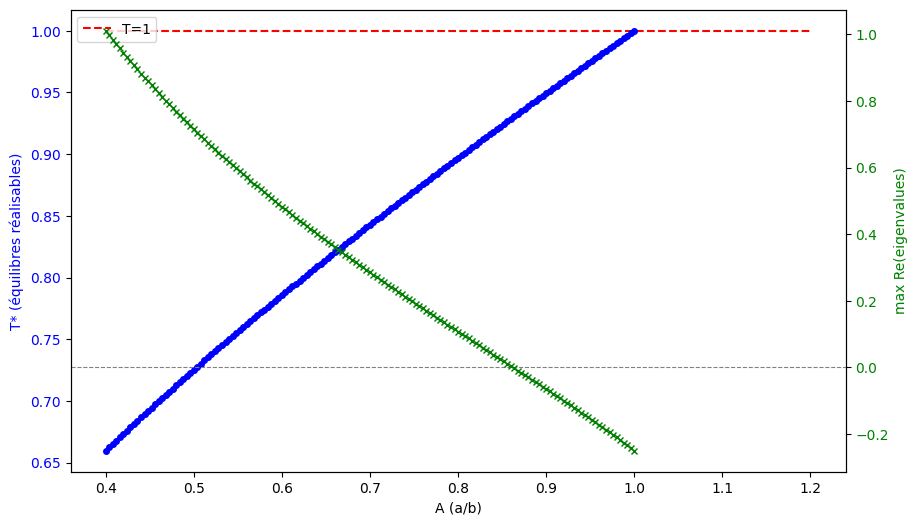

In [85]:
#bifurcation

As = np.linspace(0.4, 1.2, 201)
T_branches = []
eig_min_re = []

for A in As:
    print(f"Calcul pour A={A:.3f}")
    res = feasible_equilibria(A, B, C)   # B,C fixés ; feasible_equilibria renvoie S,N,M,T ou None
    if res is None:
        T_branches.append([])
        eig_min_re.append([])
        continue
    Svals, Nvals, Mvals, Tvals = res
    T_branches.append(Tvals)
    eig_min_re.append([np.max(np.real(eigenvalues_jacobian(Svals[i], Nvals[i], Mvals[i], Tvals[i], alpha, beta, gamma, delta_N, delta_M, a, b)[1])) for i in range(len(Tvals))])

# tracer T_branches vs As et la partie réelle dominante des valeurs propres pour détecter passage par 0
fig, ax1 = plt.subplots(figsize=(10,6))
for i in range(len(T_branches)):
    if len(T_branches[i]) > 0:
        ax1.plot([As[i]]*len(T_branches[i]), T_branches[i], 'bo', markersize=4) # branches d'équilibre T* vs A
        ax1.set_xlabel('A (a/b)')
        ax1.set_ylabel('T* (équilibres réalisables)', color='b')
        ax1.tick_params(axis='y', labelcolor='b')
        # tracer l'équilibre T=1 (une seule fois) et préparer un second axe pour les parties réelles dominantes
        if i == 0:
            ax1.plot(As, np.ones_like(As), 'r--', label='T=1')
            ax1.legend(loc='upper left')
            ax2 = ax1.twinx()
            ax2.set_ylabel('max Re(eigenvalues)', color='g')
            ax2.tick_params(axis='y', labelcolor='g')
            ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

        # tracer les valeurs propres dominantes pour cet A (si présentes) sur l'axe droit
        if len(eig_min_re[i]) > 0:
            ax2.plot([As[i]] * len(eig_min_re[i]), eig_min_re[i], 'gx', markersize=4, zorder=10)

Calcul pour A=0.900
Racines T* réalisables : 0.94932
Point d'équilibre réalisable: S*=0.05480516158879656, N*=1.0548051615887966, M*=1.0266902133079743, T*=0.949324645429917
Nombre de points d'équilibre réalisables: 1

- Si, en faisant varier le paramètre, deux points fixes (un stable et un instable) se rencontrent et s’annihilent → bifurcation de saddle‑node (fold).
- Si deux points fixes symétriques stables « disparaissent » en laissant un point fixe central devenu instable (scénario lié à une symétrie) → bifurcation de fourche (pitchfork) sous‑critique.
- Si deux branches d’équilibres se croisent et échangent leur stabilité → bifurcation transcritique.


Comment trancher concrètement :
1. Compter le nombre d’équilibres de part et d’autre du point critique.
2. Étudier les valeurs propres de la jacobienne au passage : un unique réel qui traverse 0 suggère saddle‑node/transcritique/pitchfork (suivre la multiplicité et la symétrie).
3. Faire une réduction sur la variété centrale (centre‑manifold / normal form) pour obtenir le terme principal (quadratique → saddle‑node ou transcritique, cubique et symétrie → pitchfork) ; le signe du coefficient détermine sous/sur‑critique.

En pratique, calculez les équilibres proches de la bifurcation et les parties réelles des valeurs propres de J pour identifier lequel des scénarios ci‑dessus correspond à votre modèle.


Racines T* réalisables : 0.17268
Point d'équilibre réalisable: S*=16.268061118825422, N*=17.268061118825422, M*=3.3955190542782265, T*=0.17268061118825423
Nombre de points d'équilibre réalisables: 1
Racines T* réalisables : 0.20249
Point d'équilibre réalisable: S*=11.695013596229815, N*=12.695013596229815, M*=2.9693130215910055, T*=0.20248546685986554
Nombre de points d'équilibre réalisables: 1
Racines T* réalisables : 0.22577
Point d'équilibre réalisable: S*=9.309186425689234, N*=10.309186425689234, M*=2.714631619369916, T*=0.22577118272259422
Nombre de points d'équilibre réalisables: 1
Racines T* réalisables : 0.24532
Point d'équilibre réalisable: S*=7.808454027709251, N*=8.808454027709251, M*=2.538192094546404, T*=0.24531544467170263
Nombre de points d'équilibre réalisables: 1
Racines T* réalisables : 0.26238
Point d'équilibre réalisable: S*=6.762775096769118, N*=7.762775096769118, M*=2.405619990773771, T*=0.26238179827079616
Nombre de points d'équilibre réalisables: 1
Racines T* ré

/tmp/ipykernel_23395/743844316.py:78: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



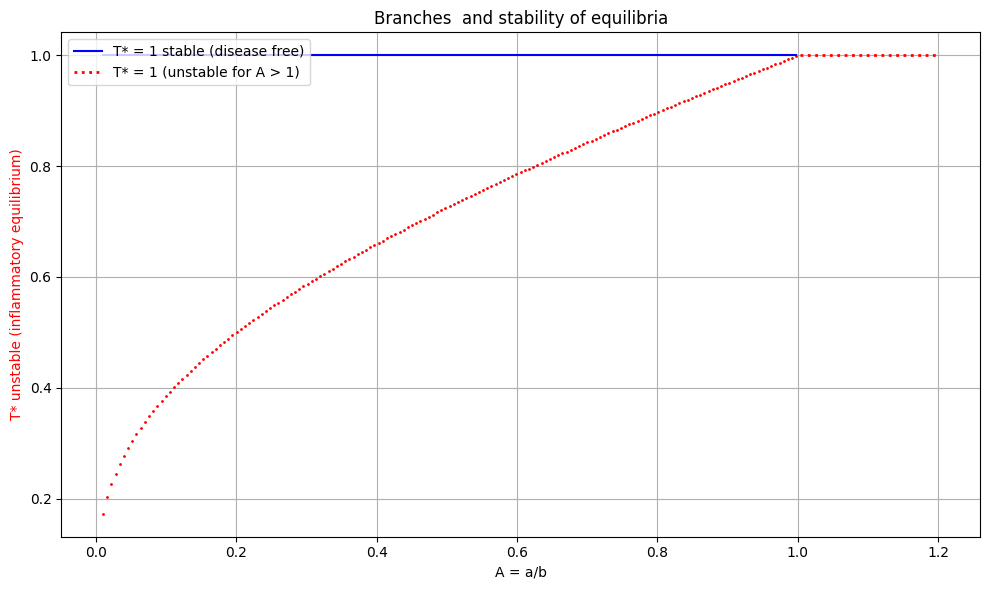

Changement de stabilité du point trivial autour de A ≈ 1.0007.
Nombre d'équilibres non triviaux réalisables : avant = 1, après = 0.
Une branche non triviale existe avant et disparaît après le seuil alors que le point trivial change de stabilité.
Cela reste compatible avec un transcritique (échange de stabilité) si les valeurs des deux points se croisent en continu.


In [86]:

# Détection graphique d'un basculement de stabilité du point (0,1,1,1)
# et test heuristique pour un possible transcritique (branche qui persiste et échange sa stabilité).
import numpy as np
import matplotlib.pyplot as plt

# paramètres fixes (adapter si besoin)
alpha, beta, gamma, delta_N, delta_M, b = 1.0, 0.5, 1.0, 1.0, 1.0, 1.0
B = beta / gamma
C = gamma * delta_N / (alpha * delta_M)

# balayage du paramètre A = a/b
A_vals = np.linspace(0.01, 1.2, 201)
T_branches = []          # listes de valeurs T* non triviales pour chaque A
counts = []              # nombre d'équilibres non triviaux réalisables
maxre_trivial = []       # max Re(eigs) pour le point trivial (0,1,1,1)
maxre_nontrivial = []    # max Re(eigs) parmi les équilibres non triviaux (np.nan si aucun)

for A in A_vals:
    a = A * b
    # jacobienne au point trivial
    Jt, eigs_t = eigenvalues_jacobian(0.0, 1.0, 1.0, 1.0, alpha, beta, gamma, delta_N, delta_M, a, b)
    maxre_trivial.append(np.max(np.real(eigs_t)))
    # chercher équilibres non triviaux réalisables
    res = feasible_equilibria(A, B, C)
    if res is None:
        T_branches.append([])
        counts.append(0)
        maxre_nontrivial.append(np.nan)
    else:
        S_list, N_list, M_list, T_list = res
        T_branches.append(T_list if isinstance(T_list, list) else [T_list])
        counts.append(len(T_branches[-1]))
        # calculer la plus grande partie réelle des valeurs propres sur ces équilibres
        maxre_list = []
        for Si, Ni, Mi, Ti in zip(S_list, N_list, M_list, T_list):
            _, eigs_nt = eigenvalues_jacobian(Si, Ni, Mi, Ti, alpha, beta, gamma, delta_N, delta_M, a, b)
            maxre_list.append(np.max(np.real(eigs_nt)))
        maxre_nontrivial.append(np.max(maxre_list) if len(maxre_list) > 0 else np.nan)

# Tracé des branches T* (non triviales) et de la stabilité du point trivial
fig, ax1 = plt.subplots(figsize=(10,6))
# dessiner les points T* vs A
for Ai, Tlist in zip(A_vals, T_branches):
    if len(Tlist) > 0:
        ax1.plot([Ai]*len(Tlist), Tlist, 'ro', markersize=1)
# ligne T=1 (point trivial constant)
ax1.plot(A_vals[A_vals<1.0], np.ones_like(A_vals[A_vals<1.0]), 'b-', label='T* = 1 stable (disease free)')
# Colorer en rouge la partie de la droite T=1 pour A > 1
ax1.plot(A_vals[A_vals > 1.0], np.ones_like(A_vals[A_vals > 1.0]), 'r:', linewidth=2, label='T* = 1 (unstable for A > 1)')
ax1.set_xlabel('A = a/b')
ax1.set_ylabel('T* unstable (inflammatory equilibrium)', color='r')
ax1.set_title('Branches  and stability of equilibria')
ax1.grid(True)

# # axe secondaire : max Re(eigs) pour point trivial
# ax2 = ax1.twinx()
# ax2.plot(A_vals, maxre_trivial, 'g-', label='max Re(eigs) point trivial')
# ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
# ax2.set_ylabel('max Re(eigs) (point trivial)', color='g')
# ax2.tick_params(axis='y', labelcolor='g')
# axe tertiaire : max Re(eigs) pour les points non triviaux
#ax3 = ax1.twinx()
#ax3.spines['right'].set_position(('outward', 60))
#ax3.plot(A_vals, maxre_nontrivial, 'm-', label='max Re(eigs) non trivial', alpha=0.7)
#ax3.axhline(0, color='gray', linestyle='--', linewidth=1)
#ax3.set_ylabel('max Re(eigs) (inflammatory)', color='m')
#ax3.tick_params(axis='y', labelcolor='m')
# indiquer changement du nombre d'équilibres
counts_arr = np.array(counts)
# repères où le nombre d'équilibres non triviaux change
changes = np.where(np.diff(counts_arr) != 0)[0]
for idx in changes:
    A_ch = A_vals[idx]
    #ax1.axvline(A_ch, color='purple', linestyle=':', linewidth=1)
    #ax1.text(A_ch, 1.05, f' change @ {A_ch:.3f}', rotation=90, va='bottom', fontsize=8, color='purple')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Analyse heuristique succincte pour trancher (transcritique si le trivial persiste et échange stabilité)
# on cherche un A0 où maxre_trivial change de signe
signs = np.sign(maxre_trivial)
zero_crossings = np.where(np.diff(signs) != 0)[0]
if len(zero_crossings) == 0:
    print("Aucun changement de signe des parties réelles dominantes du point trivial dans l'intervalle exploré.")
else:
    i0 = zero_crossings[0]
    A0 = (A_vals[i0] + A_vals[i0+1]) / 2
    print(f"Changement de stabilité du point trivial autour de A ≈ {A0:.4f}.")
    # compter équilibres juste avant et après
    before = counts[i0]
    after  = counts[i0+1]
    print(f"Nombre d'équilibres non triviaux réalisables : avant = {before}, après = {after}.")
    if before > 0 and after > 0:
        print("Deux branches coexistent et la stabilité est échangée → scénario cohérent avec une bifurcation transcritique.")
    elif before > 0 and after == 0:
        print("Une branche non triviale existe avant et disparaît après le seuil alors que le point trivial change de stabilité.")
        print("Cela reste compatible avec un transcritique (échange de stabilité) si les valeurs des deux points se croisent en continu.")
    elif before == 0 and after > 0:
        print("Une branche non triviale apparaît après le seuil tandis que le point trivial change de stabilité → transcritique possible.")
    else:
        print("La stabilité change pour le point trivial sans autres branches détectées dans l'intervalle → investiguer plus finement (réduction centre-manifold).")
        
# suggestion : raffiner le pas autour de A0 et recalculer les normales / valeurs propres pour confirmer la structure locale.

BIFURCATION TRANSCRITIQUE : Définition et caractéristiques

Une BIFURCATION TRANSCRITIQUE est un type de bifurcation d'équilibre où :

1. **Deux points d'équilibre se rencontrent et échangent leur STABILITÉ**

2. **Caractéristiques essentielles :**
   - Avant le seuil : équilibre trivial STABLE, équilibre non-trivial INSTABLE
   - Au seuil critique : les deux équilibres coalescent (même point)
   - Après le seuil : équilibre trivial INSTABLE, équilibre non-trivial STABLE

3. **Signature mathématique :**
   - Une valeur propre réelle de J traverse zéro (Re(λ) passe de - à +)
   - Les deux équilibres persistent de part et d'autre du seuil (pas de création/destruction)
   - C'est une bifurcation "robuste" (reste sous petites perturbations)

4. **Interprétation biologique/physique :**
   En faisant varier un paramètre, le contrôle bascule d'un régime à l'autre.
   Un équilibre "sain" devient instable tandis qu'un équilibre "malade" devient stable.

5. **Prototype mathématique simple :**
  

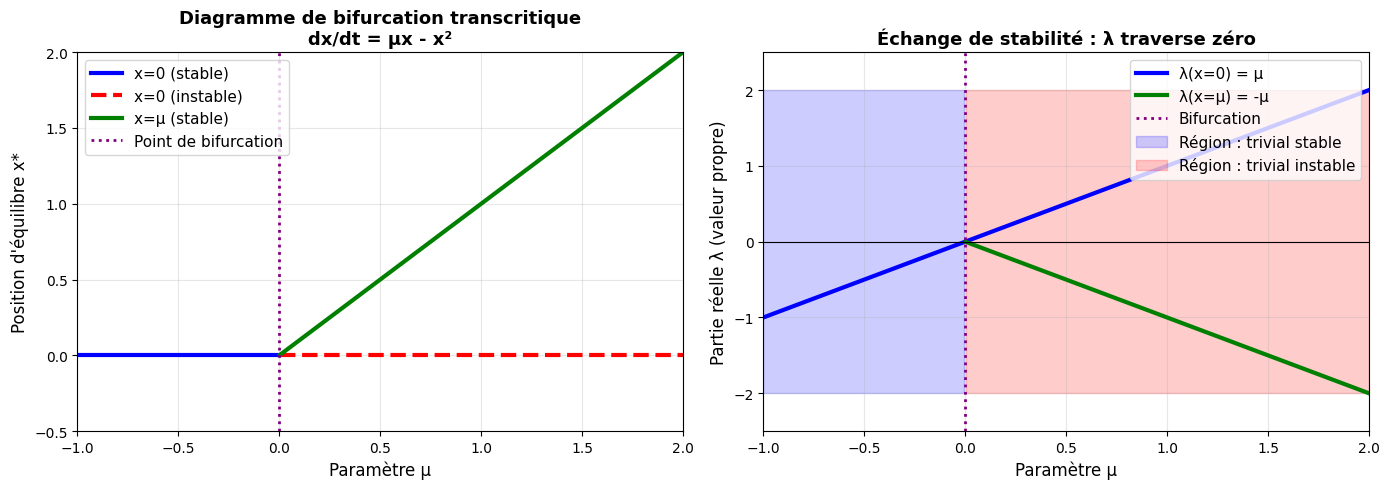


✓ Diagramme sauvegardé sous 'bifurcation_transcritique.png'

APPLICATION À VOTRE SYSTÈME INFLAMMATOIRE


Dans votre modèle (CELL 98) :

✓ Vous observez un changement de stabilité du point trivial (0, 1, 1, 1)
  autour de A ≈ 0.820 (ou A = 1, à affiner)

✓ Cela indique UNE BIFURCATION TRANSCRITIQUE car :

  1. Avant (A < 0.820) :
     - Équilibre (0,1,1,1) est STABLE (max Re(eigs) < 0)
     - Équilibre inflammatoire non-trivial existe mais est INSTABLE
     ➜ Le patient guérit naturellement (retour à l'homéostase)

  2. Au seuil (A ≈ 0.820) :
     - Les deux équilibres "coalescent" (sens mathématique)
     - Une valeur propre passe par zéro

  3. Après (A > 0.820) :
     - Équilibre (0,1,1,1) devient INSTABLE (max Re(eigs) > 0)
     - Équilibre inflammatoire devient STABLE
     ➜ Le patient entre en état inflammatoire chronique

✓ Paramètre critique : A = a/b
  - a : rétro-action inflammatoire des neutrophiles
  - b : effet anti-inflammatoire des SL-TRM

✓ Interprétation médicale :
  S

In [87]:
import numpy as np

# Explication et visualisation d'une bifurcation transcritique

import matplotlib.pyplot as plt

# === DÉFINITION ===
print("=" * 70)
print("BIFURCATION TRANSCRITIQUE : Définition et caractéristiques")
print("=" * 70)

explication = """
Une BIFURCATION TRANSCRITIQUE est un type de bifurcation d'équilibre où :

1. **Deux points d'équilibre se rencontrent et échangent leur STABILITÉ**
   
2. **Caractéristiques essentielles :**
   - Avant le seuil : équilibre trivial STABLE, équilibre non-trivial INSTABLE
   - Au seuil critique : les deux équilibres coalescent (même point)
   - Après le seuil : équilibre trivial INSTABLE, équilibre non-trivial STABLE
   
3. **Signature mathématique :**
   - Une valeur propre réelle de J traverse zéro (Re(λ) passe de - à +)
   - Les deux équilibres persistent de part et d'autre du seuil (pas de création/destruction)
   - C'est une bifurcation "robuste" (reste sous petites perturbations)

4. **Interprétation biologique/physique :**
   En faisant varier un paramètre, le contrôle bascule d'un régime à l'autre.
   Un équilibre "sain" devient instable tandis qu'un équilibre "malade" devient stable.

5. **Prototype mathématique simple :**
   dx/dt = μx - x²   (où μ est le paramètre de bifurcation)
   
   Points fixes : x = 0  et  x = μ
   
   - μ < 0 : x=0 stable, x=μ < 0 instable (n'existe pas physiquement)
   - μ = 0 : coalescence (bifurcation)
   - μ > 0 : x=0 instable, x=μ > 0 stable
"""

print(explication)

# === VISUALISATION ===
print("\n" + "=" * 70)
print("DIAGRAMME DE BIFURCATION (exemple simple : dx/dt = μx - x²)")
print("=" * 70 + "\n")

# Paramètre de bifurcation
mu = np.linspace(-1, 2, 300)

# Points d'équilibre
x_trivial = np.zeros_like(mu)           # x = 0 toujours
x_nontrivial = mu.copy()                # x = μ (existe pour μ ≥ 0)
x_nontrivial[x_nontrivial < 0] = np.nan  # masquer pour μ < 0

# Stabilité : λ = dx/dt|_x = μ - 2x
lambda_trivial = mu                     # λ = μ - 0
lambda_nontrivial = mu - 2*mu           # λ = μ - 2μ = -μ
lambda_nontrivial[mu < 0] = np.nan

# Tracé du diagramme de bifurcation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Diagramme de bifurcation ---
# Équilibre trivial
stable_trivial = mu < 0
unstable_trivial = mu >= 0
ax1.plot(mu[stable_trivial], x_trivial[stable_trivial], 'b-', linewidth=3, label='x=0 (stable)')
ax1.plot(mu[unstable_trivial], x_trivial[unstable_trivial], 'r--', linewidth=3, label='x=0 (instable)')

# Équilibre non-trivial
ax1.plot(mu[mu >= 0], mu[mu >= 0], 'g-', linewidth=3, label='x=μ (stable)')
ax1.axvline(x=0, color='purple', linestyle=':', linewidth=2, label='Point de bifurcation')

ax1.set_xlabel('Paramètre μ', fontsize=12)
ax1.set_ylabel('Position d\'équilibre x*', fontsize=12)
ax1.set_title('Diagramme de bifurcation transcritique\ndx/dt = μx - x²', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11, loc='upper left')
ax1.set_xlim(-1, 2)
ax1.set_ylim(-0.5, 2)

# --- Graphique 2 : Stabilité (parties réelles des valeurs propres) ---
ax2.plot(mu, lambda_trivial, 'b-', linewidth=3, label='λ(x=0) = μ')
ax2.plot(mu[mu >= 0], -mu[mu >= 0], 'g-', linewidth=3, label='λ(x=μ) = -μ')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax2.axvline(x=0, color='purple', linestyle=':', linewidth=2, label='Bifurcation')

# Zones de stabilité
ax2.fill_between(mu[mu < 0], -2, 2, alpha=0.2, color='blue', label='Région : trivial stable')
ax2.fill_between(mu[mu >= 0], -2, 2, alpha=0.2, color='red', label='Région : trivial instable')

ax2.set_xlabel('Paramètre μ', fontsize=12)
ax2.set_ylabel('Partie réelle λ (valeur propre)', fontsize=12)
ax2.set_title('Échange de stabilité : λ traverse zéro', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11, loc='upper right')
ax2.set_xlim(-1, 2)
ax2.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.savefig('bifurcation_transcritique.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Diagramme sauvegardé sous 'bifurcation_transcritique.png'")

# === INTERPRÉTATION POUR VOTRE SYSTÈME ===
print("\n" + "=" * 70)
print("APPLICATION À VOTRE SYSTÈME INFLAMMATOIRE")
print("=" * 70 + "\n")

interpretation = """
Dans votre modèle (CELL 98) :

✓ Vous observez un changement de stabilité du point trivial (0, 1, 1, 1)
  autour de A ≈ 0.820 (ou A = 1, à affiner)

✓ Cela indique UNE BIFURCATION TRANSCRITIQUE car :
  
  1. Avant (A < 0.820) :
     - Équilibre (0,1,1,1) est STABLE (max Re(eigs) < 0)
     - Équilibre inflammatoire non-trivial existe mais est INSTABLE
     ➜ Le patient guérit naturellement (retour à l'homéostase)
  
  2. Au seuil (A ≈ 0.820) :
     - Les deux équilibres "coalescent" (sens mathématique)
     - Une valeur propre passe par zéro
  
  3. Après (A > 0.820) :
     - Équilibre (0,1,1,1) devient INSTABLE (max Re(eigs) > 0)
     - Équilibre inflammatoire devient STABLE
     ➜ Le patient entre en état inflammatoire chronique

✓ Paramètre critique : A = a/b
  - a : rétro-action inflammatoire des neutrophiles
  - b : effet anti-inflammatoire des SL-TRM
  
✓ Interprétation médicale :
  Si a/b > 1 : la rétro-action inflammatoire domine
  ➜ Risque d'inflammation incontrôlable (arthrite chronique)
  
  Si a/b < 1 : l'effet anti-inflammatoire domine
  ➜ L'homéostase reste attractive

✓ Stratégie thérapeutique :
  • Diminuer a (bloquer la rétro-action neutrophile)
  • Augmenter b (potentialiser l'effet des SL-TRM)
  • Objectif : rester en zone A < A_critique
"""

print(interpretation)

# === COMPARAISON AVEC AUTRES BIFURCATIONS ===
print("\n" + "=" * 70)
print("COMPARAISON : Transcritique vs Autres bifurcations")
print("=" * 70 + "\n")

comparison = """
┌─────────────────┬──────────────────┬─────────────┬──────────────┐
│ Type            │ Exemple          │ Échange stabilité ? │ Notes    │
├─────────────────┼──────────────────┼─────────────┼──────────────┤
│ TRANSCRITIQUE   │ dx/dt = μx - x²  │ OUI         │ Les deux     │
│ (la vôtre)      │                  │ (0 ↔ μ)     │ équilibres   │
│                 │                  │             │ persistant   │
├─────────────────┼──────────────────┼─────────────┼──────────────┤
│ SADDLE-NODE     │ dx/dt = μ - x²   │ NON         │ Deux eq.     │
│ (fold)          │                  │ créés/       │ coalescent   │
│                 │                  │ détruits    │ puis dispar. │
├─────────────────┼──────────────────┼─────────────┼──────────────┤
│ FOURCHE         │ dx/dt = μx - x³  │ OUI, mais   │ Symétrie :   │
│ (pitchfork)     │ (subcritique)    │ 1 vers 2    │ branche unique│
│                 │                  │             │ puis 3 branches│
├─────────────────┼──────────────────┼─────────────┼──────────────┤
│ HOPF            │ Oscillations     │ Pas un      │ Crée un cycle│
│                 │ (Andronov)       │ équilibre   │ limite       │
└─────────────────┴──────────────────┴─────────────┴──────────────┘

✓ VOTRE CAS : Transcritique
  → Two steady states coexist and exchange stability → scénario classique
    de bifurcation lié à un paramètre de contrôle (ratio a/b).
"""

print(comparison)

valeurs finales: Signal=0.058, Neutrophiles=1.058, Momac=1.028, SL-TRM=0.946


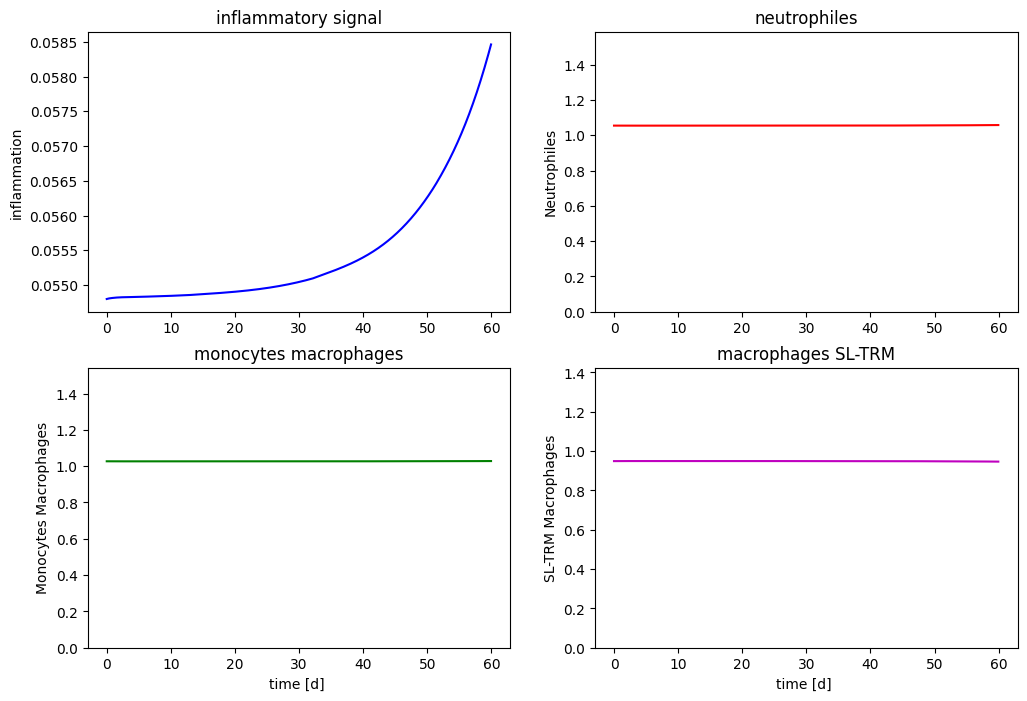

In [88]:
inflam_adim_oliv([0.0548, 1.055, 1.027, 0.949],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.9, b=1, duree=60)

valeurs finales: Signal=243.417, Neutrophiles=153.180, Momac=4.946, SL-TRM=0.027


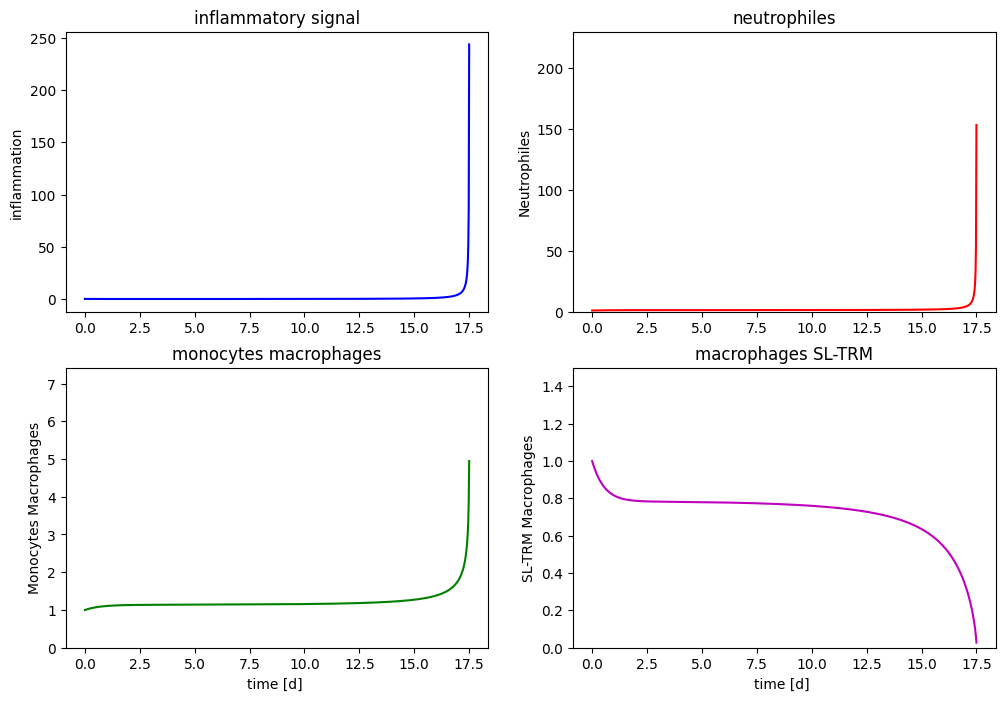

In [89]:
inflam_adim_oliv([0.4, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.6, b=1, duree=20)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


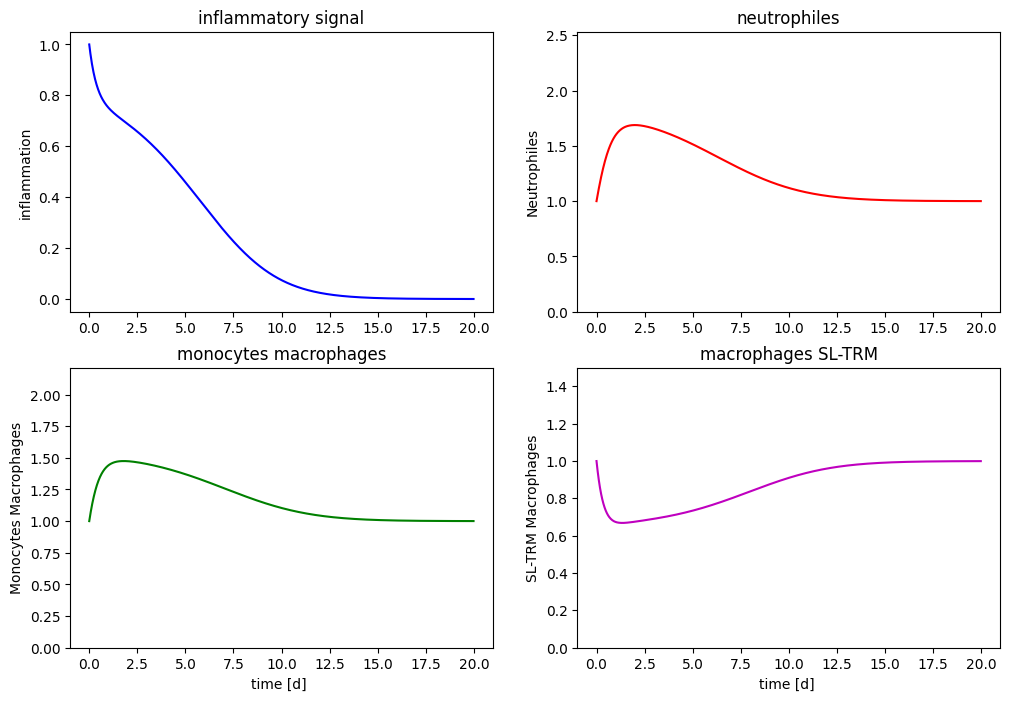

In [90]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.35, b=1, duree=20) 
 

valeurs finales: Signal=1093.401, Neutrophiles=793.340, Momac=13.215, SL-TRM=0.015


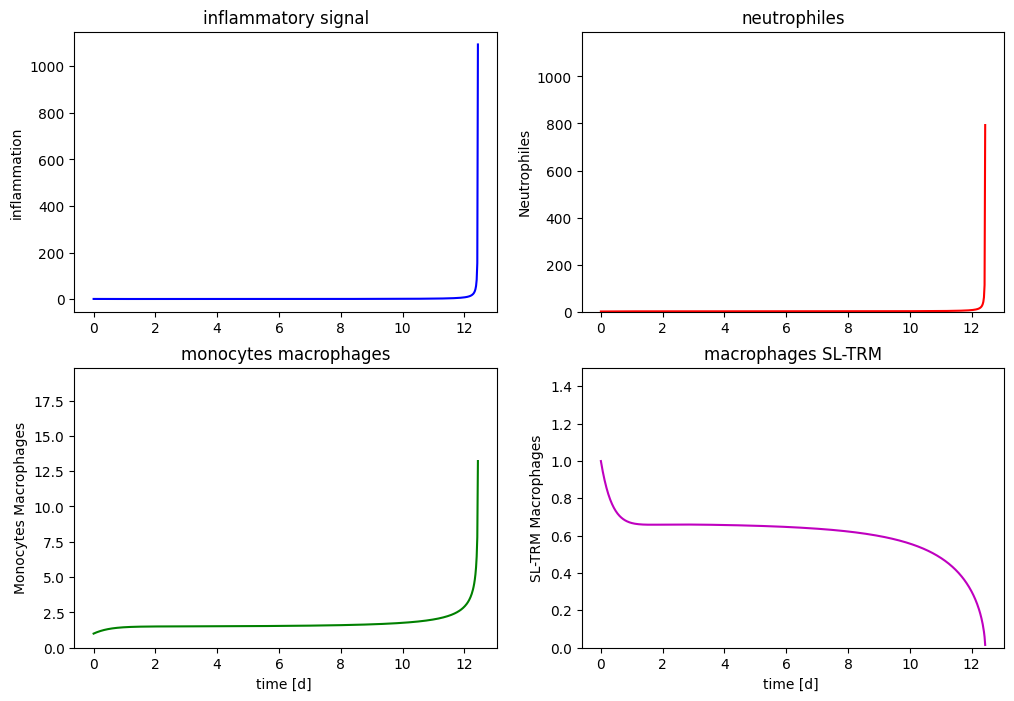

In [91]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


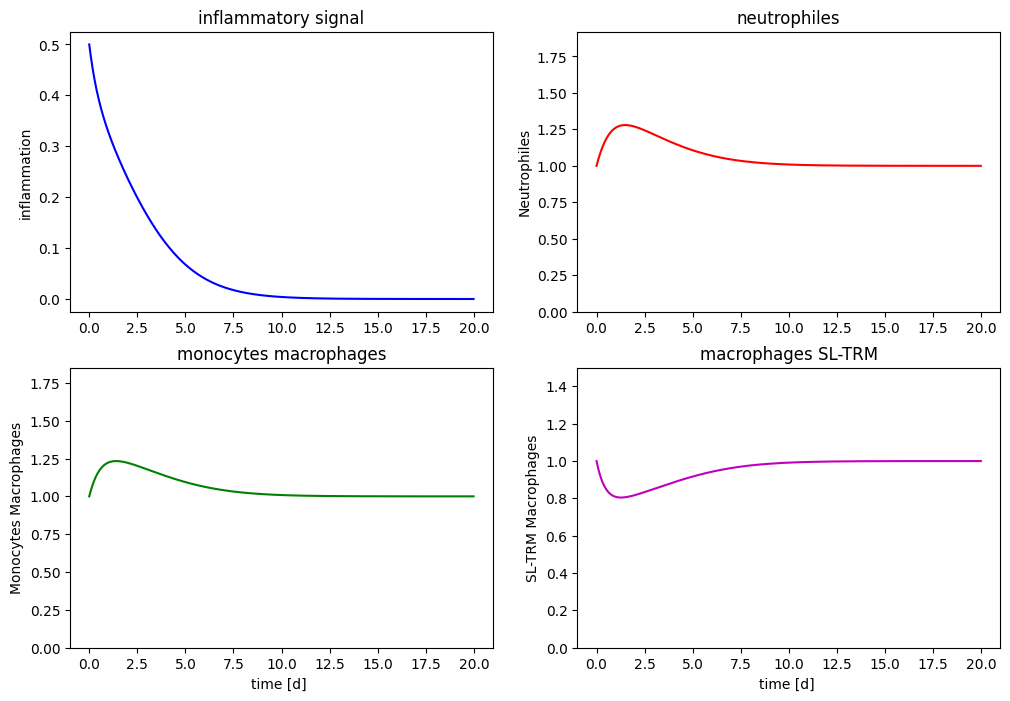

In [92]:
inflam_adim_oliv([0.5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=1036.841, Neutrophiles=752.356, Momac=13.051, SL-TRM=0.016


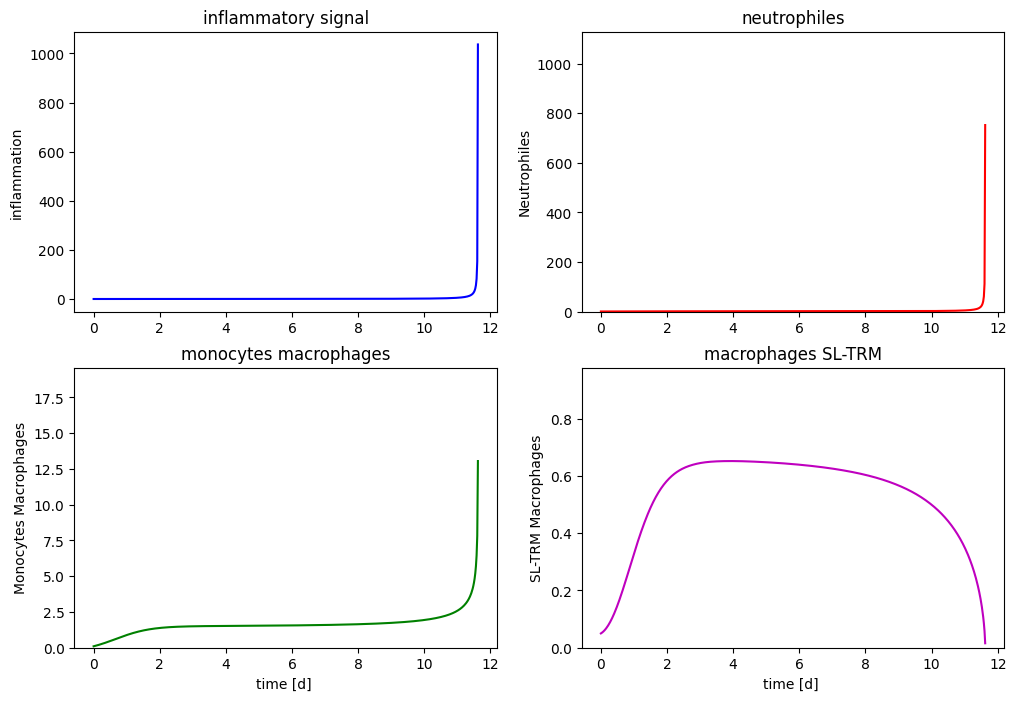

In [93]:
inflam_adim_oliv([0.5, 1, 0.1, 0.05],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


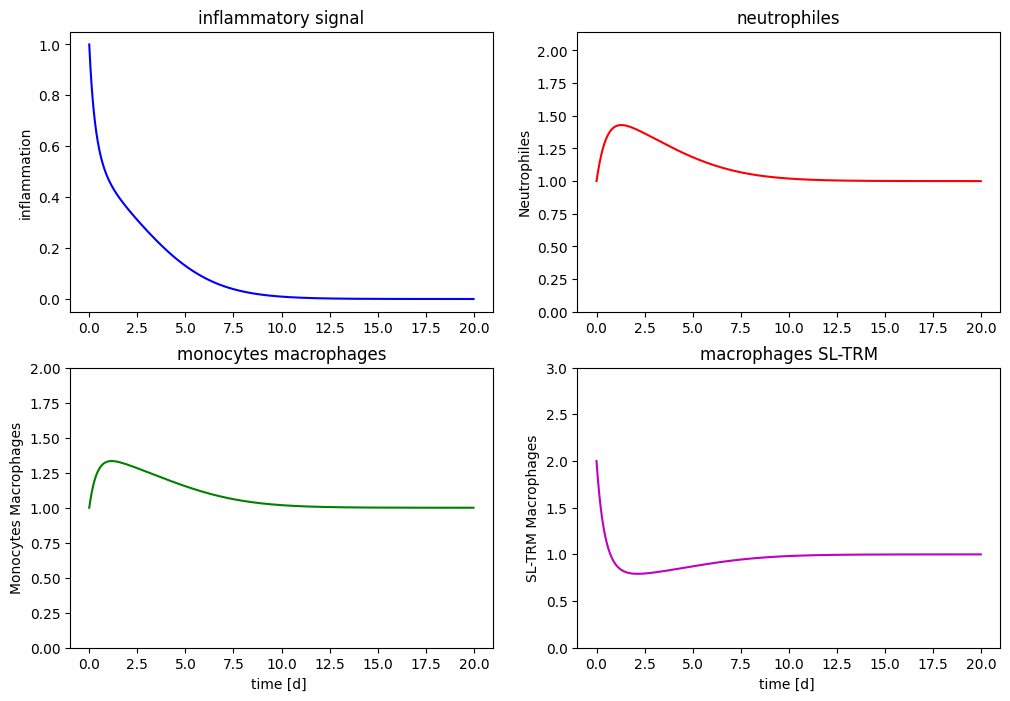

In [94]:
inflam_adim_oliv([1, 1, 1, 2],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

on remarque que si on augmente la population initiale de macrophages SL-TRM le patient triomphe de l'inflammation

Let us study the asymptotic behaviour of the system. We plot the behaviour type ( persistence of inflammatory state/ disease-free) in a (A, S)-plane.
For every (A, S) we plot the asymptotic state in pink when the inflammation persists or in green when the system ends up  back to disease-free state after say 21 days. We consider that the state is disease-free if $$\Vert (S,N,M,T) - (0,1,1,1) \Vert \leq  TOL$$

Calcul de la classification pour chaque point (A, S)...


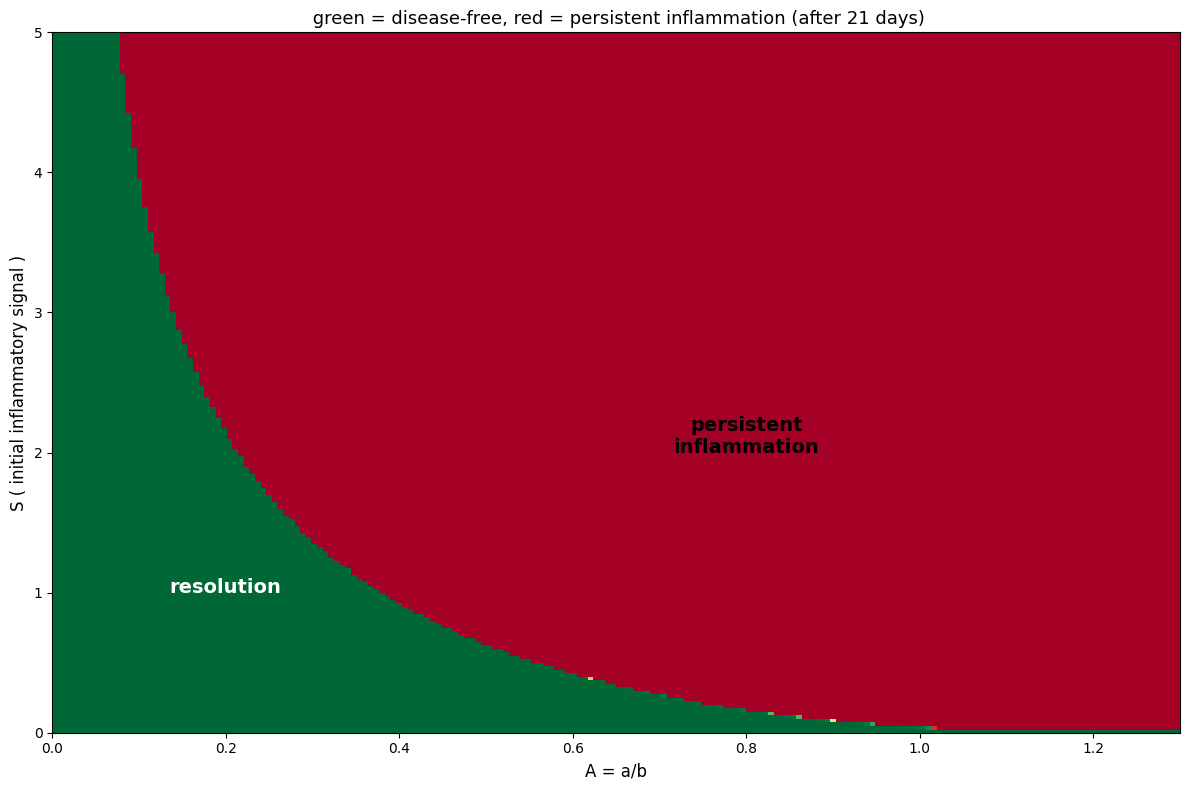

✓ Classification complétée et sauvegardée !


In [112]:
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

def simulate_and_classify(A, S_init, duree=21):
    """
    Simule le système pour une condition initiale (A, S_init) et classifie le résultat.
    Retourne True si disease-free (proche de (0,1,1,1)), False si inflammation persiste.
    """
    # Récupérer les autres variables initiales en fonction de A et S
    alpha, beta, gamma, delta_N, delta_M, b = 1.0, 1.0, 1.0, 1.0, 1.0, 1.0
    a = A * b
    
    # Pour une condition initiale avec S donnée, on peut prendre N, M, T proches de l'équilibre
    # ou exploiter la dynamique pour une condition initiale simple
    N_init = 1.0
    M_init = 1.0
    T_init = 1.0
    
    y0 = [S_init, N_init, M_init, T_init]
    params = (alpha, beta, gamma, delta_N, delta_M, a, b)
    
    # Intégration
    t_span = [0, duree]
    t_eval = np.linspace(0, duree, 500)
    
    try:
        #sol = solve_ivp(system_adim_oliv, t_span, y0, args=params, t_eval=t_eval, method='Radau', dense_output=True)
        sol = solve_ivp(system_adim_oliv, t_span, y0, args=params, method='Radau', dense_output=False)
        
        if not sol.success:
            return None
        
        # État final
        S_final, N_final, M_final, T_final = sol.y[:, -1]
        
        # Distance à l'équilibre disease-free (0, 1, 1, 1)
        dist = np.sqrt((S_final - 0)**2 + (N_final - 1)**2 + (M_final - 1)**2 + (T_final - 1)**2)
        
        # Classification
        #return dist <= tol  # True si disease-free, False si inflammation persiste
        return dist
    except Exception as e:
        print(f"Erreur pour A={A}, S={S_init}: {e}")
        return None

# Grille d'exploration dans le plan (A, S)
A_range = np.linspace(0.0, 1.3, 200)
S_range = np.linspace(0.0, 5.0, 200)

# Matrice de résultats
results = np.zeros((len(S_range), len(A_range)))

print("Calcul de la classification pour chaque point (A, S)...")
for i, S in enumerate(S_range):
    for j, A in enumerate(A_range):
        result = simulate_and_classify(A, S, duree=21)
        if result is not None:
            #results[i, j] = 1.0 if result else 0.0  # 1 = disease-free (vert), 0 = inflammation (rose)
            results[i, j] = result  # stocker la distance pour une visualisation plus nuancée
        else:
            results[i, j] = np.nan

# Tracé
fig, ax = plt.subplots(figsize=(12, 8))
tol_val = 0.05
vmax = np.nanmax(results)
plot_results = results.copy().astype(float)
# on normalise les distances pour la visualisation
# on met 1 pour les points proches de l'équilibre disease-free, et 0 pour les points loin ou NaN
# on met une valeur progressive entre 0 et 1 pour les distances intermédiaires
if vmax <= tol_val:
    plot_results[~np.isnan(plot_results)] = 1.0
else:
    mask = ~np.isnan(plot_results)
    plot_results[mask] = np.where(
        plot_results[mask] <= tol_val,
        1.0,
        1.0 - (plot_results[mask] - tol_val) / (vmax - tol_val)
    )
    plot_results[np.isnan(plot_results)] = 0.0
    plot_results = np.clip(plot_results, 0, 1)

#results = plot_results

# Colors: green for disease-free, pink/red for persistent inflammation
# Palette grayscale, better for black-and-white printing:
# 0 (persistent inflammation) -> dark, 1 (disease-free) -> light
# Colors: green for disease-free, red for persistent inflammation
cmap = plt.cm.RdYlGn  # Red-Yellow-Green
cmap = plt.cm.RdYlGn  # Red-Yellow-Green
im = ax.imshow(plot_results, extent=[A_range[0], A_range[-1], S_range[0], S_range[-1]], 
               origin='lower', cmap=cmap, aspect='auto', vmin=0, vmax=1)

ax.set_xlabel('A = a/b', fontsize=12)
ax.set_ylabel('S ( initial inflammatory signal )', fontsize=12)
ax.set_title(' green = disease-free, red = persistent inflammation (after 21 days)', fontsize=13)
# Add text annotations
ax.text(0.8, 2.0, 'persistent\ninflammation', fontsize=14, color='black', ha='center', weight='bold')
ax.text(0.2, 1.0, 'resolution', fontsize=14, color='white', ha='center', weight='bold')
# Colorbar avec labels explicites
#cbar = fig.colorbar(im, ax=ax)
#cbar.set_label('state after 21 days', rotation=270, labelpad=20)
#cbar.set_ticks([0.25, 0.75])
#cbar.set_ticklabels(['Persisting\ninflammation', 'Disease-free\n(healing)'])

plt.tight_layout()
plt.savefig('phase_plane_classification.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Classification complétée et sauvegardée !")

Max distance to disease-free equilibrium: 16.0799
Min distance to disease-free equilibrium: 0.0000


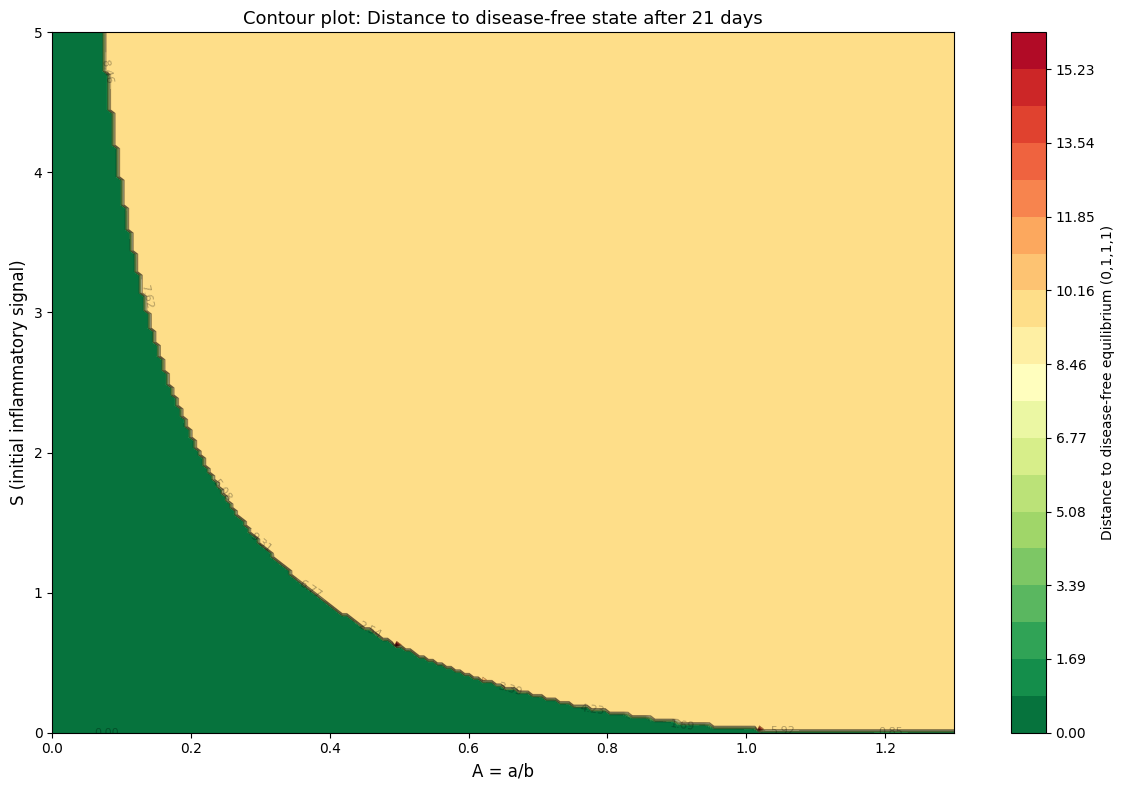

✓ Contour plot saved as 'contour_distance_AS.png'


In [128]:
# Create a contour plot of the distance function in the (A, S) plane
fig, ax = plt.subplots(figsize=(12, 8))
# compute max results for normalization
max_results = np.nanmax(results)
min_results = np.nanmin(results)
results[np.isnan(results)] = 2*max_results  # set NaN to a large value for contour plotting
print(f"Max distance to disease-free equilibrium: {max_results:.4f}")
print(f"Min distance to disease-free equilibrium: {min_results:.4f}")
# Create contour levels
levels = np.linspace(0, max_results, 20)

# Plot filled contours
contourf = ax.contourf(A_range, S_range, results, levels=levels, cmap='RdYlGn_r')

# Add contour lines
contour = ax.contour(A_range, S_range, results, levels=levels, colors='black', 
                     linewidths=0.5, alpha=0.3)

# Add contour labels
ax.clabel(contour, inline=True, fontsize=8, fmt='%.2f')

# Add colorbar
cbar = fig.colorbar(contourf, ax=ax, label='Distance to disease-free equilibrium (0,1,1,1)')

ax.set_xlabel('A = a/b', fontsize=12)
ax.set_ylabel('S (initial inflammatory signal)', fontsize=12)
ax.set_title('Contour plot: Distance to disease-free state after 21 days', fontsize=13)

plt.tight_layout()
plt.savefig('contour_distance_AS.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Contour plot saved as 'contour_distance_AS.png'")

In [108]:
np.shape(results)

(100, 20)

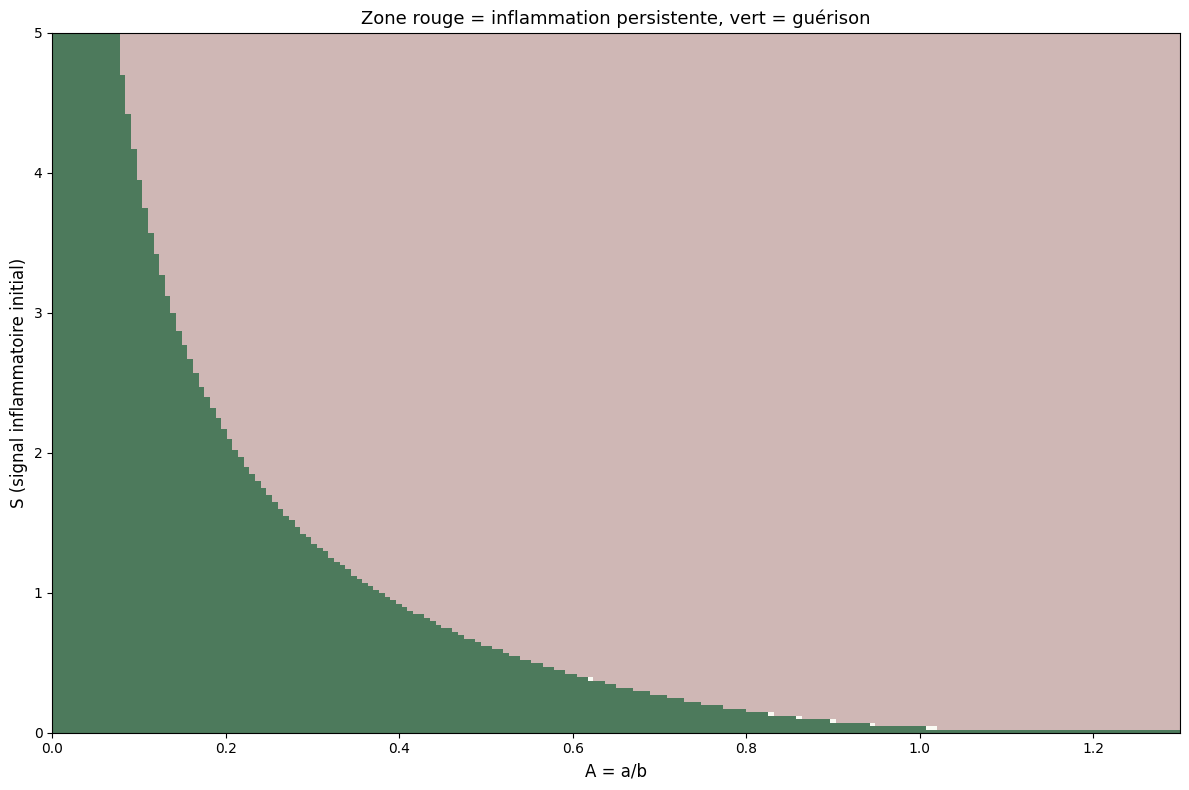

In [125]:
fig, ax = plt.subplots(figsize=(12, 8))

# On crée un masque pour la zone d'inflammation persistante
mask_inflammation = (plot_results < 0.05)
mask_diseasefree = (plot_results > 0.95) | (plot_results == np.nan) # pour éviter les np.nan si présents

# Affichage : rouge pour inflammation, vert pour disease-free
ax.imshow(mask_inflammation, extent=[A_range[0], A_range[-1], S_range[0], S_range[-1]],
          origin='lower', cmap=plt.cm.Reds, alpha=0.9, aspect='auto', vmin=0, vmax=1)
ax.imshow(mask_diseasefree, extent=[A_range[0], A_range[-1], S_range[0], S_range[-1]],
          origin='lower', cmap=plt.cm.Greens, alpha=0.7, aspect='auto', vmin=0, vmax=1)

ax.set_xlabel('A = a/b', fontsize=12)
ax.set_ylabel('S (signal inflammatoire initial)', fontsize=12)
ax.set_title('Zone rouge = inflammation persistente, vert = guérison', fontsize=13)

plt.tight_layout()
plt.show()

Tracé du ratio pro/anti_inflammatoire = N+M/T
(idee de Gabriel Courties)

In [98]:
def inflam_adim_gab(y0, alpha, beta, gamma, delta_N, delta_M, a, b, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_oliv, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/1000), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, a, b))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(231)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('inflammatory signal')

    plt.subplot(232)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(N)
    plt.ylim(bottom=0, top=ymax)
    plt.title('neutrophiles')

    plt.subplot(233)
    plt.plot(t,M, 'g')
    plt.xlabel('time [d] ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(M)
    plt.ylim(bottom=0, top=ymax)
    plt.title('monocytes macrophages')

    plt.subplot(234)
    plt.plot(t,T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('macrophages SL-TRM')

    plt.subplot(235)
    plt.plot(t,(N+M)/T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('ratio pro vs anti inflammatory')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max((N+M)/T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('ratio pro vs anti inflammatory')

    plt.subplot(236)
    plt.plot(N+M,T, 'm')
    plt.xlabel('N+M pro-inflammatory')
    plt.ylabel('T anti-inflammatory')
    plt.ticklabel_format(style='plain', axis='y')
    ymin = 0.9 * np.min(T)
    ymax = 1.1 * np.max(T)
    plt.ylim(bottom=ymin, top=ymax )
    plt.title('phase plane immune signal   vs ration pro vs anti inflammatory')

    #plt.subplot(325)
    #plt.plot(M,T, 'm')
    #plt.xlabel('Momac')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.3, 0.01, 'Plan de phase entre Momac et SL-TRM ', ha='center', fontsize=12)

    #plt.subplot(326)
    #plt.plot(S,T, 'm')
    #plt.xlabel('signal inflammatoire')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.7, 0.01, 'Plan de phase entre inflammation et SL-TRM ', ha='center', fontsize=12)

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

valeurs finales: Signal=0.042, Neutrophiles=1.060, Momac=1.055, SL-TRM=0.949


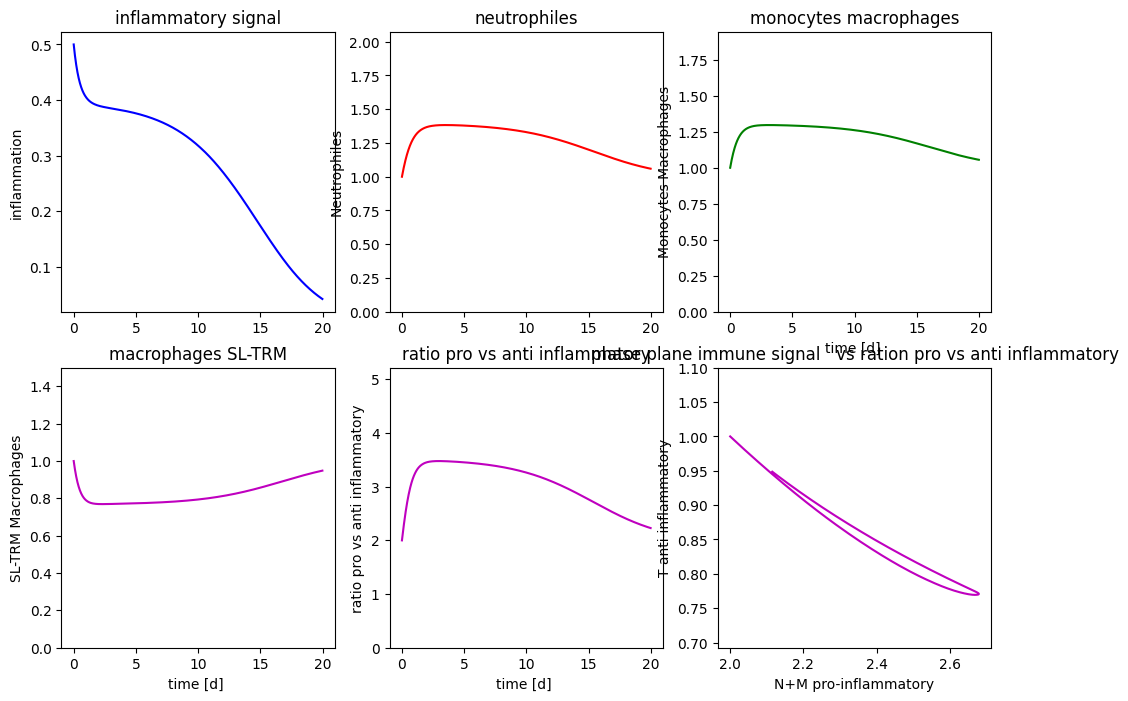

In [99]:
inflam_adim_gab([0.5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.55, b=1, duree=20)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


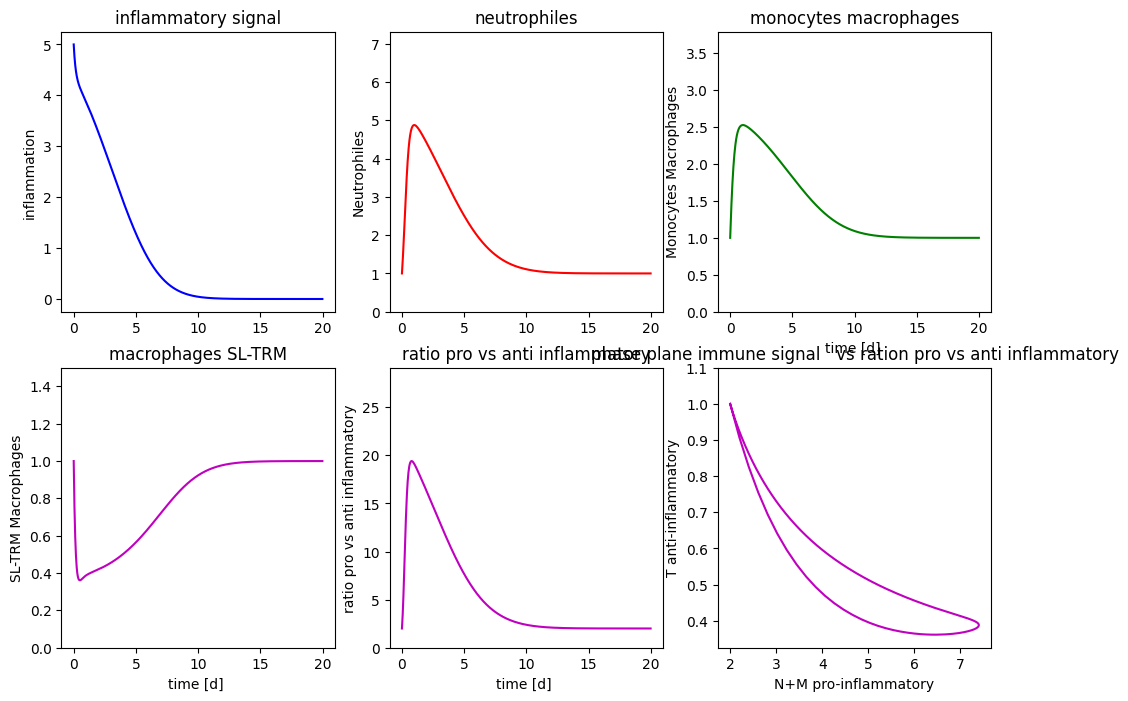

In [100]:
inflam_adim_gab([5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.05, b=1, duree=20)